# Проектная работа "Банки - Анализ оттока клиентов"

## Презентация
[Презентация](https://drive.google.com/file/d/1vpgR0ekbx43sVtxg8wPqoSdcqPiv19-C/view?usp=sharing)

## Декомпозиция исследования

**Заказчик исследования** -  отдел маркетинга банка «Метанпром».

**Цель исследования** - выявить факторы, влияющие на отток клиентов регионального банка «Метанпром», и на основании полученных данных определить ключевые сегменты клиентов, склонных к уходу. На основе анализа предложить рекомендации для отдела маркетинга, направленные на снижение оттока и удержание текущих клиентов.

Для достижения поставленной цели, предстоит выполнить следующие **задачи:**   
(*развернутый план работы расположен ниже после описания данных*)   
- загрузить, первично проанализировать данные и провести их предобработку, если в этом есть необходимость;
- провести исследовательский анализ данных (EDA), направленный на:
    - анализ распределения признаков в зависимости от оттока;
    - анализ портретов клиентов в разрезе оттока (сравнение ушедших и неушедших);
- осуществить корреляционный анализ признака `churn` с другими признаками (включая и интерпретацию по Чеддоку);
- проверить гипотезы (минимум 2);
- выполнить сегментацию клиентов с учетом указанных критериев;
- определить приоритетность сегментов;
- сформировать рекомендации по работе с приоритетными сегментами для отдела маркетинга;
- сделать общий вывод по проделанной работе.

**Описание данных**

Данные для предстоящего анализа будут получены из файла:

`/datasets/bank_scrooge.csv`

Датасет содержит данные о клиентах банка «Метанпром». Банк располагается в
Ярославле и областных городах: Ростов Великий и Рыбинск.

**Колонки:**

- `USERID` — идентификатор пользователя,
- `score` — баллы кредитного скоринга,
- `city` — город,
- `gender` — пол,
- `age` — возраст,
- `equity` — количество баллов собственности
- `balance` — баланс на счёте,
- `products` — количество продуктов, которыми пользуется клиент,
- `credit_card` — есть ли кредитная карта,
- `last_activity` — активный клиент,
- `EST_SALARY` — оценочный доход клиента,
- `сhurn` — признак оттока.

**План работы:**

**1. Загрузка и описание данных:** 
- импорт необходимых библиотек;
- считывание датасета `bank_scrooge.csv` c сохранением в переменную `bank_clients_data`;
- описание данных.

**2. Первичный обзор и обработка/подготовка данных:** 
- первичный анализ датафрейма `bank_clients_data` с целью выявления ошибок, пропусков, явных/неявных (по `USERID`) дубликатов, аномалий и оценки их влияния на предстоящее исследование;
- формирование выводов на основе первичного обзора;
- приведение столбцов к стилю `snake_case`, если в этом есть необходимость;
- приведение данных к нужным типам, в случае обнаружения некорректных типов;
- анализ явных и неявных (по `USERID`) дубликатов и принятие решения об их устранении, либо сохранении в данных, если они содержат значимую информацию или же однозначно нельзя определить, что строки дублируются, например,часть информации разнится;
- исследование причин возникновения пропусков:
    - распределение пропусков (определение в каких столбцах и строках имеются пропуски, имеются ли паттерны (например, пропуски у клиентов из определённого города или с низким доходом) и т.д.); 
    - построение горизонтальной столбчатой диаграммы пропусков;
- кодирование данных с пропусками для использования в дальнейшем анализе корреляции:
     - оценка взаимосвязи с другими признаками: создание бинарного признака наличия пропуска (`0` — нет пропуска, `1` — пропуск) для проверки корреляции с другими характеристиками;
     - анализ корреляции пропусков с другими признаками;
- определение типа пропусков (классификация пропусков) для дальнейшего принятия решения по их обработке: 
    - `MCAR` (Missing Completely At Random): нет корреляции, пропуски полностью случайны и не зависят от других данных. В данном случае, необходимо будет сделать еще дополнительно тест Литтла;
    - `MAR` (Missing At Random): есть корреляция, пропуски зависят от других наблюдаемых данных (например, доход отсутствует чаще у определённой группы клиентов);
    - `MNAR` (Missing Not At Random): контекстные данные, пропуски зависят (связны) от недоступной или самой пропущенной информации (например, клиенты с нулевым балансом не указывают доход).
- определение контекста данных:
     - почему пропуски могут появляться в конкретных столбцах? Например: пропущенный возраст может означать, что клиент его не указал, пропуск баланса может быть связан с отсутствием активного счёта;
- обработка пропусков при необходимости: оставить без изменений, заполнить значениями (например, медианой, средним, заглушками) или удалить;
- исследование распределения числовых признаков путем построения гистограмм. Цель: выявить возможные аномальные выбросы и оценить характер распределения каждого признак.

**3. Исследовательский анализ данных (EDA)**

 **3.1. Анализ распределения признаков в зависимости от оттока:**
- Для *непрерывных признаков*: определение интервалов значений, связанных с повышенной долей оттока:
     - выбор числовых признаков;
     - построение нормированной гистограммы распределения и/или boxplot относительно средних значений, для определенения отточных интервалов;
     - определение критериев и условий для выделения групп пользователей на основе схожих характеристик, которые впоследствии будут использоваться для сегментации.
- Для *категориальных и дискретных признаков*: выявление значений признаков, при которых доля оттока превышает средний уровень по банку:
     - выбор категориальных, дискретных признаков для анализа;
     - определение среднего уровня оттока по банку;
     - вычисление среднего уровня оттока для каждого значения признака;
     - визуализация результата при помощи горизонтальных столбчатых диаграмм;
     - выделение и/или дополнение ранее выделенных условий критериями, которые впоследствии будут использоваться для сегментации.  
- Формирование краткого вывода по данному шагу.

**3.2. Анализ портретов клиентов в разрезе оттока (сравнение ушедших и неушедших).**

Здесь потребуется разделение клиентов на две группы: ушедшие (`churn == 1`) и оставшиеся (`churn == 0`).

**Действия:**
- построение сводной таблицы, где по столбцам: значение оттока 1 и 0, по строкам: соответствующие признаки и для каждого признака расчет меры соответствующей центральной тенденции;
- поиск отличий по признакам:
    - для **непрерывных признаков** (например, `age`, `balance`, `EST_SALARY`): расчет средних значений, медианы и стандартного отклонения для обеих групп.
        - учет выбросов: если выбросы обнаружены, использовать медиану вместо среднего значения.
    - для **дискретных признаков** (например, `products`): расчет медианы как более интерпретируемой меры.
    - для **категориальных признаков** (например, `city`, `credit_card`): расчет моды (наиболее часто встречающегося значения).
    - построение графиков для визуализации различий и сравнения групп.
    
- определение влияния кредитного скоринга и количества используемых продуктов: рассчет распределения значений `score` и `products` для обеих групп, построение графиков для сравнения;
- изучение распределения оттока по `городам`: рассчет процента ушедших клиентов для каждого города, построение графиков при необходимости;
- идентификация зон риска: выявление городов, а также (при необходимости) других признаков, где процент оттока значительно выше среднего, построение графиков, чтобы выделить зоны риска;
- выявление относительных различий для непрерывных признаков:
    - вычисление разницы между группами (ушедшими и оставшимися) в процентах для непрерывных признаков:
        - *формула*:        
$$
\text{Относительное различие (\%)} = \frac{\text{Среднее для churn = 1} - \text{Среднее для churn = 0}}{\text{Среднее для churn = 0}} \times 100
$$  

- **дополнительно (*по необходимости - решение будет принято в процессе выполнение EDA*):**
    - выявление взаимосвязей между признаками в разрезе оттока;
    - анализ доли оттока в интервалах непрерывных признаков;
    - исследование бинарных признаков (например, `credit_card`, `last_activity`).

*Возможна корректировка действий этого пункта в процессе проведения анализа*.


**4. Корреляционный анализ признака  `churn` с другими признаками (включая и интерпретацию по Чеддоку):**
- рассчет корреляции для всех числовых признаков относительно churn с использованием по умолчанию метода корреляции Пирсона (если данные будут нормализованы с отсутствием выбросов или сильных смещений) или коэффициента Спирмена (если данные содержат выбросы или сильно смещены) . *Допустима ситуация использования двух методов с дальнейшим сравнением результатов*;
- анализ корреляции в соответствии с интерпретацией по Чеддоку;
- визуализация корреляции с помощью тепловой карты (heatmap);
- выявление наиболее значимых факторов, влияющих на отток;
- дополнительно, по необходимости, можно будет построить попарные графики (бывает полезным в дополнении к предыдущим пунктам, потому что корреляция отражает только линейную зависимость, а на попарных графиках можно увидеть другие взаимосвязи): признак-признак, признак-целевая переменная. (*Решение об этом будет принято в процессе выполнение настоящей работы*).

**5. Проверка гипотез, связянных с оттоком:**

-  Проверка гипотезы о различии доходов между ушедшими и неушедшими;
-  Проверка дополнительных гипотез (средний/нулевой баланс, факторы активности, возраст, количество продуктов и прочее). 

Вот примерный список возможных гипотез, которые могут быть дополнительно проверены:
- Различие среднего баланса между ушедшими и оставшимися клиентами;
- Клиенты с нулевым балансом (`balance = 0`) имеют большую вероятность уйти;
- Влияние количества продуктов на вероятность оттока;
- Влияние активности на отток;
- Зависимость кредитного скоринга от оттока;
- Влияние возраста на отток;
- Клиенты с высоким доходом и малым количеством продуктов имеют меньшую вероятность оттока.

**Гипотезы и их количество будут определены/уточнены в процессе выполнения / по результатам EDA*. 

При проверке гипотез будет обоснован выбор статистического метода.

**6. Подведение промежуточных итогов:** формирование выводов на основе результатов EDA, корреляционного анализа и проверки гипотез. Определение ключевых признаков, влияющих на отток:

- выделение ключевых признаков и их значений интервалов (диапазонов) для последующей сегментации.

**7. Выполнение сегментации клиентов с учетом указанных критериев.**

***Критерии:*** 
- сегменты не должны быть узкими (от 500 клиентов на сегмент);
- должно быть не менее трех сегментов;
- уровень оттока в сегментах должен быть выше среднего уровня оттока по банку.

***Действия:***
- рассчет среднего уровня оттока по банку;
- выбор признаков для сегментации (основываясь на анализе EDA, выбрать наиболее значимые признаки, которые влияют на отток);
- формирование сегментов, используя более простые правила группировки и статистические методы, которые не требуют обучения модели, например:
    - сегментация на основе пороговых значений: разделение пользователей на группы, основываясь на ранее определённых интервалах значений ключевых признаков (молодые, срежний возраст, старшие, низкий/средний/высокий баланс и т.д.;
    - сегментация с помощью статистических квантилей: разделите данных на группы на основе квантилей (например, по 25%, 50%, 75%) (группа 1: нижние 25%, группа 2: 25–50%, группа 3: 50–75%, группа 4: верхние 25%);
    - сегментация на основе частотных распределений, используя частоту встречаемости значений в данных для выделения сегментов (например, сегмент 1 - топ-3, сегмент 2 - остальные);
    - сегментация с использованием пересечений признаков (многомерные правила) (отток как критерий (группы с разным уровнем оттока)). Здесь создаем сегменты с помощью комбинаций нескольких признаков, например: `balance_group + products_group = сегмент`.
- оценка оттока в каждом сегменте;
- обеспечить достаточный размер сегментов;
- сформировать выводы по каждому сегменту.


**Метод сегментации будет выбран по результатам проведенного анализа*.

**8. Приоритизация сегментов:**
- рассчет доли оттока (churn) в каждом сегменте;
- определение средних значений признаков (например, balance, products, EST_SALARY);
- сортировка сегментов по приоритету.

    ***Примечание:*** *у отдела маркетинга нет автоматизированных систем, сотрудники будут взаимодействовать с каждым клиентом "вручную" (все рассылки и связанные с ними действия выполняются вручную)*.
    
На этом этапе будет установлена приоритетность сегментов для обработки отделом маркетинга. Сегменты будут ранжированы в порядке убывания доли ушедших клиентов – чем выше уровень оттока в сегменте, тем выше его приоритет. 

**6. Формирование рекомендаций по работе с приоритетными сегментами для отдела маркетинга:** 
- для каждого сегмента будет сформирована индивидуальная рекомендация, учитывающая характеристики клиентов, входящих в него;  
- важно, чтобы рекомендации были адаптированы именно под целевую аудиторию каждого сегмента.

**7. Общий вывод**

***Примечание***: *В ходе выполнения проекта и проведения анализа возможны дополнительные действия и мероприятия, которые не были изначально предусмотрены/прописаны в плане работы*.

# *Основная часть исследования*

## Описание исследования и исходных данных

**Заказчик исследования** - отдел маркетинга банка «Метанпром».

**Цель исследования** - выявить факторы, влияющие на отток клиентов регионального банка «Метанпром», и на основании полученных данных определить ключевые сегменты клиентов, склонных к уходу. На основе анализа предложить рекомендации для отдела маркетинга, направленные на снижение оттока и удержание текущих клиентов.

Для достижения поставленной цели, предстоит выполнить следующие **задачи**:

- загрузить, первично проанализировать данные и провести их предобработку, если в этом есть необходимость;
- провести исследовательский анализ данных (EDA), направленный на:
    - анализ распределения признаков в зависимости от оттока;
    - анализ портретов клиентов в разрезе оттока (сравнение ушедших и неушедших);
- осуществить корреляционный анализ признака churn с другими признаками (включая и интерпретацию по Чеддоку);
- проверить гипотезы (минимум 2);
- выполнить сегментацию клиентов с учетом указанных критериев;
- определить приоритетность сегментов;
- сформировать рекомендации по работе с приоритетными сегментами для отдела маркетинга;
- сделать общий вывод по проделанной работе.


**Описание данных**

Данные для предстоящего анализа будут получены из файла:

`/datasets/bank_scrooge.csv`

Датасет содержит данные о клиентах банка «Метанпром». Банк располагается в Ярославле и областных городах: Ростов Великий и Рыбинск.

**Колонки:**

- `USERID` — идентификатор пользователя,
- `score` — баллы кредитного скоринга,
- `city` — город,
- `gender` — пол,
- `age` — возраст,
- `equity` — количество баллов собственности
- `balance` — баланс на счёте,
- `products` — количество продуктов, которыми пользуется клиент,
- `credit_card` — есть ли кредитная карта,
- `last_activity` — активный клиент,
- `EST_SALARY` — оценочный доход клиента,
- `сhurn` — признак оттока.

Таким образом, **исследование пройдёт в одиннадцать этапов**:

1. [Загрузка и описание данных](#data)
2. [Первичный обзор и обработка/подготовка данных](#Initial_review_and_data_preparation)
3. [Исследовательский анализ данных](#data_analysis)
4. [Анализ портретов клиентов в разрезе оттока](#user_portrait)
5. [Корреляционный анализ признака churn с другими признаками](#Correlation_analysis_of_the_churn_feature)
6. [Проверка гипотез, связанных с оттоком](#Hypothesis_testing)
7. [Проведение промежуточных итогов](#Conducting_interim_results)
8. [Выполнение сегментации клиентов](#Performing_customer_segmentation)
9. [Приоритизация сигментов](#Prioritizing_Segments)
10. [Формирование рекомендаций по работе с приоритетными сегментами](#conclusions)
11. [Общий вывод](#General_conclusion)

<h1>Оглавление:<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Презентация" data-toc-modified-id="Презентация-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Презентация</a></span></li><li><span><a href="#Декомпозиция-исследования" data-toc-modified-id="Декомпозиция-исследования-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Декомпозиция исследования</a></span></li><li><span><a href="#Описание-исследования-и-исходных-данных" data-toc-modified-id="Описание-исследования-и-исходных-данных-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Описание исследования и исходных данных</a></span></li><li><span><a href="#Загрузка-и-описание-данных" data-toc-modified-id="Загрузка-и-описание-данных-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Загрузка и описание данных</a></span></li><li><span><a href="#Первичный-обзор-и-обработка/подготовка-данных:" data-toc-modified-id="Первичный-обзор-и-обработка/подготовка-данных:-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Первичный обзор и обработка/подготовка данных:</a></span><ul class="toc-item"><li><span><a href="#Первичный-анализ-датафрейма,-выводы" data-toc-modified-id="Первичный-анализ-датафрейма,-выводы-5.1"><span class="toc-item-num">5.1&nbsp;&nbsp;</span>Первичный анализ датафрейма, выводы</a></span></li><li><span><a href="#Обработка-данных" data-toc-modified-id="Обработка-данных-5.2"><span class="toc-item-num">5.2&nbsp;&nbsp;</span>Обработка данных</a></span><ul class="toc-item"><li><span><a href="#Приведение-столбцов-к-нижнему-регистру" data-toc-modified-id="Приведение-столбцов-к-нижнему-регистру-5.2.1"><span class="toc-item-num">5.2.1&nbsp;&nbsp;</span>Приведение столбцов к нижнему регистру</a></span></li><li><span><a href="#Приведение-данных-к-нужным-типам" data-toc-modified-id="Приведение-данных-к-нужным-типам-5.2.2"><span class="toc-item-num">5.2.2&nbsp;&nbsp;</span>Приведение данных к нужным типам</a></span></li><li><span><a href="#Обработка-неявных-дубликатов" data-toc-modified-id="Обработка-неявных-дубликатов-5.2.3"><span class="toc-item-num">5.2.3&nbsp;&nbsp;</span>Обработка неявных дубликатов</a></span></li><li><span><a href="#Исследование-причин-возникновения-пропусков" data-toc-modified-id="Исследование-причин-возникновения-пропусков-5.2.4"><span class="toc-item-num">5.2.4&nbsp;&nbsp;</span>Исследование причин возникновения пропусков</a></span></li><li><span><a href="#Кодирование-пропусков-(создание-бинарных-признаков)" data-toc-modified-id="Кодирование-пропусков-(создание-бинарных-признаков)-5.2.5"><span class="toc-item-num">5.2.5&nbsp;&nbsp;</span>Кодирование пропусков (создание бинарных признаков)</a></span></li><li><span><a href="#Анализ-корреляции-пропусков-с-другими-признаками" data-toc-modified-id="Анализ-корреляции-пропусков-с-другими-признаками-5.2.6"><span class="toc-item-num">5.2.6&nbsp;&nbsp;</span>Анализ корреляции пропусков с другими признаками</a></span><ul class="toc-item"><li><span><a href="#Кодирование-категоральных-переменных" data-toc-modified-id="Кодирование-категоральных-переменных-5.2.6.1"><span class="toc-item-num">5.2.6.1&nbsp;&nbsp;</span>Кодирование категоральных переменных</a></span></li><li><span><a href="#Расчет-корреляции-между-бинарными-признаками-пропусков-и-остальными-столбцами" data-toc-modified-id="Расчет-корреляции-между-бинарными-признаками-пропусков-и-остальными-столбцами-5.2.6.2"><span class="toc-item-num">5.2.6.2&nbsp;&nbsp;</span>Расчет корреляции между бинарными признаками пропусков и остальными столбцами</a></span></li></ul></li><li><span><a href="#Определение-контекста-данных.-Взаимосвязь-пропусков-в-балансе-с-ключевыми-показателями" data-toc-modified-id="Определение-контекста-данных.-Взаимосвязь-пропусков-в-балансе-с-ключевыми-показателями-5.2.7"><span class="toc-item-num">5.2.7&nbsp;&nbsp;</span>Определение контекста данных. Взаимосвязь пропусков в балансе с ключевыми показателями</a></span><ul class="toc-item"><li><span><a href="#Анализ-распределения-пропусков-в-balance-в-зависимости-от-equity" data-toc-modified-id="Анализ-распределения-пропусков-в-balance-в-зависимости-от-equity-5.2.7.1"><span class="toc-item-num">5.2.7.1&nbsp;&nbsp;</span>Анализ распределения пропусков в <code>balance</code> в зависимости от <code>equity</code></a></span></li><li><span><a href="#Анализ-распределения--пропусков--в-balance-в-зависимости-от-products" data-toc-modified-id="Анализ-распределения--пропусков--в-balance-в-зависимости-от-products-5.2.7.2"><span class="toc-item-num">5.2.7.2&nbsp;&nbsp;</span>Анализ распределения  пропусков  в <code>balance</code> в зависимости от <code>products</code></a></span></li><li><span><a href="#Анализ-распределения--пропусков-в-balance-в-зависимости-от--est_salary" data-toc-modified-id="Анализ-распределения--пропусков-в-balance-в-зависимости-от--est_salary-5.2.7.3"><span class="toc-item-num">5.2.7.3&nbsp;&nbsp;</span>Анализ распределения  пропусков в <code>balance</code> в зависимости от  <code>est_salary</code></a></span></li><li><span><a href="#Закономерности-в-пропусках,-краткий-вывод" data-toc-modified-id="Закономерности-в-пропусках,-краткий-вывод-5.2.7.4"><span class="toc-item-num">5.2.7.4&nbsp;&nbsp;</span>Закономерности в пропусках, краткий вывод</a></span></li></ul></li><li><span><a href="#Определение-типа-пропусков-(классификация-пропусков)-для-дальнейшего-принятия-решения-по-их-обработке" data-toc-modified-id="Определение-типа-пропусков-(классификация-пропусков)-для-дальнейшего-принятия-решения-по-их-обработке-5.2.8"><span class="toc-item-num">5.2.8&nbsp;&nbsp;</span>Определение типа пропусков (классификация пропусков) для дальнейшего принятия решения по их обработке</a></span></li><li><span><a href="#Обработка-пропусков" data-toc-modified-id="Обработка-пропусков-5.2.9"><span class="toc-item-num">5.2.9&nbsp;&nbsp;</span>Обработка пропусков</a></span></li></ul></li><li><span><a href="#Вывод-по-разделу" data-toc-modified-id="Вывод-по-разделу-5.3"><span class="toc-item-num">5.3&nbsp;&nbsp;</span>Вывод по разделу</a></span></li></ul></li><li><span><a href="#Исследовательский-анализ-данных-(EDA)" data-toc-modified-id="Исследовательский-анализ-данных-(EDA)-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Исследовательский анализ данных (EDA)</a></span><ul class="toc-item"><li><span><a href="#Исследование-распределения-числовых-признаков-путем-построения-гистограмм-с-целью-выявления-возможных-аномальных-выбросов-и-оценки-характера-распределения-каждого-признака" data-toc-modified-id="Исследование-распределения-числовых-признаков-путем-построения-гистограмм-с-целью-выявления-возможных-аномальных-выбросов-и-оценки-характера-распределения-каждого-признака-6.1"><span class="toc-item-num">6.1&nbsp;&nbsp;</span>Исследование распределения числовых признаков путем построения гистограмм с целью выявления возможных аномальных выбросов и оценки характера распределения каждого признака</a></span></li><li><span><a href="#Анализ-распределения-признаков-в-зависимости-от-оттока.-Непрерывные-признаки" data-toc-modified-id="Анализ-распределения-признаков-в-зависимости-от-оттока.-Непрерывные-признаки-6.2"><span class="toc-item-num">6.2&nbsp;&nbsp;</span>Анализ распределения признаков в зависимости от оттока. Непрерывные признаки</a></span></li><li><span><a href="#Анализ-распределения-признаков-в-зависимости-от-оттока.-Категориальные-и-дискретные-признаки" data-toc-modified-id="Анализ-распределения-признаков-в-зависимости-от-оттока.-Категориальные-и-дискретные-признаки-6.3"><span class="toc-item-num">6.3&nbsp;&nbsp;</span>Анализ распределения признаков в зависимости от оттока. Категориальные и дискретные признаки</a></span></li><li><span><a href="#Вывод-по-разделу" data-toc-modified-id="Вывод-по-разделу-6.4"><span class="toc-item-num">6.4&nbsp;&nbsp;</span>Вывод по разделу</a></span></li></ul></li><li><span><a href="#Анализ-портретов-клиентов-в-разрезе-оттока-(сравнение-ушедших-и-неушедших)" data-toc-modified-id="Анализ-портретов-клиентов-в-разрезе-оттока-(сравнение-ушедших-и-неушедших)-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>Анализ портретов клиентов в разрезе оттока (сравнение ушедших и неушедших)</a></span><ul class="toc-item"><li><span><a href="#Поиск-отличий-по-признакам" data-toc-modified-id="Поиск-отличий-по-признакам-7.1"><span class="toc-item-num">7.1&nbsp;&nbsp;</span>Поиск отличий по признакам</a></span></li><li><span><a href="#Выявление-относительных-различий-для-непрерывных-признаков" data-toc-modified-id="Выявление-относительных-различий-для-непрерывных-признаков-7.2"><span class="toc-item-num">7.2&nbsp;&nbsp;</span>Выявление относительных различий для непрерывных признаков</a></span></li><li><span><a href="#Вывод-по-разделу" data-toc-modified-id="Вывод-по-разделу-7.3"><span class="toc-item-num">7.3&nbsp;&nbsp;</span>Вывод по разделу</a></span></li></ul></li><li><span><a href="#Корреляционный-анализ-признака-churn-с-другими-признаками-(включая-и-интерпретацию-по-Чеддоку)" data-toc-modified-id="Корреляционный-анализ-признака-churn-с-другими-признаками-(включая-и-интерпретацию-по-Чеддоку)-8"><span class="toc-item-num">8&nbsp;&nbsp;</span>Корреляционный анализ признака <code>churn</code> с другими признаками (включая и интерпретацию по Чеддоку)</a></span></li><li><span><a href="#Проверка-гипотез,-связянных-с-оттоком" data-toc-modified-id="Проверка-гипотез,-связянных-с-оттоком-9"><span class="toc-item-num">9&nbsp;&nbsp;</span>Проверка гипотез, связянных с оттоком</a></span><ul class="toc-item"><li><span><a href="#Гипотеза-о-различии-среднего-дохода-(est_salary)-между-ушедшими-и-оставшимися-клиентами" data-toc-modified-id="Гипотеза-о-различии-среднего-дохода-(est_salary)-между-ушедшими-и-оставшимися-клиентами-9.1"><span class="toc-item-num">9.1&nbsp;&nbsp;</span>Гипотеза о различии среднего дохода (<code>est_salary</code>) между ушедшими и оставшимися клиентами</a></span></li><li><span><a href="#Гипотеза-о-различии-среднего-баланса-(balance)-между-ушедшими-и-оставшимися-клиентами" data-toc-modified-id="Гипотеза-о-различии-среднего-баланса-(balance)-между-ушедшими-и-оставшимися-клиентами-9.2"><span class="toc-item-num">9.2&nbsp;&nbsp;</span>Гипотеза о различии среднего баланса (<code>balance</code>) между ушедшими и оставшимися клиентами</a></span></li><li><span><a href="#Гипотеза-о-влиянии-количества-продуктов-(products)-на-вероятность-оттока" data-toc-modified-id="Гипотеза-о-влиянии-количества-продуктов-(products)-на-вероятность-оттока-9.3"><span class="toc-item-num">9.3&nbsp;&nbsp;</span>Гипотеза о влиянии количества продуктов (<code>products</code>) на вероятность оттока</a></span></li><li><span><a href="#Гипотеза-о-влиянии-активности-(last_activity)-на-отток" data-toc-modified-id="Гипотеза-о-влиянии-активности-(last_activity)-на-отток-9.4"><span class="toc-item-num">9.4&nbsp;&nbsp;</span>Гипотеза о влиянии активности (<code>last_activity</code>) на отток</a></span></li><li><span><a href="#Гипотеза-о-влиянии-кредитного-скоринга-(score)-на-отток" data-toc-modified-id="Гипотеза-о-влиянии-кредитного-скоринга-(score)-на-отток-9.5"><span class="toc-item-num">9.5&nbsp;&nbsp;</span>Гипотеза о влиянии кредитного скоринга (<code>score</code>) на отток</a></span></li><li><span><a href="#Вывод-по-разделу" data-toc-modified-id="Вывод-по-разделу-9.6"><span class="toc-item-num">9.6&nbsp;&nbsp;</span>Вывод по разделу</a></span></li></ul></li><li><span><a href="#Подведение-промежуточных-итогов:-формирование-выводов-на-основе-результатов-EDA,-корреляционного-анализа-и-проверки-гипотез.-Определение-ключевых-признаков,-влияющих-на-отток" data-toc-modified-id="Подведение-промежуточных-итогов:-формирование-выводов-на-основе-результатов-EDA,-корреляционного-анализа-и-проверки-гипотез.-Определение-ключевых-признаков,-влияющих-на-отток-10"><span class="toc-item-num">10&nbsp;&nbsp;</span>Подведение промежуточных итогов: формирование выводов на основе результатов EDA, корреляционного анализа и проверки гипотез. Определение ключевых признаков, влияющих на отток</a></span></li><li><span><a href="#Выполнение-сегментации-клиентов-с-учетом-указанных-критериев" data-toc-modified-id="Выполнение-сегментации-клиентов-с-учетом-указанных-критериев-11"><span class="toc-item-num">11&nbsp;&nbsp;</span>Выполнение сегментации клиентов с учетом указанных критериев</a></span></li><li><span><a href="#Приоритизация-сегментов" data-toc-modified-id="Приоритизация-сегментов-12"><span class="toc-item-num">12&nbsp;&nbsp;</span>Приоритизация сегментов</a></span></li><li><span><a href="#Формирование-рекомендаций-по-работе-с-приоритетными-сегментами-для-отдела-маркетинга" data-toc-modified-id="Формирование-рекомендаций-по-работе-с-приоритетными-сегментами-для-отдела-маркетинга-13"><span class="toc-item-num">13&nbsp;&nbsp;</span>Формирование рекомендаций по работе с приоритетными сегментами для отдела маркетинга</a></span></li><li><span><a href="#Общий-вывод" data-toc-modified-id="Общий-вывод-14"><span class="toc-item-num">14&nbsp;&nbsp;</span>Общий вывод</a></span></li></ul></div>

## Загрузка и описание данных

**Импортируем основные библиотеки**, которые понадобятся нам в дальнейшем. 
<a id='data'></a>
Путь к файлу:   

`/datasets/bank_scrooge.csv`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import levene
from scipy.stats import ttest_ind
import scipy.stats as stats
import os

Теперь **считаем данные из csv-файла в датафрейм** и сохраним в переменную `bank_clients_data`

In [2]:
# Пути к файлам
pth1 = '/datasets/bank_scrooge.csv'
pth2 = 'C:/Users/Мария/Desktop/Практикум/Датасеты/bank_scrooge.csv'

# Определяем существующий путь
if os.path.exists(pth1):
    file_path = pth1
elif os.path.exists(pth2):
    file_path = pth2
else:
    raise FileNotFoundError("Файл не найден ни в одной из указанных директорий.")

# Загружаем данные, автоматически преобразуем даты и устанавливаем индекс
bank_clients_data = pd.read_csv(file_path)

# Выводим первые строки
bank_clients_data.head()

,USERID,score,city,gender,age,equity,balance,products,credit_card,last_activity,EST_SALARY,churn
0,183012,850.0,Рыбинск,Ж,25.0,1,59214.82,2,0,1,75719.14,1
1,146556,861.0,Рыбинск,Ж,37.0,5,850594.33,3,1,0,86621.77,0
2,120722,892.0,Рыбинск,Ж,30.0,0,NaN,1,1,1,107683.34,0
3,225363,866.0,Ярославль,Ж,51.0,5,1524746.26,2,0,1,174423.53,1
4,157978,730.0,Ярославль,М,34.0,5,174.00,1,1,0,67353.16,1


Данные успешно загружены и описаны, переходим к первичному обзору и предобработке.


## Первичный обзор и обработка/подготовка данных:
<a id='Initial_review_and_data_preparation'></a>
Изучим данные и выполним предобработку, если это будет необходимо. Проверим, есть ли в данных пропуски, дубликаты и аномалий, а также оценим их влияние на предстоящее исследование. Убедимся, что типы данных во всех колонках соответствуют сохранённым в них значениям. 

### Первичный анализ датафрейма, выводы
Для начала проведем первичный анализ имеющегося датафрейма. Воспользуемся функцией `analyze_all_dfs`

In [3]:
def analyze_all_dfs(bank_clients_data):
    # Внутри функции создаем словарь dfs, где каждому датафрейму даем имя 
    dfs = {
        "bank_clients_data (данные о клиентах банка «Метанпром»)": bank_clients_data
          }
    
    # Функция последовательно проходит по каждому датафрейму и выводит результаты анализа по стандартному набору операций:  
    for name, df in dfs.items():
        print(f"\n=== Первичный анализ датафрейма {name} ===")

        print("\n1. Общая информация:")
        print('*'*40)
        df.info()

        print("\n2. Анализ пропусков в данных:")
        print('*'*40)
        print(df.isna().sum())
        
        print("\n3. Процент пропусков в данных:")
        print('*'*40)
        print((df.isnull().mean() * 100).round(2))

        print("\n4. Вывод первых 5 строк:")
        print('*'*40)
        display(df.head())

        print("\n5. Статистика по числовым столбцам:")
        print('*'*40)
        display(df.describe())

        print("\n6. Проверка на дубликаты:")
        print('*'*40)
        print(f"Количество явных дубликатов: {df.duplicated().sum()}")
        
        print("\n7. Для анализа категориальных данных:")
        print('*'*40)
        for col in df.select_dtypes(include=['object', 'category']).columns:
            print(f"\n- {col} (Top 10 показателей):")
            display(df[col].value_counts().head(10))

        print("\n" + "="*50 + "\n")

analyze_all_dfs(bank_clients_data)


=== Первичный анализ датафрейма bank_clients_data (данные о клиентах банка «Метанпром») ===

1. Общая информация:
****************************************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   USERID         10000 non-null  int64  
 1   score          10000 non-null  float64
 2   city           10000 non-null  object 
 3   gender         10000 non-null  object 
 4   age            9974 non-null   float64
 5   equity         10000 non-null  int64  
 6   balance        7705 non-null   float64
 7   products       10000 non-null  int64  
 8   credit_card    10000 non-null  int64  
 9   last_activity  10000 non-null  int64  
 10  EST_SALARY     10000 non-null  float64
 11  churn          10000 non-null  int64  
dtypes: float64(4), int64(6), object(2)
memory usage: 937.6+ KB

2. Анализ пропусков в данных:
*************************

,USERID,score,city,gender,age,equity,balance,products,credit_card,last_activity,EST_SALARY,churn
0,183012,850.0,Рыбинск,Ж,25.0,1,59214.82,2,0,1,75719.14,1
1,146556,861.0,Рыбинск,Ж,37.0,5,850594.33,3,1,0,86621.77,0
2,120722,892.0,Рыбинск,Ж,30.0,0,NaN,1,1,1,107683.34,0
3,225363,866.0,Ярославль,Ж,51.0,5,1524746.26,2,0,1,174423.53,1
4,157978,730.0,Ярославль,М,34.0,5,174.00,1,1,0,67353.16,1



5. Статистика по числовым столбцам:
****************************************


,USERID,score,age,equity,balance,products,credit_card,last_activity,EST_SALARY,churn
count,10000.00000,10000.000000,9974.000000,10000.000000,7.705000e+03,10000.000000,10000.000000,10000.000000,1.000000e+04,10000.000000
mean,171814.71260,848.699400,42.734409,2.627600,8.277943e+05,1.870100,0.680400,0.523500,1.478669e+05,0.182000
std,33708.23812,65.448519,12.179971,1.980836,1.980614e+06,0.792647,0.466345,0.499472,1.393885e+05,0.385864
min,94561.00000,642.000000,18.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,2.546300e+03,0.000000
25%,142810.25000,802.000000,33.000000,0.000000,2.955542e+05,1.000000,0.000000,0.000000,7.525190e+04,0.000000
50%,172728.00000,853.000000,40.000000,3.000000,5.242722e+05,2.000000,1.000000,1.000000,1.196581e+05,0.000000
75%,201261.75000,900.000000,51.000000,4.000000,9.807058e+05,2.000000,1.000000,1.000000,1.745005e+05,0.000000
max,229145.00000,1000.000000,86.000000,9.000000,1.191136e+08,5.000000,1.000000,1.000000,1.395064e+06,1.000000



6. Проверка на дубликаты:
****************************************
Количество явных дубликатов: 0

7. Для анализа категориальных данных:
****************************************

- city (Top 10 показателей):


Ярославль    5888
Рыбинск      2695
Ростов       1417
Name: city, dtype: int64


- gender (Top 10 показателей):


М    5005
Ж    4995
Name: gender, dtype: int64

В дополнение к первичному обзору с использованием функции `analyze_all_dfs`, также проведём проверку на **неявные дубликаты**, используя `USERID` в качестве ключевого признака.
<a id='implicit_duplicates'></a>

In [4]:
# Ищем неявные дубликаты по столбцу 'USERID'
duplicates_id = bank_clients_data[bank_clients_data.duplicated(subset='USERID', keep=False)]

# Выводим количество дубликатов
print(f"Количество дубликатов по USERID: {duplicates_id['USERID'].nunique()}")
print('-' * 55)

# Выводим строки с дубликатами
print("Строки с дубликатами:")
display(duplicates_id.sort_values(by='USERID')) # Отсортировано на выводе по USERID

Количество дубликатов по USERID: 73
-------------------------------------------------------
Строки с дубликатами:


,USERID,score,city,gender,age,equity,balance,products,credit_card,last_activity,EST_SALARY,churn
1893,116540,883.0,Рыбинск,Ж,55.0,1,362756.49,3,0,1,175920.48,1
7694,116540,887.0,Ярославль,Ж,38.0,0,NaN,1,0,1,119247.61,0
7542,117943,880.0,Ярославль,Ж,40.0,0,NaN,1,1,0,137718.93,0
4866,117943,855.0,Рыбинск,Ж,32.0,6,1036832.93,4,1,1,107792.71,1
5896,120258,905.0,Ярославль,М,30.0,0,NaN,1,1,1,146427.96,0
...,...,...,...,...,...,...,...,...,...,...,...,...
2597,226719,990.0,Ярославль,М,37.0,4,14648692.14,2,0,0,934412.61,1
8205,227795,840.0,Рыбинск,М,34.0,2,350768.03,1,1,0,102036.14,1
8497,227795,839.0,Ярославль,М,34.0,2,326593.14,2,1,0,103314.92,0
6457,228075,839.0,Рыбинск,М,39.0,5,507199.85,3,0,1,85195.80,0


В большинстве случаев наблюдается одинаковый `USERID` у клиентов, но различаются города, где расположен банк, а также возраст. Поэтому **проверим неявные дубликаты по возрасту и полу**. Город пока исключим из проверки, так как клиент мог обслуживаться в разных филиалах, что могло привести к дублированию `USERID`.
<a id='implicit_duplicates_2'></a>

In [5]:
# Ищем неявные дубликаты по столбцу 'USERID' с совпадением по возрасту и полу
duplicates_id_age_gender = bank_clients_data[bank_clients_data.duplicated(subset=['USERID', 'gender', 'age'], keep=False)]

# Выводим количество дубликатов
print(f"Количество дубликатов по USERID (с совпадением по gender и age): {duplicates_id_age_gender['USERID'].nunique()}")
print('-' * 86)

# Выводим строки с дубликатами
print("Строки с дубликатами:")
display(duplicates_id_age_gender.sort_values(by='USERID')) # Отсортировано на выводе по USERID

Количество дубликатов по USERID (с совпадением по gender и age): 2
--------------------------------------------------------------------------------------
Строки с дубликатами:


,USERID,score,city,gender,age,equity,balance,products,credit_card,last_activity,EST_SALARY,churn
3274,155765,863.0,Ярославль,М,30.0,5,1036114.50,5,1,1,150744.50,1
5197,155765,923.0,Рыбинск,М,30.0,0,NaN,1,1,1,120296.60,0
8205,227795,840.0,Рыбинск,М,34.0,2,350768.03,1,1,0,102036.14,1
8497,227795,839.0,Ярославль,М,34.0,2,326593.14,2,1,0,103314.92,0


Обнаружены **два неявных дубликата по ID клиента с совпадением по возрасту и полу**: мужчина(-ы) 30 лет и мужчина(-ы) 34 лет. Однако, данные отличаются по нескольким важным характеристикам: города расположения банков разные, различается количество баллов собственности, а также признак оттока. 

---
**Таким образом, из полученной информации по имеющемуся датафрейму можно сделать следующий вывод**:

Датайфрейм `bank_clients_data (данные о клиентах банка «Метанпром»)`:
- содержит 10 000 строк и 12 столбцов;
- наименование столбцов не соответствуют стилю `snake_case`: `EST_SALARY` и `USERID` нужно привести к нижнему регистру и `USERID` разделить нижним подчеркиванием (`user_id`);
- не все указанные типы данных соответствуют данным, содержащимся в столбцах:
    - в столбцах `score` (баллы кредитного скоринга) и `age` (возраст) стоит тип данных `float64`, нужно преобразовать в `int`. Однако, если в этих столбцах присутствуют пропуски, преобразование в целочисленный тип может вызвать затруднения. В таком случае сначала нужно будет либо обработать пропущенные значения, либо преобразовать данные в целочисленный тип `Int64`, который поддерживает `NaN` (в отличие от обычного `int`). Причина в том, что `int` не поддерживает `NaN` и попытка преобразования вызовет ошибку;
- в 2-ух столбцах из 12-ти содержаться пропуски:
    - `age` - **26** пропусков (**0,26%** данных);
    - `balance` - **2295** пропусков (**22,95%** данных)
- максимальный балл кредитного скоринга - 1000, минимальная - 642; <a id='statistics_on_numeric_columns'></a>
- минимальный возраст пользователя - 18 лет, максимальный - 86 лет, медианный - 40 лет, средний - 43 года;
- максимальное количество баллов собственности - 9, минимальное - 0;
- максимальный баланс на счету пользователя - 119 113 600 руб., минимальный - 0 рублей, медианный - 524 272.2 руб., средний -  827 794,3 руб. Максимальный баланс сильно отличается от среднего и медианного, нужно будет в дальнейшем проверить этот столбец на наличие аномалий;
- максимальное количество продуктов, которыми пользуется клиент - 5, минимальное - 0, медианное - 2, среднее - 2;
- у клиентов не более одной кредитной карты;
- максимальный оценочный доход клиента (в месяц) - 1 395 064 руб., минимальный - 2 546,3 руб. (самозанятый, на неполную ставку?), медианный - 119 658,1 руб., средний - 147 866.9 руб. Здесь  бросается в глаза максимальная сумма ежемесячного дохода и минимальная. Рекомендуется в дальнейшем проверить данные на наличие аномалий;
- по количеству банков в городах лидирует головной офис в Ярославле - 5 888 отделений, в Рыбинском филиале - 2 695 отделений, в Ростовском - 1 417 отделений;
- мужчин среди клиентов банка - 5005, женщин - 4995. Пропорция практически 50/50. Разница в 0,1%.
- **явных дубликатов нет**;
- по **неявным дубликатам**:
    - количество дубликатов по `USERID`: 73;
    - количество дубликатов по `USERID` с совпадением по `gender` и `age`: 2;
- **целевая переменная** - столбец `churn` (признак оттока).

Изучили данные, теперь займемся предобработкой.

### Обработка данных

#### Приведение столбцов к нижнему регистру

Приведем столбцы `EST_SALARY` и `USERID` к нижнему регистру и разделим `USERID` нижним подчеркиванием (`user_id`).

In [6]:
# Переименуем столбцы в snake_case
bank_clients_data.rename(columns={'EST_SALARY': 'est_salary', 'USERID': 'user_id'}, inplace=True)

# Проверка
bank_clients_data.head()

,user_id,score,city,gender,age,equity,balance,products,credit_card,last_activity,est_salary,churn
0,183012,850.0,Рыбинск,Ж,25.0,1,59214.82,2,0,1,75719.14,1
1,146556,861.0,Рыбинск,Ж,37.0,5,850594.33,3,1,0,86621.77,0
2,120722,892.0,Рыбинск,Ж,30.0,0,NaN,1,1,1,107683.34,0
3,225363,866.0,Ярославль,Ж,51.0,5,1524746.26,2,0,1,174423.53,1
4,157978,730.0,Ярославль,М,34.0,5,174.00,1,1,0,67353.16,1


Все хорошо, переходим теперь к типам данных.


#### Приведение данных к нужным типам

Как уже говорилось выше, в столбцах `score` (баллы кредитного скоринга) и `age` (возраст) стоит тип данных `float64`, нужно преобразовать в `int`. Однако, в столбце `age` имеются пропуски (0,26% данных), поэтому преобразовать данные нужно будет в целочисленный тип `Int64`, который поддерживает `NaN` (в отличие от обычного `int`).

In [7]:
# Преобразовываем столбец score в int
bank_clients_data['score'] = bank_clients_data['score'].astype(int)

# Преобразовываем столбец age в Int64 в связи с наличием пропусков в данных
bank_clients_data['age'] = bank_clients_data['age'].astype('Int64')

# Проверка
# bank_clients_data.info() # Смоторим на тип данных
# bank_clients_data # Смотрим на выводимые данные

Теперь типы данных всех столбцов соответствуют информации, размещенной в них. Переходим к обработке неявных дубликатов.

#### Обработка неявных дубликатов

Итак, первичный анализ выявлил в анализируемом датафрейме **73 [неявных дубликата](#implicit_duplicates) по `user_id`** и
**2 [неявных дубликата](#implicit_duplicates_2) по `user_id` с совпадением по `gender` и `age`**. 

**Данные различаются по нескольким ключевым параметрам**: город расположения банка, количество баллов собственности и признак оттока.

Эти записи могут отражать разные условия обслуживания одного клиента (например, в разных филиалах или при использовании различных продуктов банка), либо принадлежать разным клиентам из-за возможной неуникальности идентификаторов или технических ошибок. 

Исходя из различий в данных и возможной неуникальности идентификаторов, принято решение **сохранить эти строки**, чтобы избежать потери информации, которая может оказаться значимой для анализа поведения клиентов.

#### Исследование причин возникновения пропусков

На этом шаге посмотрим на распределение пропусков (определим в каких столбцах и строках имеются пропуски, имеются ли паттерны (например, пропуски у клиентов из определённого города или с низким доходом) и т.д.). 

Посмотрим на **процент пропусков в датафрейме `bank_clients_data`**. Построим **горизонтальную столбчатую диаграмму пропусков**.

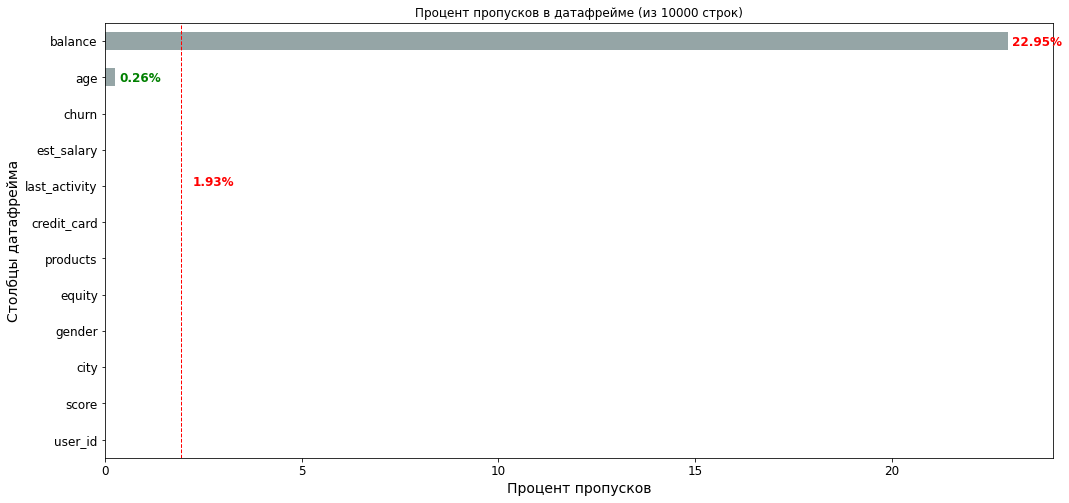

In [8]:
# Строим горизонтальную столбчатую диаграмму пропусков
# Используем функцию для визуализации пропусков
def percent_hbar(df, old_threshold=None):
    percent_of_nulls = (df.isnull().sum() / len(df) * 100).sort_values().round(2)
    threshold = percent_of_nulls.mean()
    ax = percent_of_nulls.plot(
        kind='barh', figsize=(17, 8), 
        title='Процент пропусков в датафрейме (из {} строк)'.format(len(df)), 
        color='#95a5a6', legend=False, fontsize=12
    )
    ax.set_xlabel('Процент пропусков', fontsize=14)  # Подпись оси X
    ax.set_ylabel('Столбцы датафрейма', fontsize=14)  # Подпись оси Y
    dict_percent = dict(percent_of_nulls)
    i = 0
    for k in dict_percent:
        color = 'green'
        if dict_percent[k] > 0:
            if dict_percent[k] > threshold:
                color = 'red'
            ax.text(dict_percent[k] + 0.1, i + 0.09, str(dict_percent[k]) + '%', 
                    color=color, fontweight='bold', fontsize='large')
        i += 0.98
    if old_threshold is not None:
        plt.axvline(x=old_threshold, linewidth=1, color='r', linestyle='--')
        ax.text(old_threshold + 0.3, 10, '{0:.2%}'.format(old_threshold / 100), 
                color='r', fontweight='bold', fontsize='large')
        plt.axvline(x=threshold, linewidth=1, color='green', linestyle='--')
        ax.text(threshold + 0.3, 7, '{0:.2%}'.format(threshold / 100), 
                color='green', fontweight='bold', fontsize='large')
    else:
        plt.axvline(x=threshold, linewidth=1, color='r', linestyle='--')
        ax.text(threshold + 0.3, 7, '{0:.2%}'.format(threshold / 100), 
                color='r', fontweight='bold', fontsize='large')
    return ax, threshold

# Применение функции к датафрейму
plot, threshold = percent_hbar(bank_clients_data)

# Отображение графика
plt.show()

# Улучшаем качество графика
%config InlineBackend.figure_format = 'retina'

Согласно полученной визуализации, **средний процент пропусков находится примерно на уровне 1,93%** (обозначен красной вертикальной линией). Столбцы с процентом выше этого значения (`balance`) можно считать проблемными для анализа. 

В столбце `age`  **0,26%** пропусков, что значительно ниже среднего процента пропусков для текущего датафрейма. В столбце `balance` целых **22.95%** пропусков, что на **20%** выше среднего процента пропусков для текущего датафрейма.

Для дальнейших шагов в работе с пропусков сначала проверим, существуют ли закономерности в пропусках (паттерны), то есть определим, связаны ли они с определёнными группами клиентов или распределены случайным образом (например, пропуски могут чаще встречаться у клиентов из конкретных городов или с определёнными характеристиками).

Выведем **сводную информацию по категориальным признакам**:

In [9]:
# Фильтруем строки с пропущенными значениями 
missing_balance_clients = bank_clients_data[bank_clients_data['balance'].isna()]
missing_age_clients = bank_clients_data[bank_clients_data['age'].isna()]

# Определяем категориальные признаки
categorical_columns = ['city', 'gender', 'credit_card', 'last_activity']

# Создаем список для хранения результатов
summary_tables = []

# Анализ пропусков по `balance` и `age`
for col in categorical_columns:
    # Подсчет количества пропусков по категории (balance) и (age)
    missing_counts_balance = missing_balance_clients[col].value_counts()
    missing_counts_age = missing_age_clients[col].value_counts()
    total_counts = bank_clients_data[col].value_counts()

    # Рассчитываем процент пропусков и форматируем в виде процентов
    missing_percent_balance = ((missing_counts_balance / total_counts * 100).round(2)).astype(str) + '%'
    missing_percent_age = ((missing_counts_age / total_counts * 100).round(2)).astype(str) + '%'

    # Объединяем данные в один DataFrame
    missing_summary = pd.DataFrame({
        'Признак': col,
        'Категория': total_counts.index,
        'Число клиентов с пропуском (balance)': missing_counts_balance.reindex(total_counts.index, fill_value=0).values,
        'Процент от всех клиентов (balance)': missing_percent_balance.reindex(total_counts.index, fill_value='0.00%').values,
        'Число клиентов с пропуском (age)': missing_counts_age.reindex(total_counts.index, fill_value=0).values,
        'Процент от всех клиентов (age)': missing_percent_age.reindex(total_counts.index, fill_value='0.00%').values
    })

    # Добавляем таблицу в список
    summary_tables.append(missing_summary)

# Объединяем все таблицы в один DataFrame
final_missing_summary = pd.concat(summary_tables, ignore_index=True)

# Переставляем порядок столбцов для удобства
final_missing_summary = final_missing_summary[['Признак', 'Категория', 'Число клиентов с пропуском (balance)', 'Процент от всех клиентов (balance)',
                                               'Число клиентов с пропуском (age)', 'Процент от всех клиентов (age)']]

# Функция для выделения максимальных значений в каждом признаке
def highlight_max_per_feature(df, feature_col, value_cols):
    """Выделяет максимальные значения в каждом признаке цветом."""
    styles = pd.DataFrame("", index=df.index, columns=df.columns)
    
    for feature in df[feature_col].unique():
        mask = df[feature_col] == feature  # Фильтруем строки по признаку
        for col in value_cols:
            max_value = df.loc[mask, col].max()
            styles.loc[mask & (df[col] == max_value), col] = 'background-color: lightcoral'
    
    return styles

# Определяем столбцы, где нужно выделять максимальные значения
highlight_columns = ['Число клиентов с пропуском (balance)', 'Процент от всех клиентов (balance)', 
                     'Число клиентов с пропуском (age)', 'Процент от всех клиентов (age)']

# Применяем стилизацию, если `final_missing_summary` существует
if 'final_missing_summary' in globals():
    styled_missing_summary = final_missing_summary.style.apply(
        highlight_max_per_feature, 
        feature_col='Признак', 
        value_cols=highlight_columns, 
        axis=None
    )

# Вывод таблицы с выделением
styled_missing_summary

,Признак,Категория,Число клиентов с пропуском (balance),Процент от всех клиентов (balance),Число клиентов с пропуском (age),Процент от всех клиентов (age)
0,city,Ярославль,1467,24.92%,13,0.22%
1,city,Рыбинск,593,22.0%,12,0.45%
2,city,Ростов,235,16.58%,1,0.07%
3,gender,М,1282,25.61%,14,0.28%
4,gender,Ж,1013,20.28%,12,0.24%
5,credit_card,1,1872,27.51%,20,0.29%
6,credit_card,0,423,13.24%,6,0.19%
7,last_activity,1,1261,24.09%,20,0.38%
8,last_activity,0,1034,21.7%,6,0.13%


Исходя из полученных данных, можно заметить, что пропуски в **balance** и **age** распределены неравномерно среди клиентов, что может указывать на наличие определённых закономерностей:

- **пропуски в `balance`** чаще встречаются в **Ярославле**, среди **мужчин**, а также у **клиентов с кредитной картой**. Кроме того, они **более характерны для активных клиентов**. Максимальный процент пропусков наблюдается у **держателей кредитных карт (27.51%)**, а также среди мужчин (25.61%).  
- **пропуски в `age`** встречаются значительно реже, однако их процент выше в **Рыбинске (0.45%)** по сравнению с Ярославлем (0.22%). Также пропуски чаще встречаются у **активных клиентов (0.38%) и держателей кредитных карт (0.29%)**.  

Хотя пропуски в **balance** имеют явные закономерности, **распределение пропусков в age более равномерное**, без выраженных зависимостей. Однако, на основе только этих наблюдений сложно однозначно судить о причинах пропусков.  

**Следующий шаг** - провести **анализ корреляции пропусков с другими признаками**, чтобы определить возможные зависимости и понять, какие факторы могут влиять на их возникновение. 

Начнем с кодирования пропусков для использования в дальнейшем анализе корреляции.

#### Кодирование пропусков (создание бинарных признаков)

Произведем **кодирование данных с пропусками** для использования в дальнейшем анализе корреляции. А именно, **создадим бинарный признак наличия пропуска** (`0` — нет пропуска, `1` — пропуск есть) для последующей проверки корреляции данных с пропусками с другими характеристиками.

In [10]:
# Создаем бинарные признаки наличия пропусков (0 — нет, 1 — есть)
bank_clients_data['balance_missing'] = bank_clients_data['balance'].isna().astype(int)
bank_clients_data['age_missing'] = bank_clients_data['age'].isna().astype(int)

# Проверяем (см. на столбцы balance_missing, age_missing)
bank_clients_data.head(10)

,user_id,score,city,gender,age,equity,balance,products,credit_card,last_activity,est_salary,churn,balance_missing,age_missing
0,183012,850,Рыбинск,Ж,25,1,59214.82,2,0,1,75719.14,1,0,0
1,146556,861,Рыбинск,Ж,37,5,850594.33,3,1,0,86621.77,0,0,0
2,120722,892,Рыбинск,Ж,30,0,NaN,1,1,1,107683.34,0,1,0
3,225363,866,Ярославль,Ж,51,5,1524746.26,2,0,1,174423.53,1,0,0
4,157978,730,Ярославль,М,34,5,174.00,1,1,0,67353.16,1,0,0
5,202305,856,Рыбинск,М,56,4,863687.24,3,1,0,156619.80,0,0,0
6,177259,807,Ярославль,Ж,39,3,405042.44,3,0,1,103838.32,0,0,0
7,218868,825,Ярославль,Ж,38,4,458145.40,2,1,1,68085.48,0,0,0
8,211686,923,Ярославль,М,54,5,1206337.87,2,1,0,155371.79,0,0,0
9,133130,906,Ярославль,Ж,67,0,NaN,1,0,1,238055.53,0,1,0


Видим, что если в `balance` или `age` имеется пропуск (`NaN`), то в столбцах `balance_missing` и `age_missing` стоит 1, если значение присутствует - стоит `0`. 

Код работает корректно. Переходим к анализу корреляции пропусков с другими признаками.

#### Анализ корреляции пропусков с другими признаками
##### Кодирование категоральных переменных

Перед проведением анализа корреляции, скорее всего понадобится кодирование категориальных переменных.

Разберемся с данными:

- **бинарные признаки** (например, `credit_card`, `balance_missing`, `age_missing`) - оставим как есть (`0` и `1`);
- **упорядоченные  признаки** (например, `equity`, `products`) оставим числовыми, так как их порядок имеет смысл;
- с **неупорядоченными категориальными признаками** (`city`, `gender`) лучше использовать `one-hot кодирование`.

Следовательно, следующий тап -  закодировать (`one-hot` кодированием) категориальные переменные `city`, `gender`. Хоть мы и знаем, что в данных столбцах по 3 и 2 ункальных значения соответственно, все же для полной уверенности перед кодированием проверим количество уникальных значений в категориальных признаках, т.к. если, например, в `city` слишком много уникальных значений (более 50+), `one-hot` может привести к чрезмерному увеличению размерности данных. 

Начнем.

In [11]:
# Перед анализом кодируем категориальные переменные

# Проверяем количество уникальных значений в категориальных столбцах
print(f"Количество уникальных городов: {bank_clients_data['city'].nunique()}")
print(f"Уникальные значения в gender: {bank_clients_data['gender'].unique()}")

# Сохраняем копии оригинальных признаков перед кодированием
bank_clients_data['city_original'] = bank_clients_data['city']
bank_clients_data['gender_original'] = bank_clients_data['gender']

# Применяем one-hot encoding только к нужным категориальным признакам
bank_clients_data = pd.get_dummies(bank_clients_data, columns=['city', 'gender'], drop_first=False)
# т.к. уникальных значений в  city и gender мало, в код ставим условие: drop_first=False - закодировать без исключения первой категории

# Проверяем результат кодирования
bank_clients_data.head()

Количество уникальных городов: 3
Уникальные значения в gender: ['Ж' 'М']


,user_id,score,age,equity,balance,products,credit_card,last_activity,est_salary,churn,balance_missing,age_missing,city_original,gender_original,city_Ростов,city_Рыбинск,city_Ярославль,gender_Ж,gender_М
0,183012,850,25,1,59214.82,2,0,1,75719.14,1,0,0,Рыбинск,Ж,0,1,0,1,0
1,146556,861,37,5,850594.33,3,1,0,86621.77,0,0,0,Рыбинск,Ж,0,1,0,1,0
2,120722,892,30,0,NaN,1,1,1,107683.34,0,1,0,Рыбинск,Ж,0,1,0,1,0
3,225363,866,51,5,1524746.26,2,0,1,174423.53,1,0,0,Ярославль,Ж,0,0,1,1,0
4,157978,730,34,5,174.00,1,1,0,67353.16,1,0,0,Ярославль,М,0,0,1,0,1


Проверка результата кодирования показала, что **все работает корректно**:

- количество уникальных городов: 3 (это соответствует данным: Рыбинск, Ярославль, Ростов);
- уникальные значения в gender: [`Ж`, `М`];
- созданы новые закодированные столбцы:
    - `city_Рыбинск` (индикатор города Рыбинска);
    - `city_Ярославль` (индикатор города Ярославля);
    - `city_Ростов` (индикатор города Ростова);
    - `gender_М` (индикатор мужчин, женщины кодируются 0);
    - `gender_Ж` (индикатор женщин, женщины кодируются 1);
- исходные категориальные переменные сохранены:
    - `city_original`;
    - `gender_original`;
- проверка значений первых пяти сток показала корректные результаты. 

Переходим теперь к расчету корреляции между пропусками и данными.

##### Расчет корреляции между бинарными признаками пропусков и остальными столбцами

Теперь выполним **расчет корреляции между бинарными признаками пропусков и остальными столбцами**. Полученные результаты представим в виде таблицы, а для наглядности визуализируем данные с помощью тепловой карты (heatmap).

Корреляция бинарных признаков пропусков с остальными столбцами:


,balance_missing,age_missing
score,0.138871,0.005035
age,-0.028659,NaN
equity,-0.709951,-0.032040
balance,NaN,0.007686
products,-0.487512,-0.033751
credit_card,0.158334,0.009726
last_activity,0.028362,0.025120
est_salary,0.307154,0.011252
churn,-0.249421,-0.018994
balance_missing,1.000000,0.046852


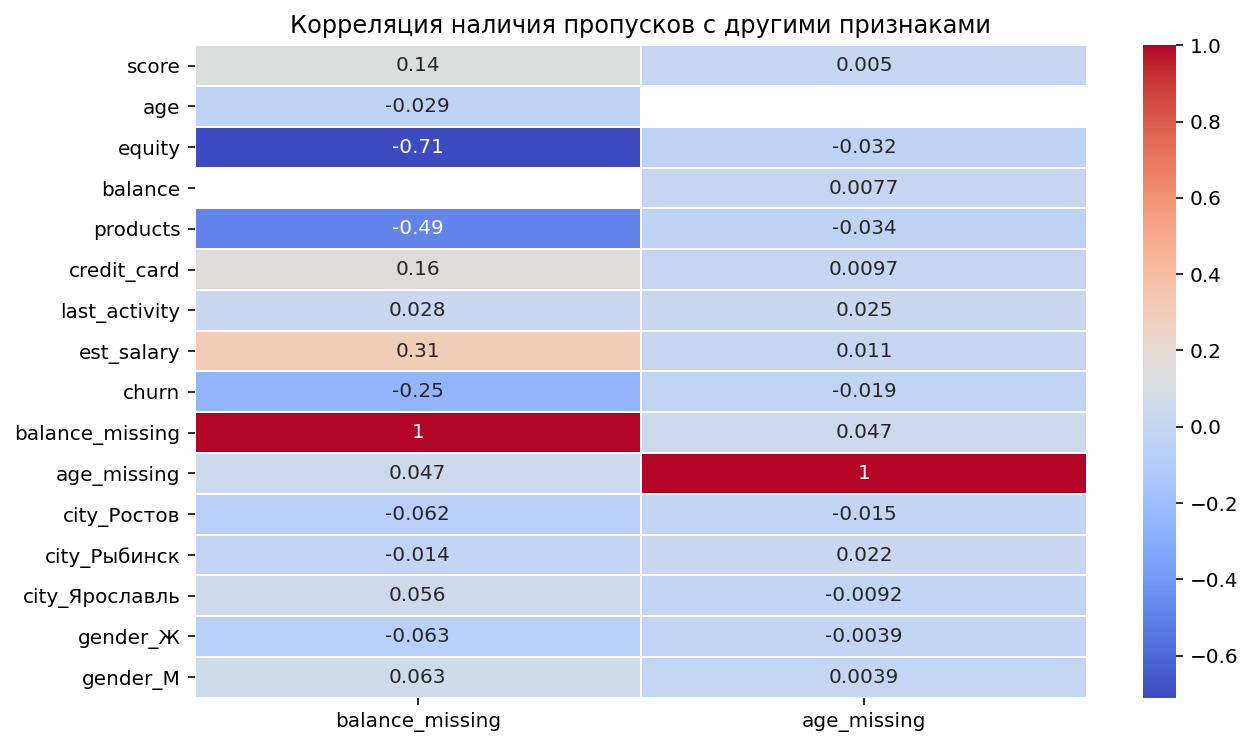

In [12]:
# Перед построением матрицы корреляции удаляем оригинальные категориальные признаки
correlation_data = bank_clients_data.drop(columns=['user_id', 'city_original', 'gender_original'])

# Строим матрицу корреляции бинарных признаков пропусков с остальными столбцами
correlation_matrix = correlation_data.corr()

# Вывод корреляции для пропусков
missing_correlation = correlation_matrix[['balance_missing', 'age_missing']]
print('Корреляция бинарных признаков пропусков с остальными столбцами:')
display(missing_correlation)

# Визуализируем с помощью тепловой карты
plt.figure(figsize=(10, 6))
sns.heatmap(missing_correlation, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Корреляция наличия пропусков с другими признаками")

# Улучшаем качество графика
%config InlineBackend.figure_format = 'retina'

plt.show()

На основе полученных результатов можно отметить следующие наблюдения:

**Пропуски в `balance` (`balance_missing`) наиболее сильно коррелируют с:**

- `equity` (**-0.71**) - чем больше баллов собственности, тем реже встречаются пропуски в `balance`;
- `products` (**-0.49**) - клиенты с большим количеством продуктов реже имеют пропущенный баланс;
- `est_salary` (**0.31**) - у клиентов с высокой зарплатой чаще встречаются пропуски в `balance`;
- `churn` (**-0.25**) - у клиентов с пропущенным `balance` ниже вероятность оттока.

**Пропуски в `age` (`age_missing`) не демонстрируют высокой корреляции с другими признаками:**
- наибольшая связь с `balance_missing` (**0.047**), но она слабая;
- незначительная отрицательная корреляция с `products` и `equity`.


Таким образом, можно сделать вывод о том, что **пропуски в `balance` не случайны**. Они зависят от количества продуктов, собственности и дохода клиента.

Возможно, клиенты с большим числом продуктов (`products`) реже сталкиваются с отсутствием данных о балансе, потому что их счета активнее используются. `equity` (баллы собственности) сильно отрицательно коррелируют с `balance_missing`, что может означать, что клиенты с высоким уровнем собственности имеют более полные финансовые данные. Более высокий доход (`est_salary`) связан с пропусками `balance`, возможно, из-за других финансовых инструментов или категорий счетов, а может просто этим клиентам не очень хочется заморачиваться и тратить время на заполнение сведений о наличии средств и т.д.

**Пропуски в age скорее случайны** – они не имеют значимой корреляции ни с одним из ключевых факторов.

**Общие результаты данного этапа:** 
1. Пропуски в `balance` **имеют закономерности** и связаны с другими признаками, их распределение не случайно.  
2. Пропуски в `age`, напротив, **не демонстрируют зависимости** от других характеристик и распределены случайным образом.

Далее проведем работу по определению взаимосвязи пропусков в балансе с ключевыми показателями (количеством продуктов, собственности и дохода клиента).

#### Определение контекста данных. Взаимосвязь пропусков в балансе с ключевыми показателями 

Ранее мы выяснили, что пропуски в столбце `age` скорее случайны – они не имеют значимой корреляции ни с одним из ключевых факторов.

А вот пропуски в `balance` имеют корреляцию с другими данными. Они зависят от количества продуктов, собственности и дохода клиента. 

Чтобы до конца понять, почему пропуски могут появляться в этом столбце дополнительно осуществим следующие действия:
- проанализируем распределение `balance` в зависимости от `equity` и `products`, чтобы определить, влияет ли уровень `equity` на заполненность баланса. Кроме того, если высокие значения `balance` окажутся связаны с количеством используемых продуктов (`products`), это позволит выявить, какие клиенты обладают крупными счетами;
- изучим связь `est_salary` и `balance_missing`. Если доход выше у клиентов с пропущенным `balance`, это может указывать на специфические группы клиентов;
- определим, какие клиенты выбиваются из общей массы;
- и на основании всего вышеперечисленного выделим возможные причины возникновения пропусков в столбце `balance`.

Начнем с проверка распределения `balance` в зависимости от `equity`.

##### Анализ распределения пропусков в `balance` в зависимости от `equity`

Для того, чтобы проверить распределение `balance` в зависимости от `equity`, построим два боксплота. Первый "ящик с усами" будет с полным диапазоном данных, второй - с ограниченным, чтобы более укрупненно посмотреть на данные. 

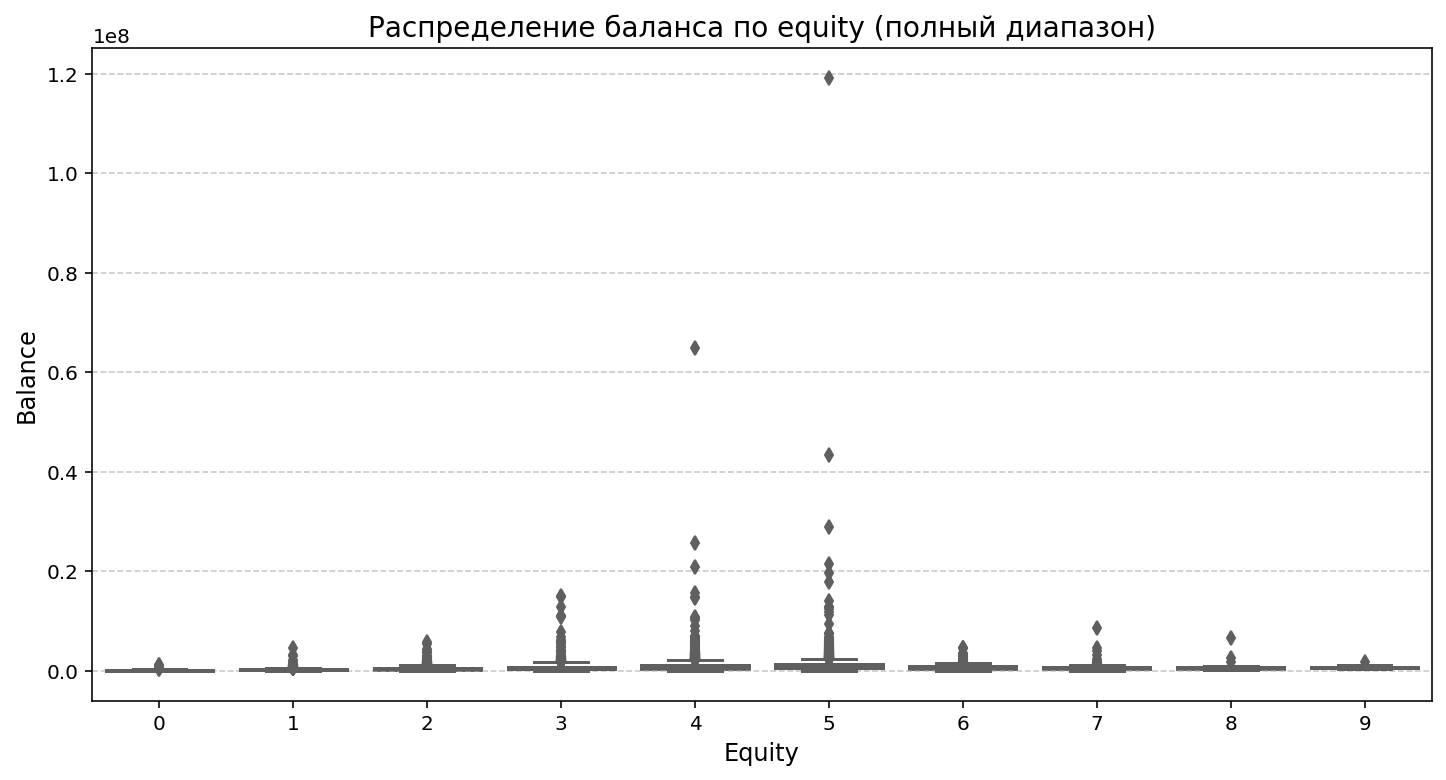

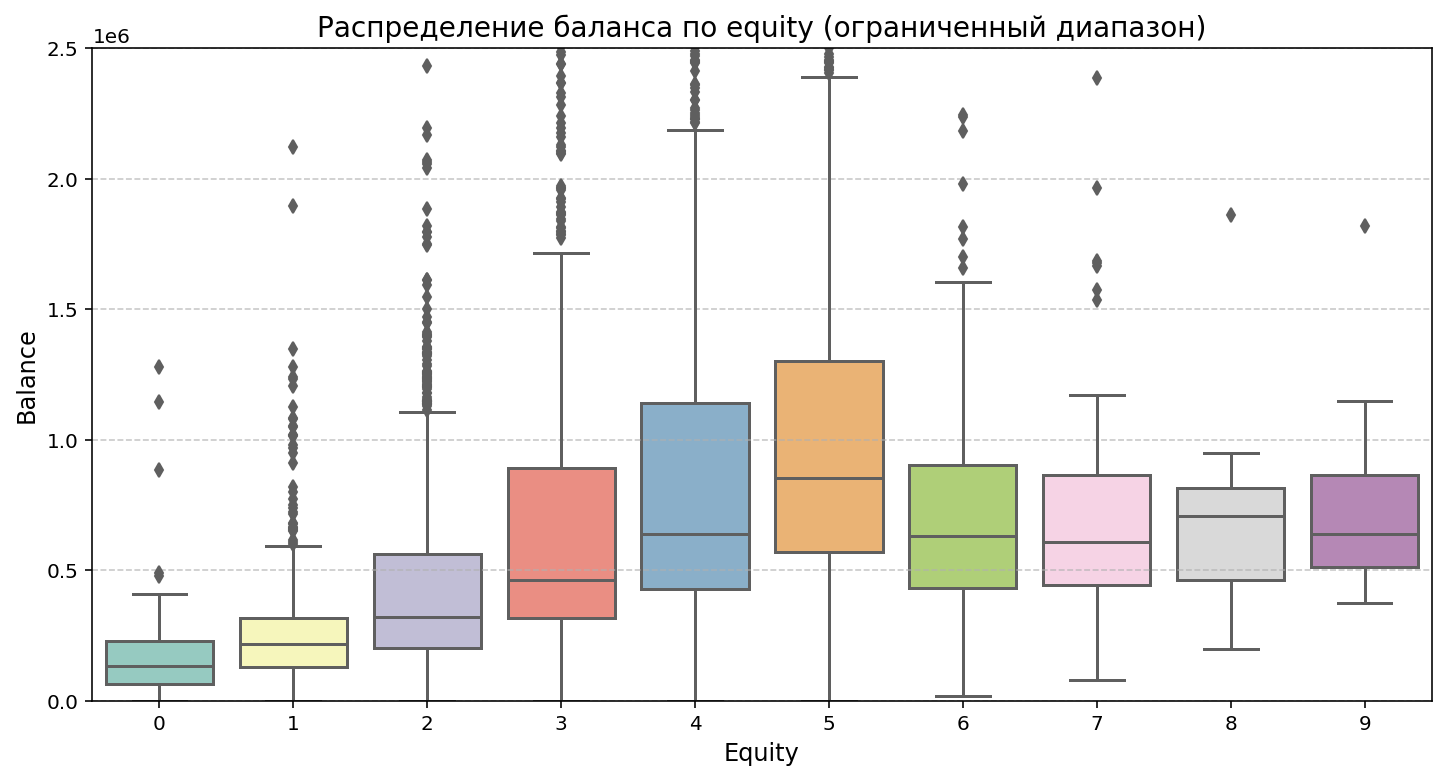

In [13]:
# Построение первого "ящика с усами" (полный диапазон данных)
plt.figure(figsize=(12, 6))
sns.boxplot(x=bank_clients_data['equity'], y=bank_clients_data['balance'], palette='Set3')
plt.title('Распределение баланса по equity (полный диапазон)', fontsize=14)
plt.xlabel('Equity', fontsize=12)
plt.ylabel('Balance', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Построение второго "ящика с усами" (ограниченный диапазон Y-оси)
plt.figure(figsize=(12, 6))
sns.boxplot(x=bank_clients_data['equity'], y=bank_clients_data['balance'], palette='Set3')
plt.title('Распределение баланса по equity (ограниченный диапазон)', fontsize=14)
plt.xlabel('Equity', fontsize=12)
plt.ylabel('Balance', fontsize=12)
plt.ylim(0, 2.5e6)  # Ограничение Y-оси для исключения выбросов
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Из полученных графиков видим, что  
- основная часть клиентов имеет **низкие балансы**, независимо от уровня `equity`;  
- большинство значений `balance` сосредоточено около **нуля**, а медианный баланс для большинства групп остаётся относительно небольшим; 
- примерно 75% клиентов имеют баланс ниже 2.2 млн. руб.  
- у клиентов с `equity` = 4 и `equity` = 5 встречаются **очень высокие балансы**, вплоть до **120+ млн. руб.**.  
- в остальных группах `equity` разброс также значительный, но экстремальные значения сконцентрированы именно в диапазоне **4-5**, что может указывать на:  
     - VIP-клиентов с активными счетами, содержащими крупные суммы; 
     - возможные аномалии или ошибки в данных;
     - использование более сложных финансовых инструментов (инвестирование, бизнес-счета).  
- **после `equity` = 6 баланс вновь снижается**, и распределение становится более равномерным;  
- есть **отдельные клиенты** с балансами свыше **200 млн**, которые выбиваются из общего тренда; 
- у клиентов с `equity` **6, 7, 8, 9** почти **нет экстремально высоких балансов**. Это, как уже говорилось выше, может свидетельствовать о том, что они используют **другие финансовые инструменты**, такие как **инвестиции, кредитные линии или бизнес-активы** вместо хранения средств на счёте.  

Теперь **подсчитаем долю клиентов с пропущенным `balance` в каждой категории `equity`** и на основе этих данных попытаемся сделать выводы о закономерностях пропусков.

In [14]:
# Группируем данные по equity, чтобы определить сколько клиентов в каждой категории имеют пропуски.
missing_by_equity = bank_clients_data.groupby('equity')['balance_missing'].sum()

# Чтобы рассчитать долю пропусков, необходимо подсчитать общее число клиентов в каждой категории equity:
total_by_equity = bank_clients_data['equity'].value_counts().sort_index()

# Далее произведем расчет процента пропусков в balance для каждой категории equity
percent_missing_by_equity = (missing_by_equity / total_by_equity * 100).round(2)

# Вывод результатов в виде таблицы
missing_summary = pd.DataFrame({
    'Число клиентов с пропуском': missing_by_equity,
    'Общее число клиентов': total_by_equity,
    'Процент пропусков': percent_missing_by_equity
}).fillna(0)
display(missing_summary)

,Число клиентов с пропуском,Общее число клиентов,Процент пропусков
0,2180,2592,84.10
1,114,774,14.73
2,0,1052,0.00
3,1,1543,0.06
4,0,1850,0.00
5,0,1918,0.00
6,0,161,0.00
7,0,80,0.00
8,0,17,0.00
9,0,13,0.00


Таким образом,связывая пропуски в `balance` с `equity` можно сделать следующий наблюдения:

- **клиенты с `equity = 0` имеют наибольшую долю пропусков в `balance` (84.1%)**. Это может указывать на то, что для таких клиентов баланс **не фиксируется**, если они используют, например, только кредитные продукты или дебетовые карты без накоплений;
- **для `equity = 1`** доля пропусков значительно ниже (14.73%), что может говорить о том, что часть клиентов в этой категории уже имеет учтённые балансы, но всё же остаётся группа без зафиксированных данных;
- **для `equity = 2 и выше` пропуски практически отсутствуют** (0-0.06%), что подтверждает гипотезу о том, что у этих клиентов **баланс фиксируется**, возможно, из-за наличия более активных счетов и управляемых средств;
- **для `equity > 6` доля пропусков не увеличивается**, в отличие от первоначального предположения. Напротив, в этой группе баланс фиксируется практически у всех клиентов, что может говорить о том, что они используют банковские счета, а не альтернативные финансовые инструменты.  

Таким образом, пропуски в `balance` в основном характерны для клиентов с **нулевым `equity`**, в меньшей степени — для `equity = 1`, и практически не встречаются в остальных категориях.

##### Анализ распределения  пропусков  в `balance` в зависимости от `products`

Анализ распределения `balance` в зависимости от `products` может помочь определить, связаны ли высокие значения `balance` с количеством используемых продуктов. Если такая связь обнаружится, это позволит выявить клиентов с крупными счетами.

Здесь выполним аналогичные с предыдущим шагом действия: построим два боксплота - с полным и ограниченным диапазоном данным. 

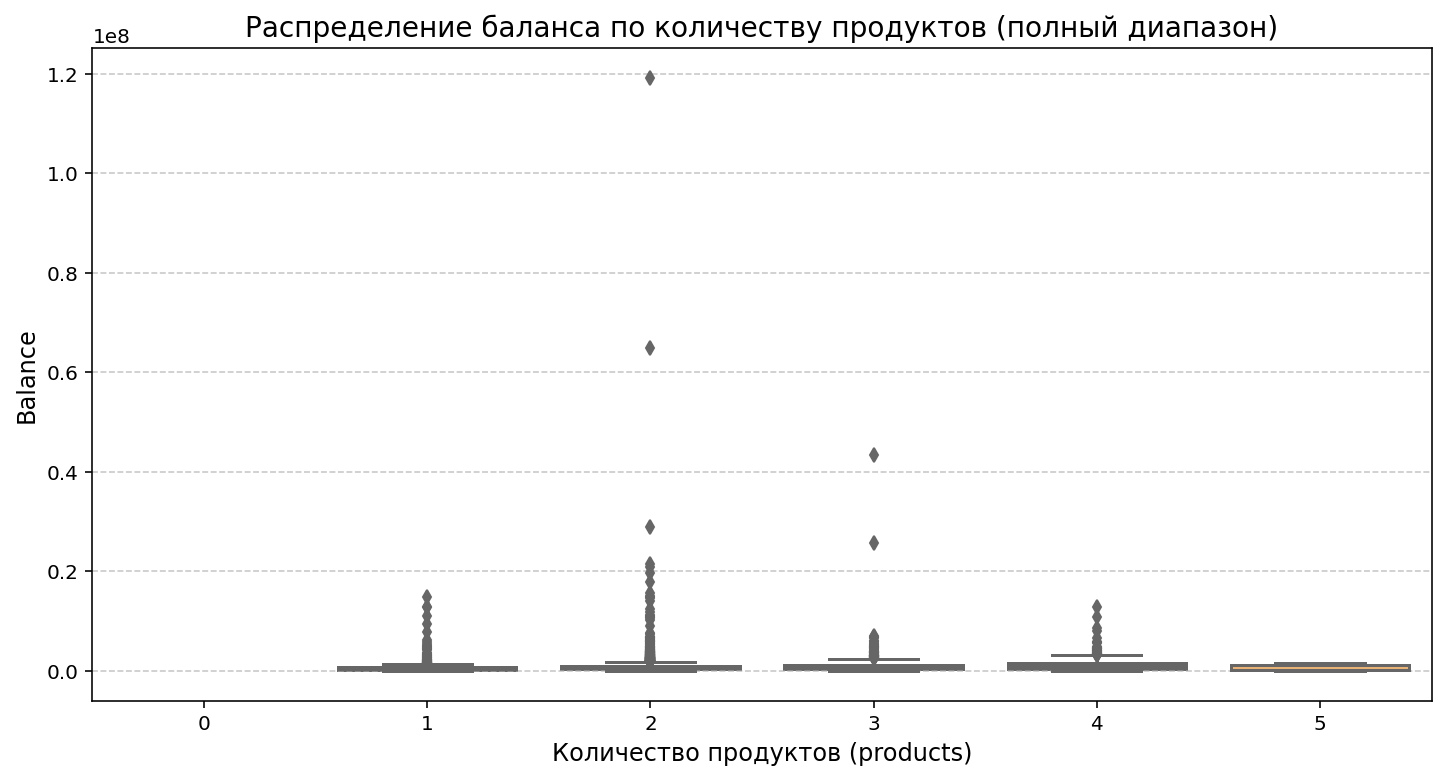

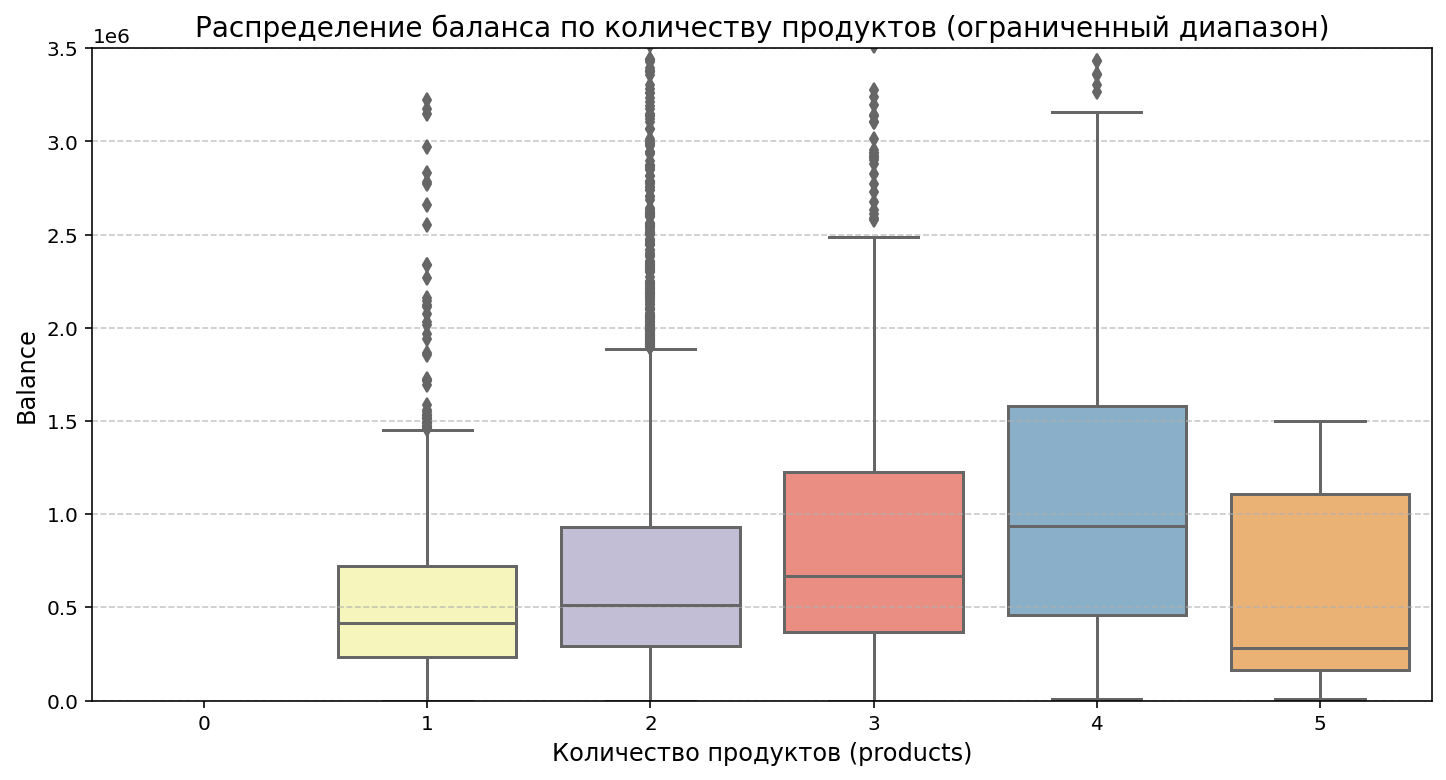

In [15]:
# Построение первого "ящика с усами" (полный диапазон данных)
plt.figure(figsize=(12, 6))
sns.boxplot(x=bank_clients_data['products'], y=bank_clients_data['balance'], palette='Set3')
plt.title('Распределение баланса по количеству продуктов (полный диапазон)', fontsize=14)
plt.xlabel('Количество продуктов (products)', fontsize=12)
plt.ylabel('Balance', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Построение второго "ящика с усами" (ограниченный диапазон Y-оси)
plt.figure(figsize=(12, 6))
sns.boxplot(x=bank_clients_data['products'], y=bank_clients_data['balance'], palette='Set3')
plt.title('Распределение баланса по количеству продуктов (ограниченный диапазон)', fontsize=14)
plt.xlabel('Количество продуктов (products)', fontsize=12)
plt.ylabel('Balance', fontsize=12)
plt.ylim(0, 3.5e6)  # Ограничение Y-оси для исключения выбросов
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Из полученных графиков видим, что:
- в целом, медианный баланс увеличивается с ростом количества продуктов, за исключением киентов с 5 продуктами;
- пик медианного баланса приходится на 4 продукта – он выше всех остальных;
- для 5 продуктов медианный баланс заметно снижается и оказывается ниже, чем у клиентов с 3-4 продуктами;
- экстремально высокие балансы наблюдаются в основном у клиентов с 2-4 продуктами;
- разброс баланса наиболее выражен для клиентов с 2-4 продуктами;
- клиенты с 5 продуктами имеют более узкий диапазон балансов, что может указывать на специфическую категорию пользователей.

Клиенты с 5 продуктами:
- их медианный баланс оказался самым низким среди всех групп. Это может свидетельствовать о том, что в эту категорию попадают клиенты, использующие широкий спектр продуктов, но не имеющие значительных остатков на счетах (например, они могут активнее использовать кредитные продукты, инвестиции или расходные счета).

Таким образом:
- **оптимальное количество продуктов для крупных остатков на счетах - 4**. Клиенты с таким количеством продуктов имеют самый высокий медианный баланс;
- клиенты с **5 продуктами** могут относиться к другой группе - возможно, они более активны в использовании кредитных или инвестиционных инструментов, но держат меньше средств на банковских счетах;
- широкий разброс балансов у клиентов с 1-3 продуктами говорит о наличии разных типов пользователей в этих группах.

Далее **подсчитаем долю клиентов с пропущенным `balance` в каждой категории `products`** и на основе этих данных попытаемся сделать выводы о закономерностях пропусков.

In [16]:
# Группируем данные по products, чтобы определить, сколько клиентов в каждой категории имеют пропуски.
missing_by_products = bank_clients_data.groupby('products')['balance_missing'].sum()

# Подсчитываем общее число клиентов в каждой категории products
total_by_products = bank_clients_data['products'].value_counts().sort_index()

# Рассчитываем процент пропусков в balance для каждой категории products
percent_missing_by_products = (missing_by_products / total_by_products * 100).round(2)

# Формируем итоговую таблицу
missing_summary_products = pd.DataFrame({
    'Число клиентов с пропуском': missing_by_products,
    'Общее число клиентов': total_by_products,
    'Процент пропусков': percent_missing_by_products
}).fillna(0)

display(missing_summary_products)

,Число клиентов с пропуском,Общее число клиентов,Процент пропусков
0,1,1,100.00
1,1950,3341,58.37
2,315,5126,6.15
3,29,1039,2.79
4,0,474,0.00
5,0,19,0.00


Таким образом,связывая пропуски в `balance` с `products` можно сделать следующий наблюдения:

- доля пропусков **самая высокая среди клиентов с 1 продуктом – 58.37%** из них не имеют данных о балансе;
- клиенты с **2-3 продуктами** имеют сравнительно низкую долю пропусков (6.15% и 2.79% соответственно), что может свидетельствовать о более стабильном профиле использования банковских услуг;
- **пропуски** в balance полностью **отсутствуют** для клиентов с **4 и 5 продуктами**. Это подтверждает, что клиенты с таким количеством продуктов более активны и их данные фиксируются корректно.

Таким образом:

1. Чем больше продуктов у клиента, тем выше вероятность, что его баланс будет фиксироваться. Для клиентов с 4-5 продуктами пропусков в balance нет.
2. Клиенты с 1 продуктом имеют наибольшую долю пропусков. Это может говорить о том, что такие клиенты либо используют только кредитные продукты, либо их баланс не учитывается в общей системе.

##### Анализ распределения  пропусков в `balance` в зависимости от  `est_salary`

Дополнительно изучим связь `est_salary` и `balance_missing`.  Найдем возможные паттерны у пропусков в балансе в зависимости от дохода клиента. Это так же может указать на специфические группы клиентов, если доход выше у клиентов с пропущенным `balance`.

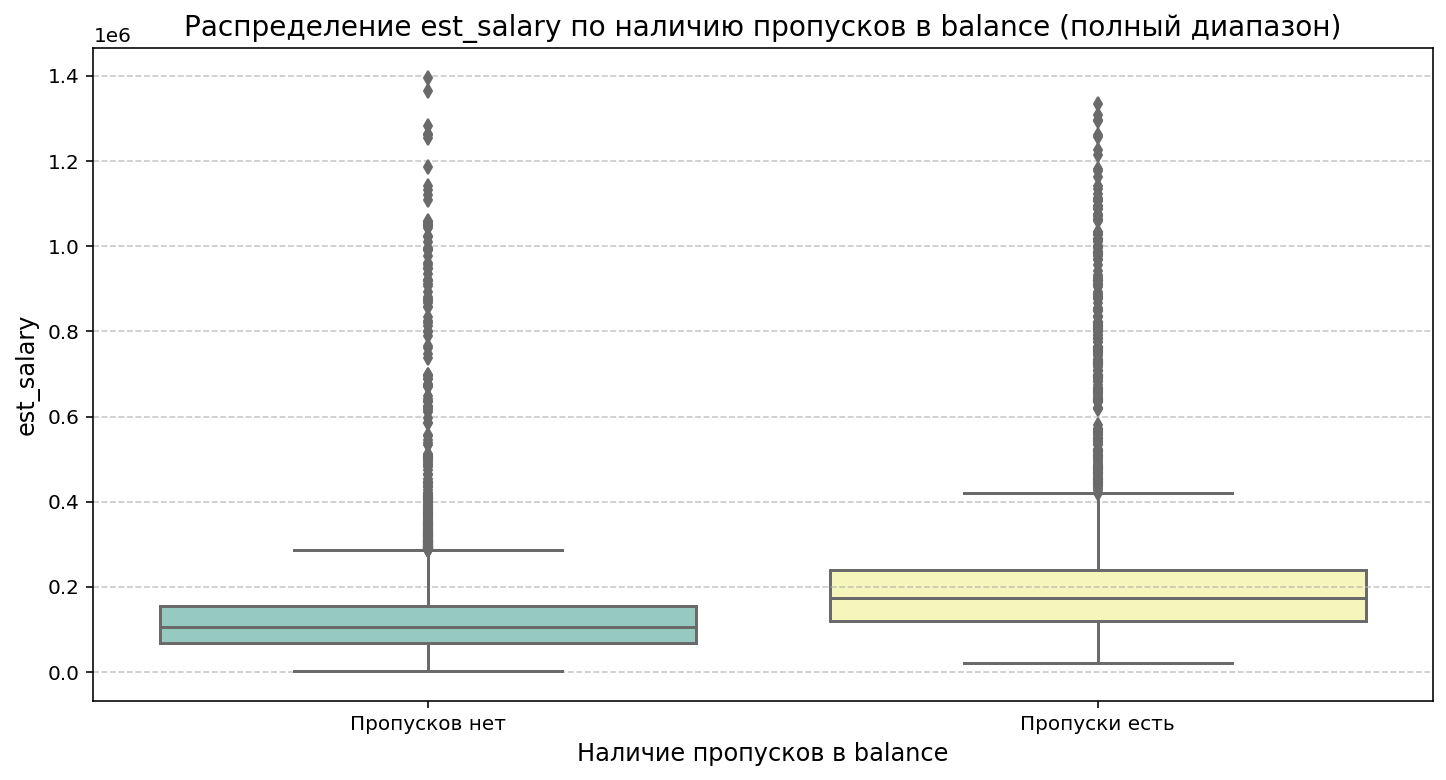

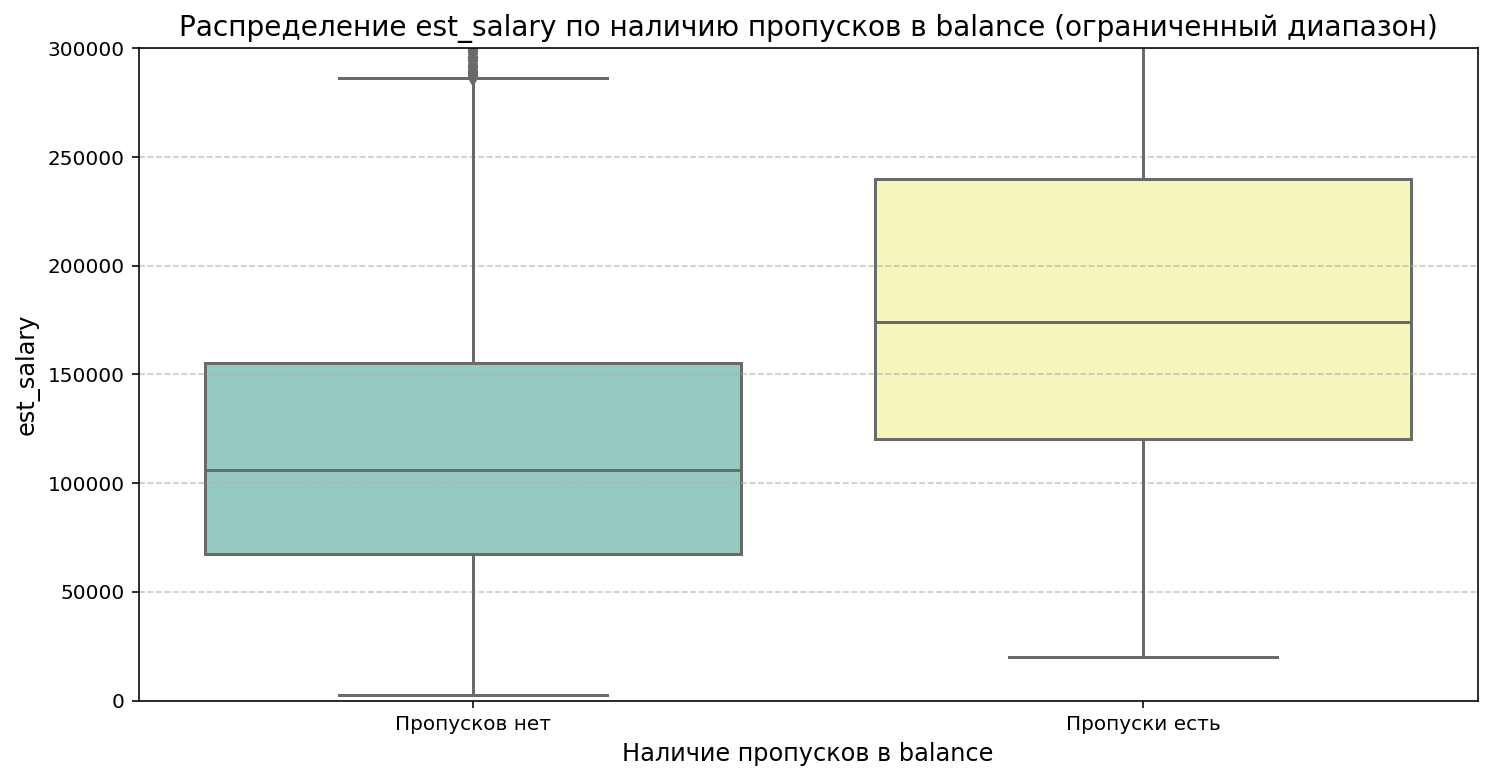

In [17]:
# Создаём словарь для замены значений
labels_mapping = {0: 'Пропусков нет', 1: 'Пропуски есть'}

# Построение первого "ящика с усами" (полный диапазон данных)
plt.figure(figsize=(12, 6))
sns.boxplot(x=bank_clients_data['balance_missing'].replace(labels_mapping), 
            y=bank_clients_data['est_salary'], 
            palette='Set3')
plt.title('Распределение est_salary по наличию пропусков в balance (полный диапазон)', fontsize=14)
plt.xlabel('Наличие пропусков в balance', fontsize=12)
plt.ylabel('est_salary', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Построение второго "ящика с усами" (ограниченный диапазон Y-оси)
plt.figure(figsize=(12, 6))
sns.boxplot(x=bank_clients_data['balance_missing'].replace(labels_mapping), 
            y=bank_clients_data['est_salary'], 
            palette='Set3')
plt.title('Распределение est_salary по наличию пропусков в balance (ограниченный диапазон)', fontsize=14)
plt.xlabel('Наличие пропусков в balance', fontsize=12)
plt.ylabel('est_salary', fontsize=12)
plt.ylim(0, 300000)  # Ограничение Y-оси для исключения выбросов
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

 Вывод по распределению `est_salary` в разрезе пропусков в `balance`:

- У клиентов с пропущенными значениями в `balance` **медианный доход (`est_salary`) выше**, чем у тех, у кого `balance` заполнен. Это может указывать на то, что клиенты с более высокими доходами **могут не использовать стандартные счета**, либо данные по их балансам фиксируются иначе;
- на графике с полным диапазоном данных заметны **выбросы** — есть клиенты с очень высокими зарплатами (свыше 1.4 млн). После ограничения шкалы видно, что **основная масса** клиентов без пропусков имеет медианный доход около **150 тыс.**, а у клиентов с пропусками — **около 200 тыс.;**
- **клиенты с более высоким доходом реже хранят деньги на стандартных банковских счетах**, предпочитая **инвестиционные или накопительные продукты**. У таких клиентов баланс может не отображаться в стандартных данных, если у них нет традиционных накопительных счетов.

Итог:

Пропуски в `balance` **не случайны** и связаны с уровнем дохода клиентов: чем выше `est_salary`, тем больше вероятность, что значение `balance` отсутствует. Это подтверждает гипотезу о том, что клиенты с высокими доходами могут пользоваться альтернативными финансовыми инструментами вместо стандартных счетов.

##### Закономерности в пропусках, краткий вывод

Проведенный анализ показал, что **пропуски в балансе (`balance`) имеют четкие закономерности** и связаны с рядом факторов, в то время как **пропуски в возрасте (`age`) не демонстрируют зависимостей и являются случайными**.

**Закономерности пропусков в балансе (`balance`):** 

---
1. Связь с уровнем собственности (`equity`): 
   - **наибольшая доля пропусков (84.1%) приходится на клиентов с `equity` = 0**, что может свидетельствовать о том, что баланс не фиксируется для клиентов, использующих только кредитные продукты или дебетовые карты без накоплений;
   - с **увеличением equity доля пропусков значительно снижается**, и начиная с **`equity` = 2**, пропуски практически отсутствуют. Это может говорить о том, что у таких клиентов баланс фиксируется из-за наличия активных счетов и управляемых средств;  
   - для **`equity` > 6 пропуски снова не увеличиваются**, что опровергает гипотезу о переходе таких клиентов на другие финансовые инструменты. Напротив, у них баланс фиксируется, возможно, из-за использования банковских счетов вместо альтернативных инструментов.  
---
2. Связь с количеством используемых продуктов (`products`): 
   - **клиенты с 1 продуктом имеют наибольший процент пропусков (58.37%)**, что может говорить о том, что они либо используют только кредитные продукты, либо их баланс не учитывается в системе;  
   - у **клиентов с 2-3 продуктами** пропуски встречаются **реже (6.15% и 2.79%)**, что может свидетельствовать о более стабильном профиле использования банковских услуг;  
   - у **клиентов с 4 и 5 продуктами пропусков в `balance` нет**, что подтверждает гипотезу о том, что они являются более активными пользователями банковских продуктов.  
---
3. Связь с доходом (`est_salary`): 
   - **клиенты с пропущенным `balance` имеют медианный доход выше**, чем те, у кого `balance` заполнен; 
   - это может означать, что **клиенты с высокими доходами реже используют стандартные счета** и предпочитают альтернативные финансовые инструменты (например, инвестиционные или накопительные продукты); 
   - на графиках видно, что медианный доход клиентов без пропусков составляет около **150 тыс.**, а у клиентов с пропусками **около 200 тыс.;**  
   - таким образом, **чем выше доход клиента, тем выше вероятность отсутствия данных о балансе**. 

#### Определение типа пропусков (классификация пропусков) для дальнейшего принятия решения по их обработке

Перед принятием решения об обработке пропусков необходимо определить тип пропусков согласно общепринятой классификацией пропусков:

- **MCAR** (Missing Completely At Random / Отсутствует совершенно случайно) — пропуски не зависят от переменных и не ведут к систематической ошибке (смещение, bias), но увеличивают случайную ошибку (разброс, variance), можно их отбрасывать или заполнять, т.к. заполнение не повлияет на характер связи между заполняемой переменной и остальными;

- **MAR** (Missing At Random / Отсутствует случайно) — в рамках каждой из групп, которая есть в описываемой данными совокупности, распределение пропусков случайно, можно их отбрасывать;

- **MNAR** (Missing Not At Random / Отсутствует не случайно) — пропуски зависят от данных, без дополнительного обоснования их нельзя отбрасывать или заполнять одним значением, т.к. это приведёт к заметным искажениям.

Подведем еще раз **краткие итоги проведенного анализа пропусков** и окончательно классифицируем их типы в `balance` и `age`.

**1. Пропуски в `balance`**:  

- пропуски в `balance` коррелируют с `equity`, `products` и `est_salary`;
- чем выше `equity`, тем меньше пропусков - баланс фиксируется у клиентов с большим количеством активов;
 - чем выше `est_salary`, тем больше пропусков - клиенты с высокими доходами реже имеют заполненный `balance`;
- клиенты с большим числом продуктов (`products`) имеют меньше пропусков в `balance` - возможно, потому что у них есть активные счета.  

 **Вывод**: Пропуски в `balance` относятся к **MAR** (Missing At Random), так как они **зависят от других наблюдаемых данных** (доход, собственность, количество продуктов).  

 **2. Пропуски в `age`**:   

- `age_missing` не показывает существенных зависимостей с другими признаками; 
- пропуски равномерно распределены среди клиентов разных категорий (`city`, `gender`, `credit_card`, `products`).  

 **Вывод**: Пропуски в `age` относятся к **MCAR** (Missing Completely At Random), так как они **не зависят от других наблюдаемых данных** и распределены случайно. 
 

 **Заключение:**  
- Пропуски в **`balance` - MAR** (они связаны с уровнем дохода, количеством продуктов,  количеством баллов собственности). 
- Пропуски в **`age` - MCAR** (они случайны, их можно удалить, либо заменить медианным значением без риска искажения данных).

####  Обработка пропусков

Т.к. пропуски в столбце `age` относятся к типу `MCAR` (они случайны) и их количество в датасете очень мало (всего `0,26%`), принято решение их удалить без риска искажения данных.

In [18]:
# Удаление строк с пропусками в столбце 'age'
bank_clients_data = bank_clients_data.dropna(subset=['age'])

# Проверка
print(bank_clients_data.isna().sum())

user_id               0
score                 0
age                   0
equity                0
balance            2279
products              0
credit_card           0
last_activity         0
est_salary            0
churn                 0
balance_missing       0
age_missing           0
city_original         0
gender_original       0
city_Ростов           0
city_Рыбинск          0
city_Ярославль        0
gender_Ж              0
gender_М              0
dtype: int64


Пропуски в `balance` (22.95%) относятся к типу **MAR**, так как они связаны с уровнем дохода, количеством продуктов и баллами собственности (`equity`).  

Заполнение медианными или другими числовыми значениями может **исказить данные**, изменив реальное распределение балансов. Использование заглушек также нецелесообразно, поскольку это числовой столбец, и любое искусственное значение может внести **дополнительные искажения в анализ**.  

Чтобы **максимально сохранить структуру данных**, принято решение **оставить `NaN` без изменений**. При необходимости для анализа пропусков будет использоваться **бинарный индикатор `balance_missing`**, а также изучаться распределение балансов в разрезе различных групп клиентов.

### Вывод по разделу

В начале исследования нами были проведены первичный анализ и предобработка данных.

Первичный обзор данных показал, что в датафрейме `bank_clients_data (данные о клиентах банка «Метанпром»)`:

- содержится 10 000 строк и 12 столбцов;
- наименование столбцов не соответствуют стилю `snake_case`: `EST_SALARY` и `USERID` нужно привести к нижнему регистру и `USERID` разделить нижним подчеркиванием (`user_id`);
- не все указанные типы данных соответствуют данным, содержащимся в столбцах:
    - в столбцах `score` (баллы кредитного скоринга) и `age` (возраст) стоит тип данных `float64`, нужно преобразовать в `int`. Однако, если в этих столбцах присутствуют пропуски, преобразование в целочисленный тип может вызвать затруднения. В таком случае сначала нужно будет либо обработать пропущенные значения, либо преобразовать данные в целочисленный тип `Int64`, который поддерживает `NaN` (в отличие от обычного `int`). Причина в том, что `int` не поддерживает `NaN` и попытка преобразования вызовет ошибку;
- в 2-ух столбцах из 12-ти содержаться пропуски:
    - `age` - **26** пропусков (**0,26%** данных);
    - `balance` - **2295** пропусков (**22,95%** данных)
- максимальный балл кредитного скоринга - 1000, минимальная - 642; <a id='statistics_on_numeric_columns'></a>
- минимальный возраст пользователя - 18 лет, максимальный - 86 лет, медианный - 40 лет, средний - 43 года;
- максимальное количество баллов собственности - 9, минимальное - 0;
- максимальный баланс на счету пользователя - 119 113 600 руб., минимальный - 0 рублей, медианный - 524 272.2 руб., средний -  827 794,3 руб. Максимальный баланс сильно отличается от среднего и медианного, нужно будет в дальнейшем проверить этот столбец на наличие аномалий;
- максимальное количество продуктов, которыми пользуется клиент - 5, минимальное - 0, медианное - 2, среднее - 2;
- у клиентов не более одной кредитной карты;
- максимальный оценочный доход клиента (в месяц) - 1 395 064 руб., минимальный - 2 546,3 руб. (самозанятый, на неполную ставку?), медианный - 119 658,1 руб., средний - 147 866.9 руб. Здесь  бросается в глаза максимальная сумма ежемесячного дохода и минимальная. Рекомендуется в дальнейшем проверить данные на наличие аномалий;
- по количеству банков в городах лидирует головной офис в Ярославле - 5 888 отделений, в Рыбинском филиале - 2 695 отделений, в Ростовском - 1 417 отделений;
- мужчин среди клиентов банка - 5005, женщин - 4995. Пропорция практически 50/50. Разница в 0,1%.
- **явных дубликатов нет**;
- по **неявным дубликатам**:
    - количество дубликатов по `USERID`: 73;
    - количество дубликатов по `USERID` с совпадением по `gender` и `age`: 2;
- **целевая переменная** - столбец `churn` (признак оттока).

На этапе **предобработки данных** были выполнены следующие шаги:  

Проведен **анализ причин появления пропусков**. В рамках этого исследования было изучено их распределение, для чего построена горизонтальная столбчатая диаграмма.

Визуализация показала, что **средний процент пропусков в датафрейме составляет 1,93%**. Столбцы, в которых доля пропущенных значений превышает этот уровень, были выделены как **проблемные для анализа** (в частности, `balance`).  

- В столбце **`age`** доля пропусков составляет **0,26%**, что значительно ниже среднего уровня.  
- В столбце **`balance`** наблюдается **22,95% пропусков**, что более чем на **20% превышает средний показатель** по датафрейму, делая этот признак наиболее подверженным отсутствующим значениям.  

Кроме того, на этом этапе был проведен анализ возможных закономерностей в пропусках (**паттернов**) – определено, связаны ли они с определёнными группами клиентов или распределены случайным образом. Для этого была сформирована сводная информация по **категориальным признакам**, позволяющая выявить возможные зависимости. Исходя из полученных данных сделали вывод, что пропуски в **balance** и **age** распределены среди клиентов неравномерно, что может свидетельствовать о наличии определённых закономерностей:  

- **пропуски в `balance`** чаще встречаются у клиентов из **Ярославля**, среди **мужчин**, а также у владельцев **кредитных карт**. Кроме того, их доля выше среди **активных клиентов**. Максимальный процент пропущенных значений наблюдается у **держателей кредитных карт (27,51%)**, а также среди **мужчин (25,61%)**;  
- **пропуски в `age`** встречаются реже, но в **Рыбинске (0,45%)** их доля выше, чем в **Ярославле (0,22%)**. Также они чаще наблюдаются у **активных клиентов (0,38%)** и владельцев **кредитных карт (0,29%)**.  

В то время как пропуски в **balance** демонстрируют явные закономерности, **распределение пропусков в age носит более случайный характер**, без чётко выраженных зависимостей. 

Затем был проведен **анализ корреляции пропусков с другими признаками** для выявления возможных зависимостей и определения факторов, влияющих на их возникновение.  

На первом этапе было выполнено **кодирование пропусков**, чтобы их можно было использовать в корреляционном анализе. Для этого был создан **бинарный признак наличия пропуска** (`0` — пропуска нет, `1` — пропуск есть), который позволил сопоставить пропущенные значения с другими характеристиками.  

Затем определили тип данных для кодирования:**

- **бинарные признаки** (`credit_card`, `balance_missing`, `age_missing`) сохранены в исходном формате (`0` и `1`);
- **упорядоченные признаки** (`equity`, `products`) оставлены в числовом формате, так как их порядок имеет смысл;
- **неупорядоченные категориальные признаки** (`city`, `gender`) закодированы с помощью **one-hot кодирования**.  


Результаты кодирования:

- созданы индикаторы для городов (`city_Рыбинск`, `city_Ярославль`, `city_Ростов`) и пола (`gender_М`, `gender_Ж`);
- исходные переменные (`city_original`, `gender_original`) сохранены;
- проверка первых строк подтвердила корректность кодирования. 

После кодирования пропусков произвели **расчет корреляции между бинарными признаками пропусков и остальными столбцами**. Полученные результаты представили в виде таблицы и с помощью тепловой карты (heatmap). На основе полученных данных были отмечены следующие наблюдения:

1. **Пропуски в `balance` (`balance_missing`) наиболее сильно коррелируют с:**

- `equity` (**-0.71**) - чем больше баллов собственности, тем реже встречаются пропуски в `balance`;
- `products` (**-0.49**) - клиенты с большим количеством продуктов реже имеют пропущенный баланс;
- `est_salary` (**0.31**) - у клиентов с высокой зарплатой чаще встречаются пропуски в `balance`;
- `churn` (**-0.25**) - у клиентов с пропущенным `balance` ниже вероятность оттока.

2. **Пропуски в `age` (`age_missing`) не демонстрируют высокой корреляции с другими признаками:**
- наибольшая связь с `balance_missing` (**0.047**), но она слабая;
- незначительная отрицательная корреляция с `products` и `equity`.


**Общие результаты данного этапа:** 
1. Пропуски в `balance` **имеют закономерности** и связаны с другими признаками, их распределение не случайно.  
2. Пропуски в `age`, напротив, **не демонстрируют зависимости** от других характеристик и распределены случайным образом.

Далее была проведена работа по определению взаимосвязи пропусков в балансе с ключевыми показателями (количеством продуктов, собственности и дохода клиента).

**Закономерности пропусков в балансе (`balance`):** 

---
1. Связь с уровнем собственности (`equity`): 
   - **наибольшая доля пропусков (84.1%) приходится на клиентов с `equity` = 0**, что может свидетельствовать о том, что баланс не фиксируется для клиентов, использующих только кредитные продукты или дебетовые карты без накоплений;
   - с **увеличением equity доля пропусков значительно снижается**, и начиная с **`equity` = 2**, пропуски практически отсутствуют. Это может говорить о том, что у таких клиентов баланс фиксируется из-за наличия активных счетов и управляемых средств;  
   - для **`equity` > 6 пропуски снова не увеличиваются**, что опровергает гипотезу о переходе таких клиентов на другие финансовые инструменты. Напротив, у них баланс фиксируется, возможно, из-за использования банковских счетов вместо альтернативных инструментов.  
---
2. Связь с количеством используемых продуктов (`products`): 
   - **клиенты с 1 продуктом имеют наибольший процент пропусков (58.37%)**, что может говорить о том, что они либо используют только кредитные продукты, либо их баланс не учитывается в системе;  
   - у **клиентов с 2-3 продуктами** пропуски встречаются **реже (6.15% и 2.79%)**, что может свидетельствовать о более стабильном профиле использования банковских услуг;  
   - у **клиентов с 4 и 5 продуктами пропусков в `balance` нет**, что подтверждает гипотезу о том, что они являются более активными пользователями банковских продуктов.  
---
3. Связь с доходом (`est_salary`): 
   - **клиенты с пропущенным `balance` имеют медианный доход выше**, чем те, у кого `balance` заполнен; 
   - это может означать, что **клиенты с высокими доходами реже используют стандартные счета** и предпочитают альтернативные финансовые инструменты (например, инвестиционные или накопительные продукты); 
   - на графиках видно, что медианный доход клиентов без пропусков составляет около **150 тыс.**, а у клиентов с пропусками **около 200 тыс.;**  
   - таким образом, **чем выше доход клиента, тем выше вероятность отсутствия данных о балансе**. 

После анализа пропусков были подведены краткие итоги и определены их типы для `balance` и `age`.

**1. Пропуски в `balance`**:  

- пропуски в `balance` коррелируют с `equity`, `products` и `est_salary`;
- чем выше `equity`, тем меньше пропусков - баланс фиксируется у клиентов с большим количеством активов;
 - чем выше `est_salary`, тем больше пропусков - клиенты с высокими доходами реже имеют заполненный `balance`;
- клиенты с большим числом продуктов (`products`) имеют меньше пропусков в `balance` - возможно, потому что у них есть активные счета.  

 **Вывод**: Пропуски в `balance` относятся к **MAR** (Missing At Random), так как они **зависят от других наблюдаемых данных** (доход, собственность, количество продуктов).  

 **2. Пропуски в `age`**:   

- `age_missing` не показывает существенных зависимостей с другими признаками; 
- пропуски равномерно распределены среди клиентов разных категорий (`city`, `gender`, `credit_card`, `products`).  

 **Вывод**: Пропуски в `age` относятся к **MCAR** (Missing Completely At Random), так как они **не зависят от других наблюдаемых данных** и распределены случайно. 
 

 **Заключение:**  
- Пропуски в **`balance` - MAR** (они связаны с уровнем дохода, количеством продуктов,  количеством баллов собственности). 
- Пропуски в **`age` - MCAR** (они случайны, их можно удалить, либо заменить медианным значением без риска искажения данных).

После определения типа пропусков была проведена их обработка.  

Так как пропуски в **`age`** относятся к **MCAR** (случайные) и составляют всего **0,26%** от общего количества данных, их удаление **не приведёт к искажению выборки**, поэтому было принято решение **удалить их**.  

Пропуски в **`balance`** (22,95%) относятся к **MAR**, так как их наличие связано с уровнем дохода, количеством продуктов и активами (`equity`).  
- Заполнение медианными или другими числовыми значениями **может исказить распределение балансов**.  
- Использование заглушек также **нецелесообразно**, поскольку `balance` — числовой признак, и введение искусственных значений может повлиять на дальнейший анализ.  

Для **сохранения структуры данных** пропущенные значения в `balance` **оставлены без изменений**. В дальнейшем анализе при необходимости будет использоваться **бинарный индикатор `balance_missing`**, а также **изучаться распределение балансов в разных группах клиентов**. 

## Исследовательский анализ данных (EDA)
### Исследование распределения числовых признаков путем построения гистограмм с целью выявления возможных аномальных выбросов и оценки характера распределения каждого признака
<a id='data_analysis'></a>
Анализ статистики числовых столбцов и основные выводы по ним были проведены на этапе [первичного изучения данных](#statistics_on_numeric_columns). Повторно этим заниматься не будем. 

В даннм параграфе займемся исследованием распределения числовых признаков путем построения гистограмм с целью выявления возможных аномальных выбросов и оценки характера распределения каждого признака.

Построим **гистограммы для каждого числового признака**.

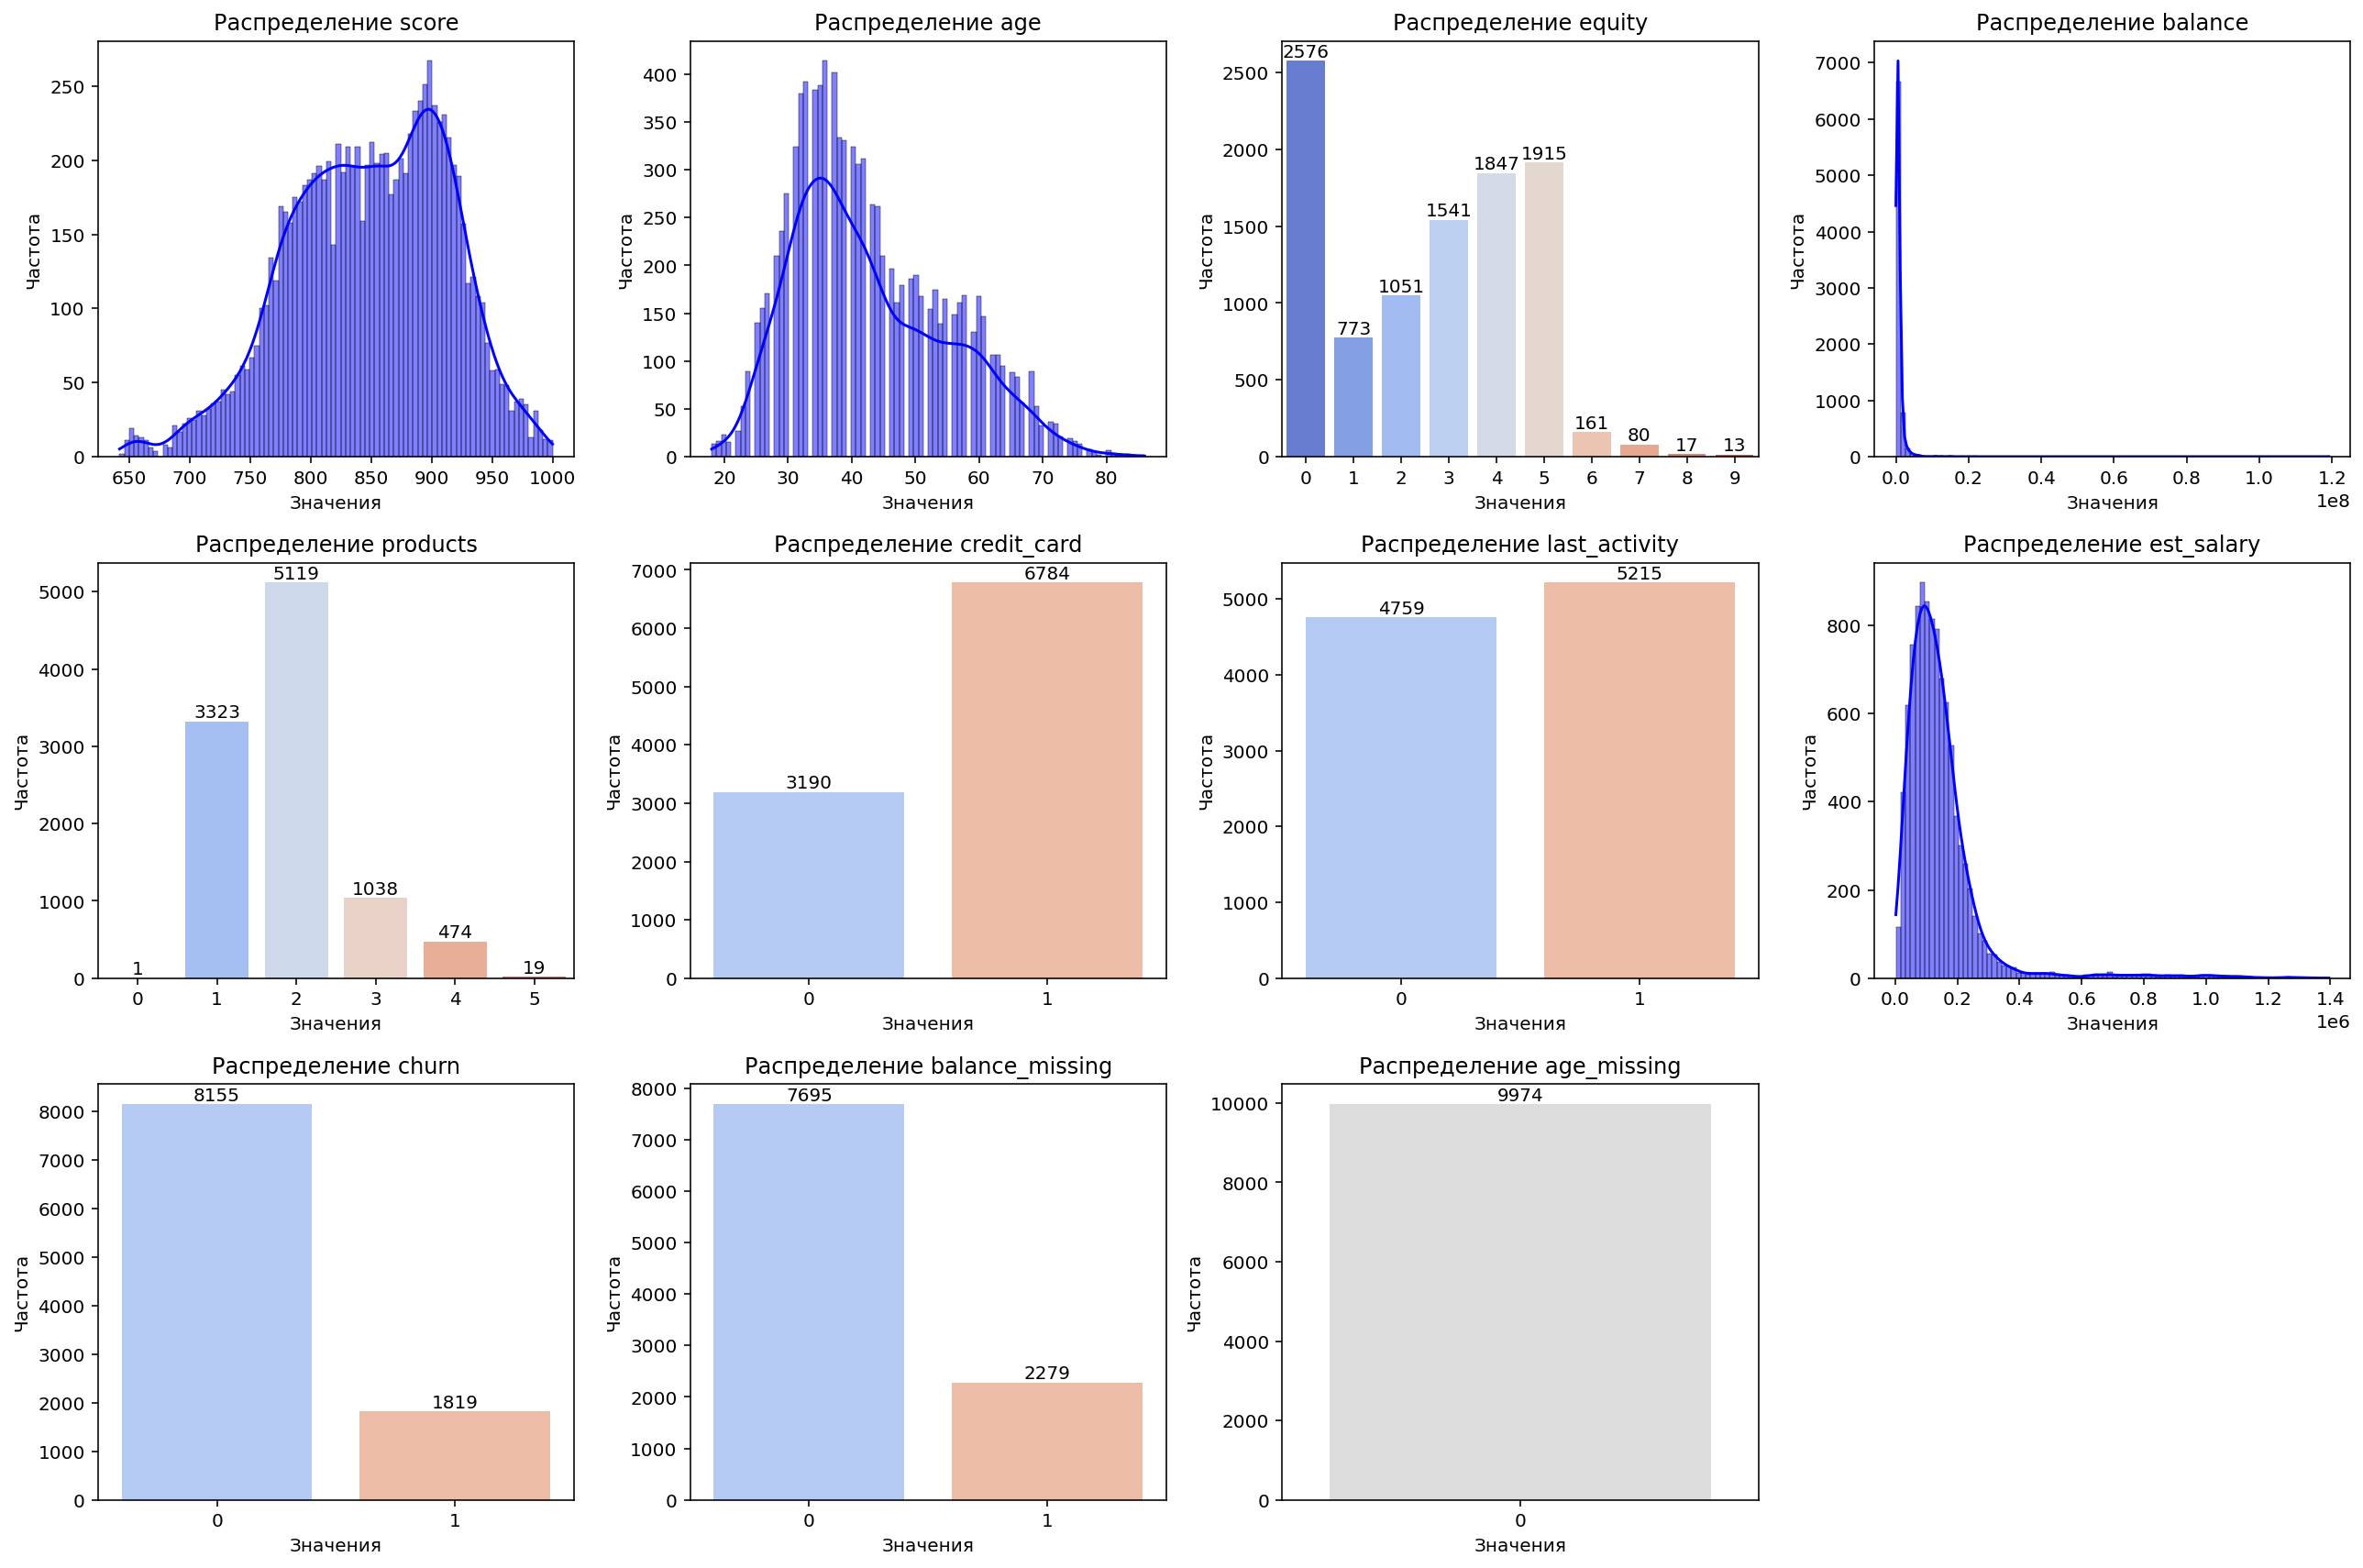

In [19]:
# Преобразуем age Int64 в int64, иначе будет ошибка
bank_clients_data['age'] = bank_clients_data['age'].astype('int64')

# Выбираем числовые признаки, исключая user_id
numeric_columns = bank_clients_data.select_dtypes(include=['float64', 'int64']).columns.drop(['user_id'])

# Определяем количество строк и столбцов для графиков
fig, axes = plt.subplots(nrows=len(numeric_columns) // 4 + 1, ncols=4, figsize=(18, 12))
axes = axes.flatten()

# Построение графиков
for i, column in enumerate(numeric_columns):
    ax = axes[i]
    
    # Если число уникальных значений мало (категориальный или дискретный признак) — строим countplot с подписями
    if bank_clients_data[column].nunique() <= 10:
        plot = sns.countplot(x=bank_clients_data[column], ax=ax, palette="coolwarm")
        
        # Добавляем подписи значений на столбцы
        for p in plot.patches:
            ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha='center', va='bottom', fontsize=10, color='black')

    else:
        # Для числовых признаков строим гистограмму
        sns.histplot(bank_clients_data[column], bins=90, kde=True, ax=ax, color='blue')

    ax.set_title(f'Распределение {column}')
    ax.set_xlabel('Значения')
    ax.set_ylabel('Частота')

# Удаляем лишние пустые графики, если осталось меньше 4 признаков
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Улучшаем отображение
plt.tight_layout()
plt.show()

На основании представленных гистограмм можно сделать следующие наблюдения:

**Возраст (`age`):**
- распределение скошено влево, с большинством значений в диапазоне 25–50 лет;
- аномалий не наблюдается, но возможны единичные выбросы в возрасте 80+ лет.

**Количество баллов собственности (`equity`):**
- значения сильно дискретные, с преобладанием клиентов в диапазоне 3–5;
- небольшая доля клиентов с `equity > 6`, что может быть особенностью данных, но не обязательно аномалией.

**Баланс (`balance`):**
- явно выраженная правосторонняя асимметрия: большинство клиентов имеют нулевые или низкие балансы;
- значительные выбросы в виде крайне высоких значений (до 120 млн+), что требует дополнительного анализа на предмет возможных аномалий.

**Количество продуктов (`products`)**
- большинство клиентов имеют 1–3 продукта, что является нормой;
- категории 4 и 5 встречаются значительно реже, но выбросов не наблюдается.

**Кредитные карты (`credit_card`)**
- данные бинарные (0 или 1), распределение ожидаемое.

 **Активность (`last_activity`)**
- также бинарный показатель, большинство клиентов либо активны, либо нет.

**Оценочная зарплата (`est_salary`)**
- очень выраженная правосторонняя асимметрия;
- возможны аномальные значения в районе 1,4 млн+, что требует дополнительной проверки.

**Отток (`churn`)**
- Бинарная переменная, большинство клиентов не ушли, что типично для таких данных.

Таким образом требуют дополнительной проверки на наличие аномалий данные в следующих столбцах:
- **balance**: крайне высокие балансы (выше 10 млн) могут быть выбросами или VIP-клиентами;
- **est_salary**: значения выше 1 млн могут быть нетипичными, стоит проверить процентильное распределение;
- **age**: возможные редкие значения выше 80 лет требуют проверки.

Дополнительный анализ данных в `balance`, `est_salary` и `age` поможет подтвердить или опровергнуть аномальности.

Для начала построим и изучим **гистограммы распределения** `balance`, `est_salary` и `age`:

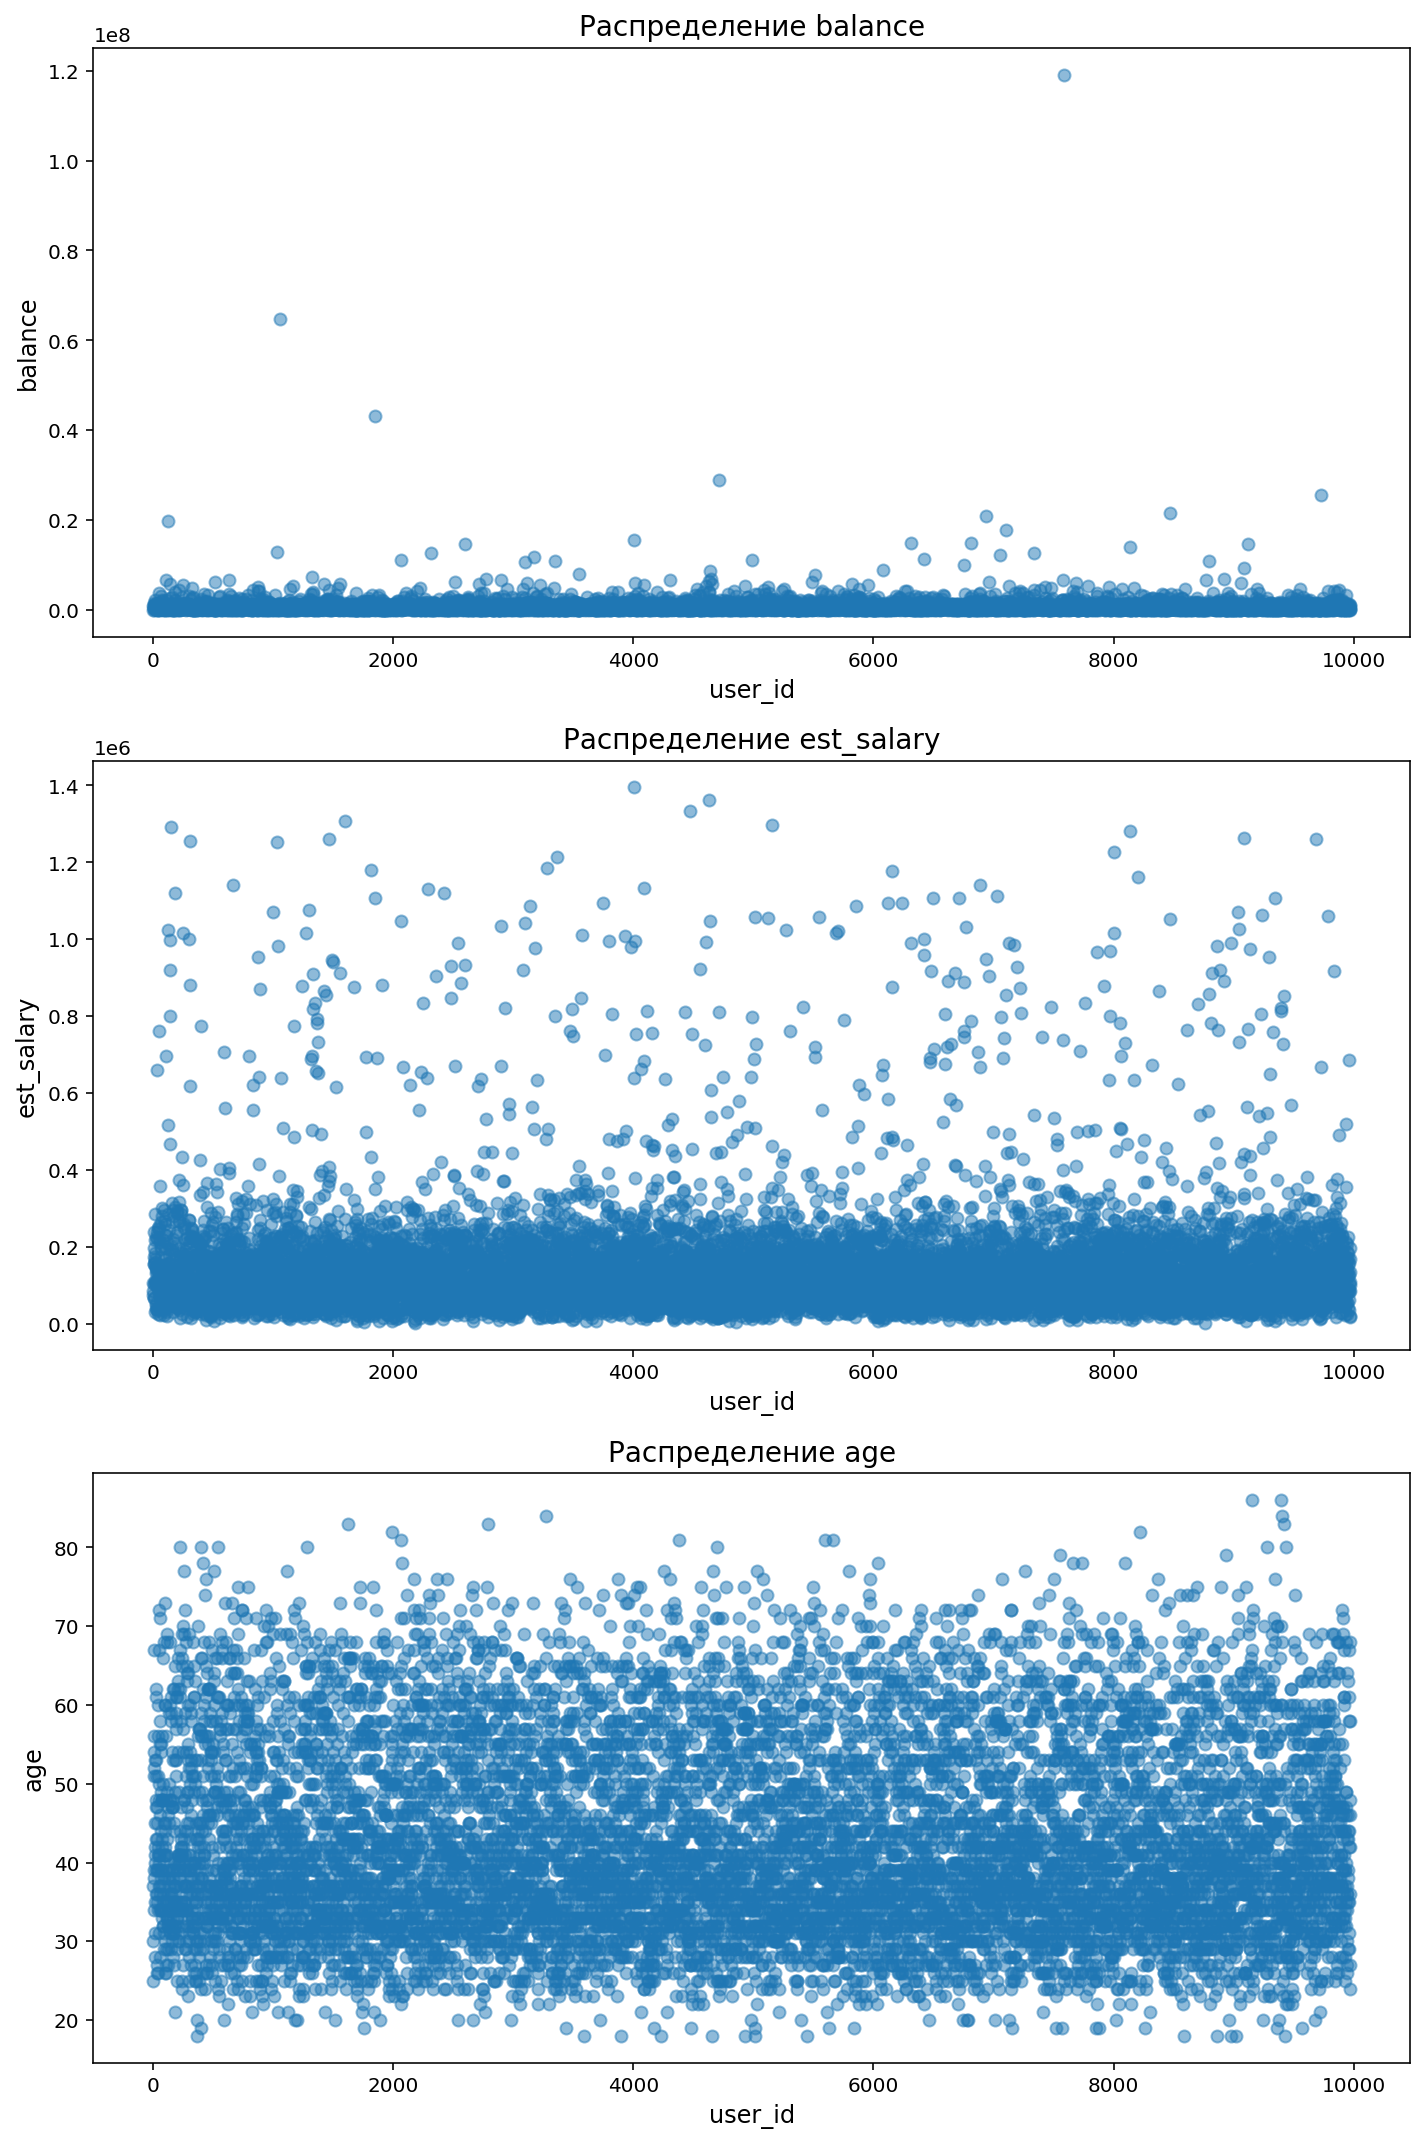

In [20]:
# Список столбцов для анализа
columns_to_plot = ['balance', 'est_salary', 'age']

# Устанавливаем размер графиков
plt.figure(figsize=(10, 15))

for i, column in enumerate(columns_to_plot, 1):
    plt.subplot(3, 1, i)  # Создание подграфика
    x_values = pd.Series(range(len(bank_clients_data[column])))
    plt.scatter(x_values, bank_clients_data[column], alpha=0.5)
    
    # Добавляем заголовок и подписи осей
    plt.title(f'Распределение {column}', fontsize=14)
    plt.xlabel('user_id', fontsize=12)
    plt.ylabel(column, fontsize=12)

# Улучшаем отображение графиков
plt.tight_layout()
plt.show()

По представленным графикам можно сделать следующие выводы о наличии выбросов:

В **`balance` (баланс)** наблюдаются значительные выбросы. Есть отдельные клиенты с экстремально высокими балансами, вплоть до **120 млн**. Основная масса клиентов сосредоточена в низком диапазоне значений, что указывает на сильную асимметрию в распределении.  Возможно, эти аномально высокие балансы связаны с VIP-клиентами или ошибками в данных.

В **`еst_salary` (оценочная зарплата)** также есть значительные выбросы, достигающие **1.4 млн**. Большинство значений сосредоточено в диапазоне **до 300 тыс.**.  Клиенты с очень высокой зарплатой могут относиться к особой категории пользователей.

В **`аge` (возраст)** выбросов практически нет. Возраст распределен равномерно в пределах **от 18 до 86 лет**.  Распределение похоже на нормальное, с большим числом клиентов в среднем возрасте.  
  
Итог:
- в **balance** и **est_salary** явно присутствуют выбросы/аномально высокие значения, которые требуют дополнительного анализа (например, расчет 99-го процентиля).
- **аge** не содержит явных аномалий.

---

Далее для `balance` и `est_salary` рассчитаем **99-й перцентиль** и определим, какие значения этих показателей соответствуют 1% клиентов с самыми высокими значениями, превышающими 99% остальных.

In [21]:
# Функция для определения выбросов по 99-му процентилю
def detect_outliers_percentile(data, column):
    upper_bound = np.percentile(data[column].dropna(), 99)
    outliers = data[data[column] > upper_bound]
    return outliers, upper_bound

# Анализ выбросов в balance
balance_outliers_percentile, balance_percentile_99 = detect_outliers_percentile(bank_clients_data, 'balance')

# Анализ выбросов в est_salary
salary_outliers_percentile, salary_percentile_99 = detect_outliers_percentile(bank_clients_data, 'est_salary')

# Вывод результатов
print(f"Граница выбросов в balance (99-й перцентиль): {balance_percentile_99}")
print(f"Количество выбросов в balance (99-й перцентиль): {len(balance_outliers_percentile)}")


print(f"Граница выбросов в est_salary (99-й перцентиль): {salary_percentile_99}")
print(f"Количество выбросов в est_salary (99-й перцентиль): {len(salary_outliers_percentile)}")

Граница выбросов в balance (99-й перцентиль): 4827211.159
Количество выбросов в balance (99-й перцентиль): 77
Граница выбросов в est_salary (99-й перцентиль): 886322.5299000009
Количество выбросов в est_salary (99-й перцентиль): 100


Видим, что в `balance` (баланс) граница выбросов по `99-му процентилю`: 2 114 078 руб. Это означает, что 99% клиентов имеют баланс ниже этой суммы, а лишь 1% имеют баланс выше. Количество таких клиентов: 77, т.е. только 77 клиентов из 10 000 имеют баланс, превышающий 2.11 млн.

В `est_salary` (оценочная зарплата) граница выбросов по `99-му процентилю`: 316 360 руб. Это означает, что 99% клиентов имеют зарплату ниже 316 тыс., а 1% – выше. Количество таких клиентов: 100, т.е. только 100 клиентов из 10 000 имеют зарплату выше 316 тыс.


**Проанализируем выбросы выше 99-го процентиля** отдельно: изучим этих клиентов, чтобы понять, чем они отличаются и что у них общего. Выведем информацию по таким аномальным клиентам.

In [22]:
# Определяем пороговые значения для 99-го перцентиля
balance_threshold = bank_clients_data['balance'].quantile(0.99)
salary_threshold = bank_clients_data['est_salary'].quantile(0.99)

# Фильтруем клиентов, у которых значения balance или est_salary выше 99-го перцентиля
outliers = bank_clients_data[(bank_clients_data['balance'] > balance_threshold) | 
                             (bank_clients_data['est_salary'] > salary_threshold)]

# Выводим отфильтрованные данные
outliers.head(60)

,user_id,score,age,equity,balance,products,credit_card,last_activity,est_salary,churn,balance_missing,age_missing,city_original,gender_original,city_Ростов,city_Рыбинск,city_Ярославль,gender_Ж,gender_М
107,134358,985,41,4,6749773.07,2,1,0,698013.27,0,0,0,Рыбинск,Ж,0,1,0,1,0
125,227092,1000,32,5,19757180.85,2,1,1,1024626.50,0,0,0,Ярославль,М,0,0,1,0,1
137,163907,761,31,0,NaN,1,1,0,999177.17,0,1,0,Ярославль,М,0,0,1,0,1
143,198181,958,34,3,5763239.76,2,1,1,920730.06,1,0,0,Ярославль,М,0,0,1,0,1
149,218801,958,34,0,NaN,1,1,0,1292825.74,0,1,0,Ярославль,М,0,0,1,0,1
178,226887,890,49,4,3956103.10,2,1,0,1120528.70,0,0,0,Ярославль,М,0,0,1,0,1
248,180899,930,32,4,5527695.02,3,0,1,360963.15,0,0,0,Ярославль,М,0,0,1,0,1
250,210357,766,27,0,NaN,1,1,0,1015754.12,0,1,0,Ярославль,М,0,0,1,0,1
296,204143,925,25,0,NaN,2,1,0,1001009.40,0,1,0,Ярославль,М,0,0,1,0,1
302,164876,942,40,0,NaN,1,1,0,1256537.74,0,1,0,Ярославль,М,0,0,1,0,1


В целом, клиенты с высоким балансом чаще всего имеют и высокий оценочный доход. Однако наблюдаются исключения, когда значительный баланс сочетается с относительно низким доходом (20–80 тыс.). Эти случаи редки, но могут свидетельствовать о специфической категории клиентов – например, владельцах крупных активов, использующих инвестиционные инструменты или имеющих нетипичные источники дохода.  

Дополнительно можно отметить, что среди клиентов с высокими балансами практически отсутствуют пользователи с 1 банковским продуктом, что подтверждает гипотезу о том, что значительные средства на счетах чаще фиксируются у более активных пользователей банковских услуг.  

Таким образом, можно сделать вывод, что удаление таких клиентов из анализа может привести к потере важной информации о VIP-сегменте, поэтому принято решение оставить практически все данные без изменений (при необходимости 99-й перцентиль можно использовать в качестве верхнего предела, чтобы снизить влияние выбросов в расчетах), за исключением клиентов с балансом выше 25 млн. руб.
Очень они выделяются из общей картины.

Удалим аномальных клиентов с балансом выше 25 млн. руб., предварительно создав копию текущего датасета, чтобы потом проверить количество удаленных строк.

Размер данных до удаления: (9974, 19)
Размер данных после удаления: (9969, 19)


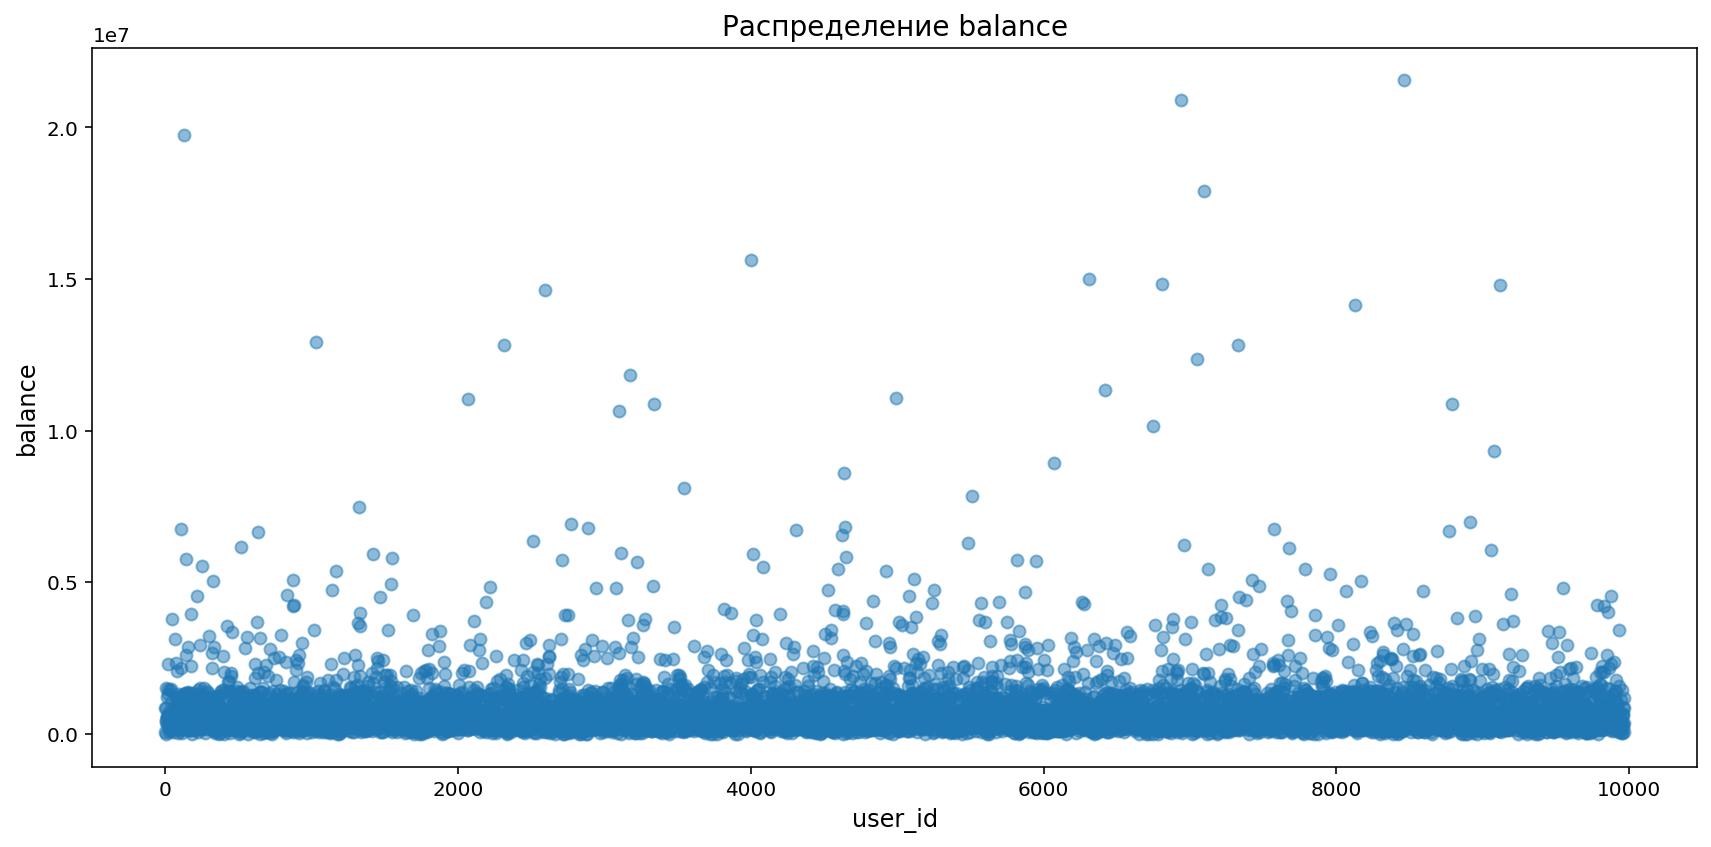

In [23]:
# Создаем копию оригинального датасета
bank_clients_data_copy = bank_clients_data.copy()

#Устанавливаем лимитбаланса, выше которого данные будут считаться аномальными и удалены
threshold = 25000000

# Фильтруем так, чтобы удалялись только те строки, где balance > 25 млн, а NaN оставались
bank_clients_data = bank_clients_data[(bank_clients_data['balance'] <= threshold) | (bank_clients_data['balance'].isna())]

print(f"Размер данных до удаления: {bank_clients_data_copy.shape}")
print(f"Размер данных после удаления: {bank_clients_data.shape}")

# Строим диарамму рассеяния для проверки
# Создание графика
plt.figure(figsize=(12, 6))

# Создание значений для оси X
x_values = pd.Series(range(len(bank_clients_data['balance'])))

# Построение графика
plt.scatter(x_values, bank_clients_data['balance'], alpha=0.5)

# Добавление заголовка и подписей осей
plt.title('Распределение balance', fontsize=14)
plt.xlabel('user_id', fontsize=12)
plt.ylabel('balance', fontsize=12)

# Улучшение отображения
plt.tight_layout()
plt.show()


Видим, что пять клиентов с аномально высокими балансами удалены из датасета. Остальные данные остались. Переходим непосредственно к исследовательскому анализу данных.

### Анализ распределения признаков в зависимости от оттока. Непрерывные признаки

**Для непрерывных признаков необходимо определить интервалы значений, связанных с повышенной долей оттока**. 

Начнем с **выбора числовых признаков**. Возьмем для анализа следующие столбцы: `age`, `balance`, `est_salary`, `score`. 

Затем **построим нормированные гистограммы распределения и boxplot** относительно средних значений для определенения отточных интервалов.

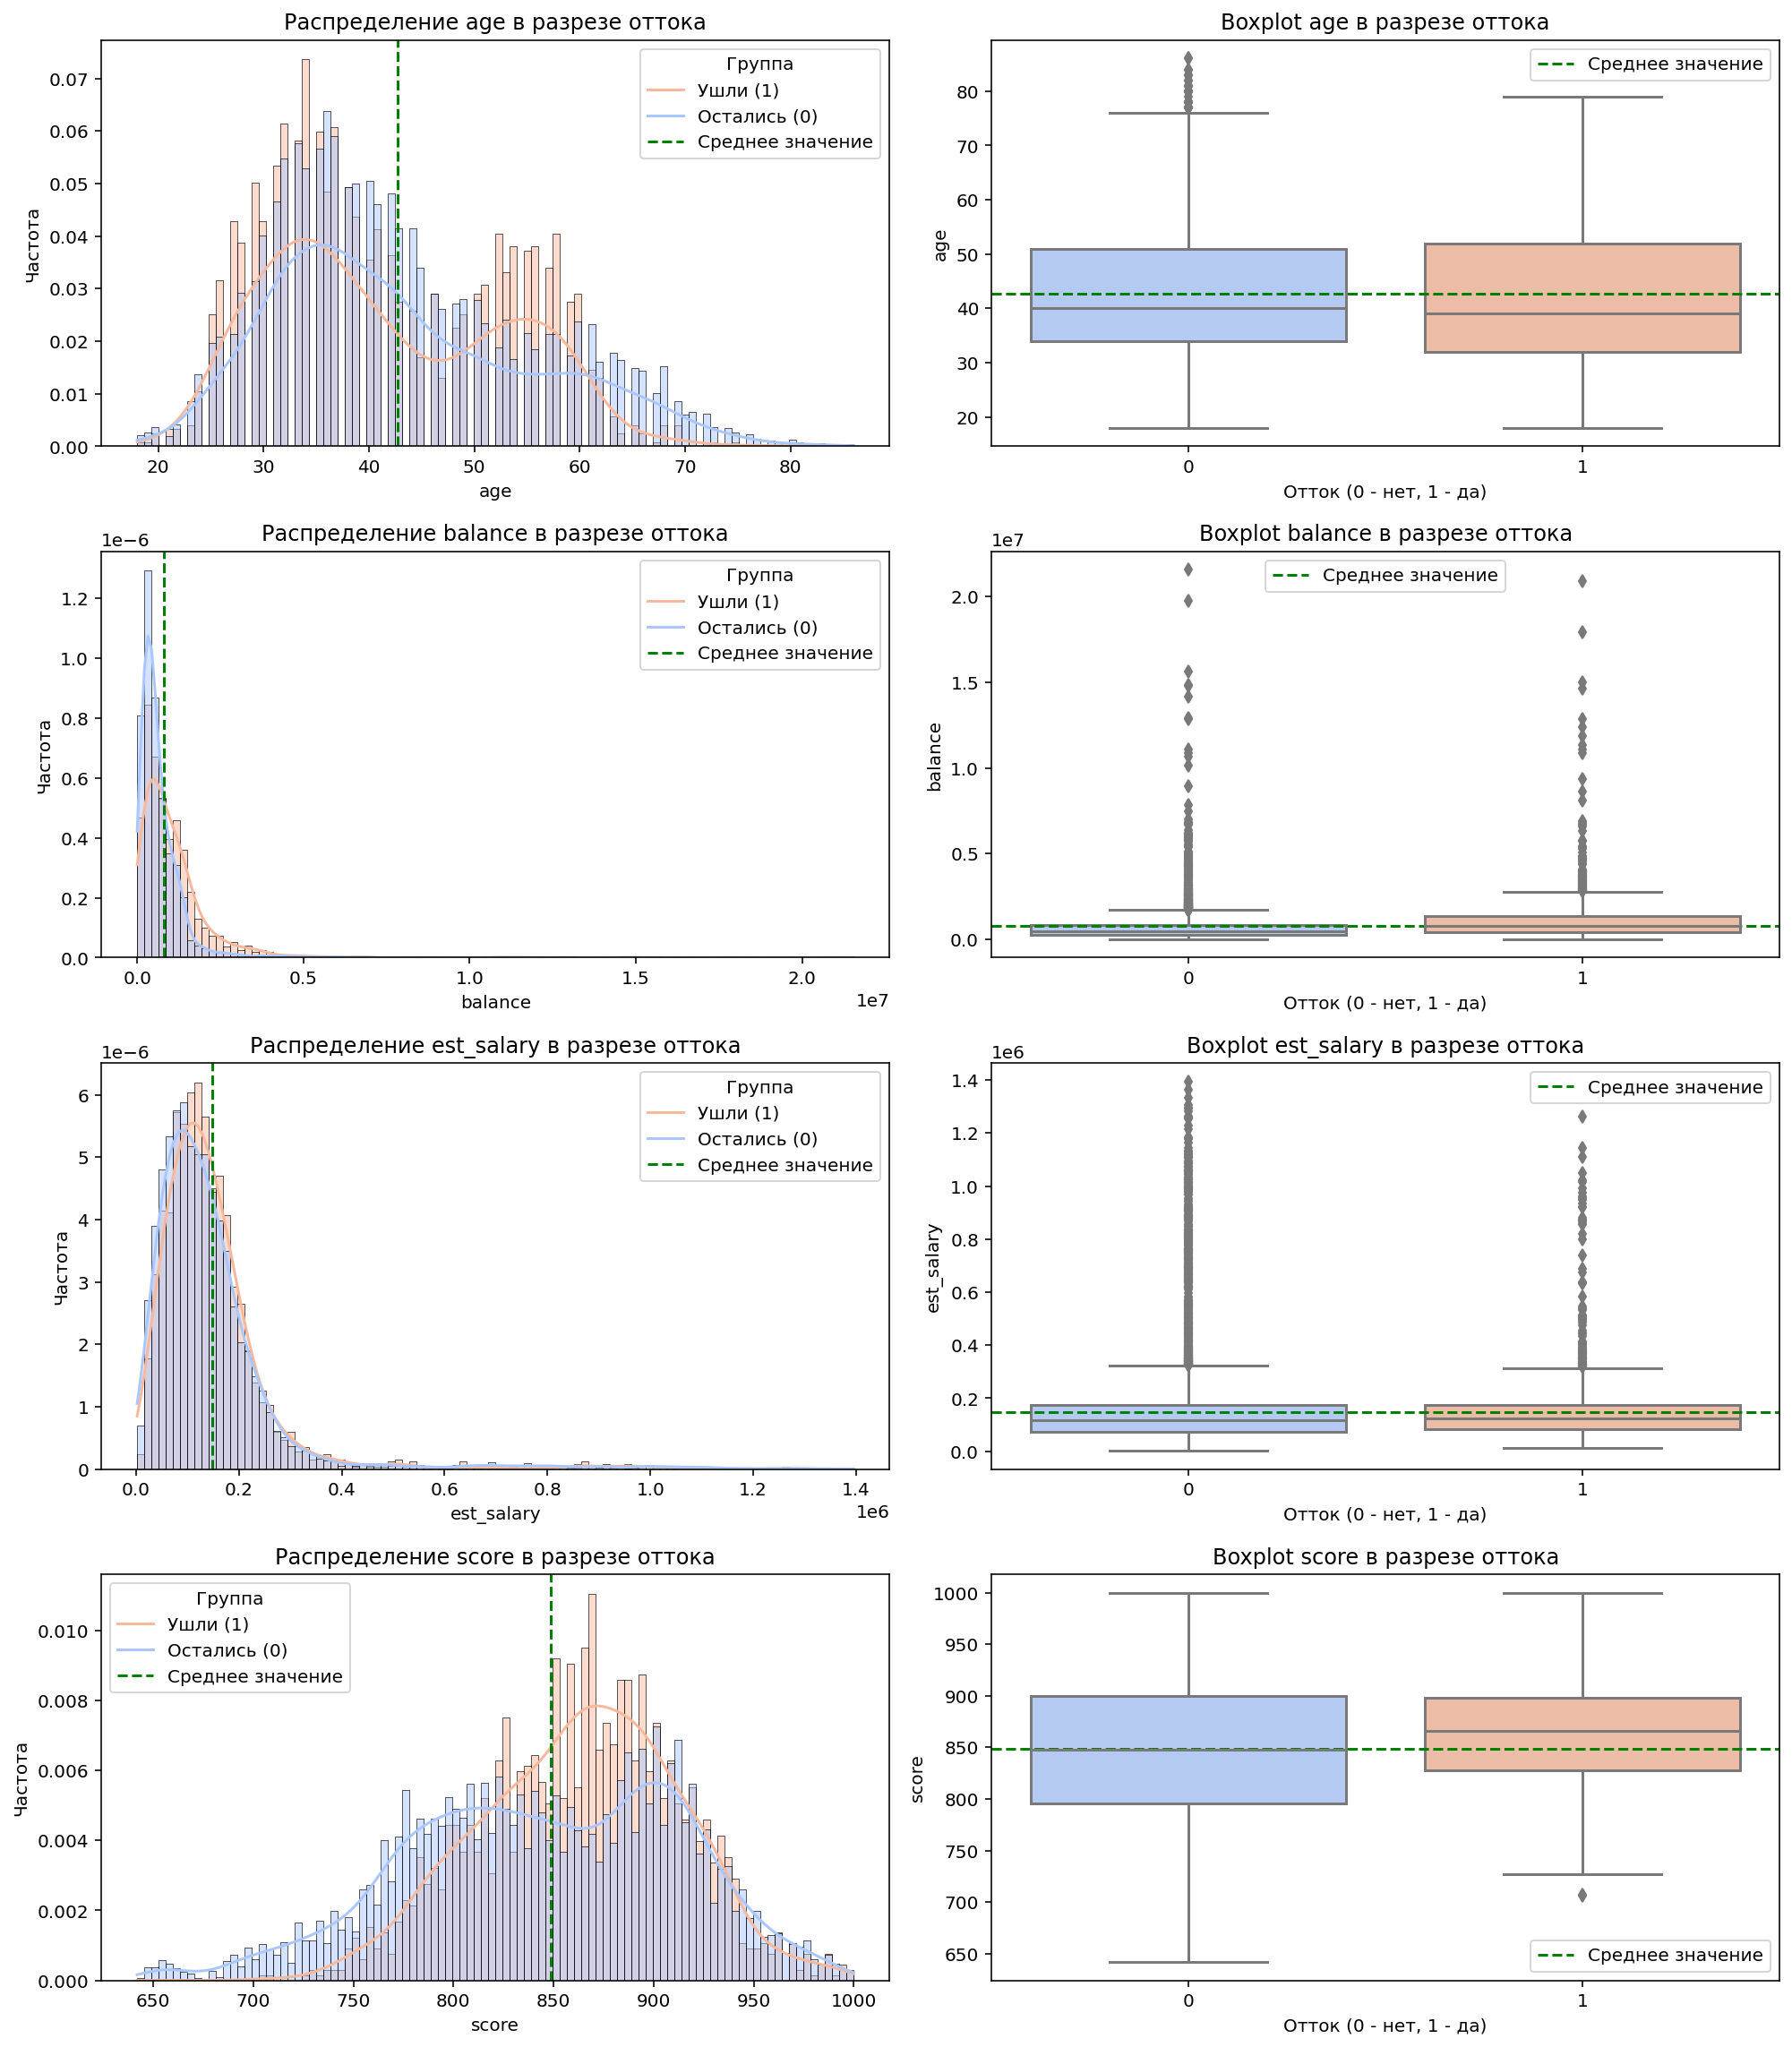

In [24]:
# Преобразуем age в стандартный int (до этого был Int64)
bank_clients_data['age'] = bank_clients_data['age'].astype('int64')

# Выбираем числовые признаки
numeric_columns = ['age', 'balance', 'est_salary', 'score']

# Устанавливаем размер общей фигуры
fig, axes = plt.subplots(len(numeric_columns), 2, figsize=(14, 4 * len(numeric_columns)))

# Перебираем признаки и строим графики
for i, column in enumerate(numeric_columns):
    
    # Гистограмма распределения (слева)
    sns.histplot(data=bank_clients_data, x=column, hue='churn',  bins=100,
                 kde=True, stat="density", common_norm=False, palette='coolwarm', ax=axes[i, 0])
    axes[i, 0].axvline(bank_clients_data[column].mean(), color='green', linestyle='--', label='Среднее значение')
    axes[i, 0].set_title(f'Распределение {column} в разрезе оттока')
    axes[i, 0].set_xlabel(column)
    axes[i, 0].set_ylabel('Частота')
    axes[i, 0].legend(title="Группа", labels=["Ушли (1)", "Остались (0)", "Среднее значение"])
    
    # Boxplot (справа)
    sns.boxplot(x=bank_clients_data['churn'], y=bank_clients_data[column], palette='coolwarm', ax=axes[i, 1])
    mean_value = bank_clients_data[column].mean()
    axes[i, 1].axhline(mean_value, color='green', linestyle='--', label='Среднее значение')
    axes[i, 1].set_title(f'Boxplot {column} в разрезе оттока')
    axes[i, 1].set_xlabel('Отток (0 - нет, 1 - да)')
    axes[i, 1].set_ylabel(column)
    axes[i, 1].legend()

# Улучшаем отображение графиков
plt.tight_layout()
plt.show()

Данные по `balance` и `est_salary` на визуализациях считываются с трудом из-за наличия аномально высоких значений, которые было решено сохранить. Поэтому, для удобства анализа, дополнительно построим столбчатые диаграммы с ограничением значений на уровне 99-го процентиля. Это позволит лучше рассмотреть распределение признаков и упростить оценку их влияния на отток.

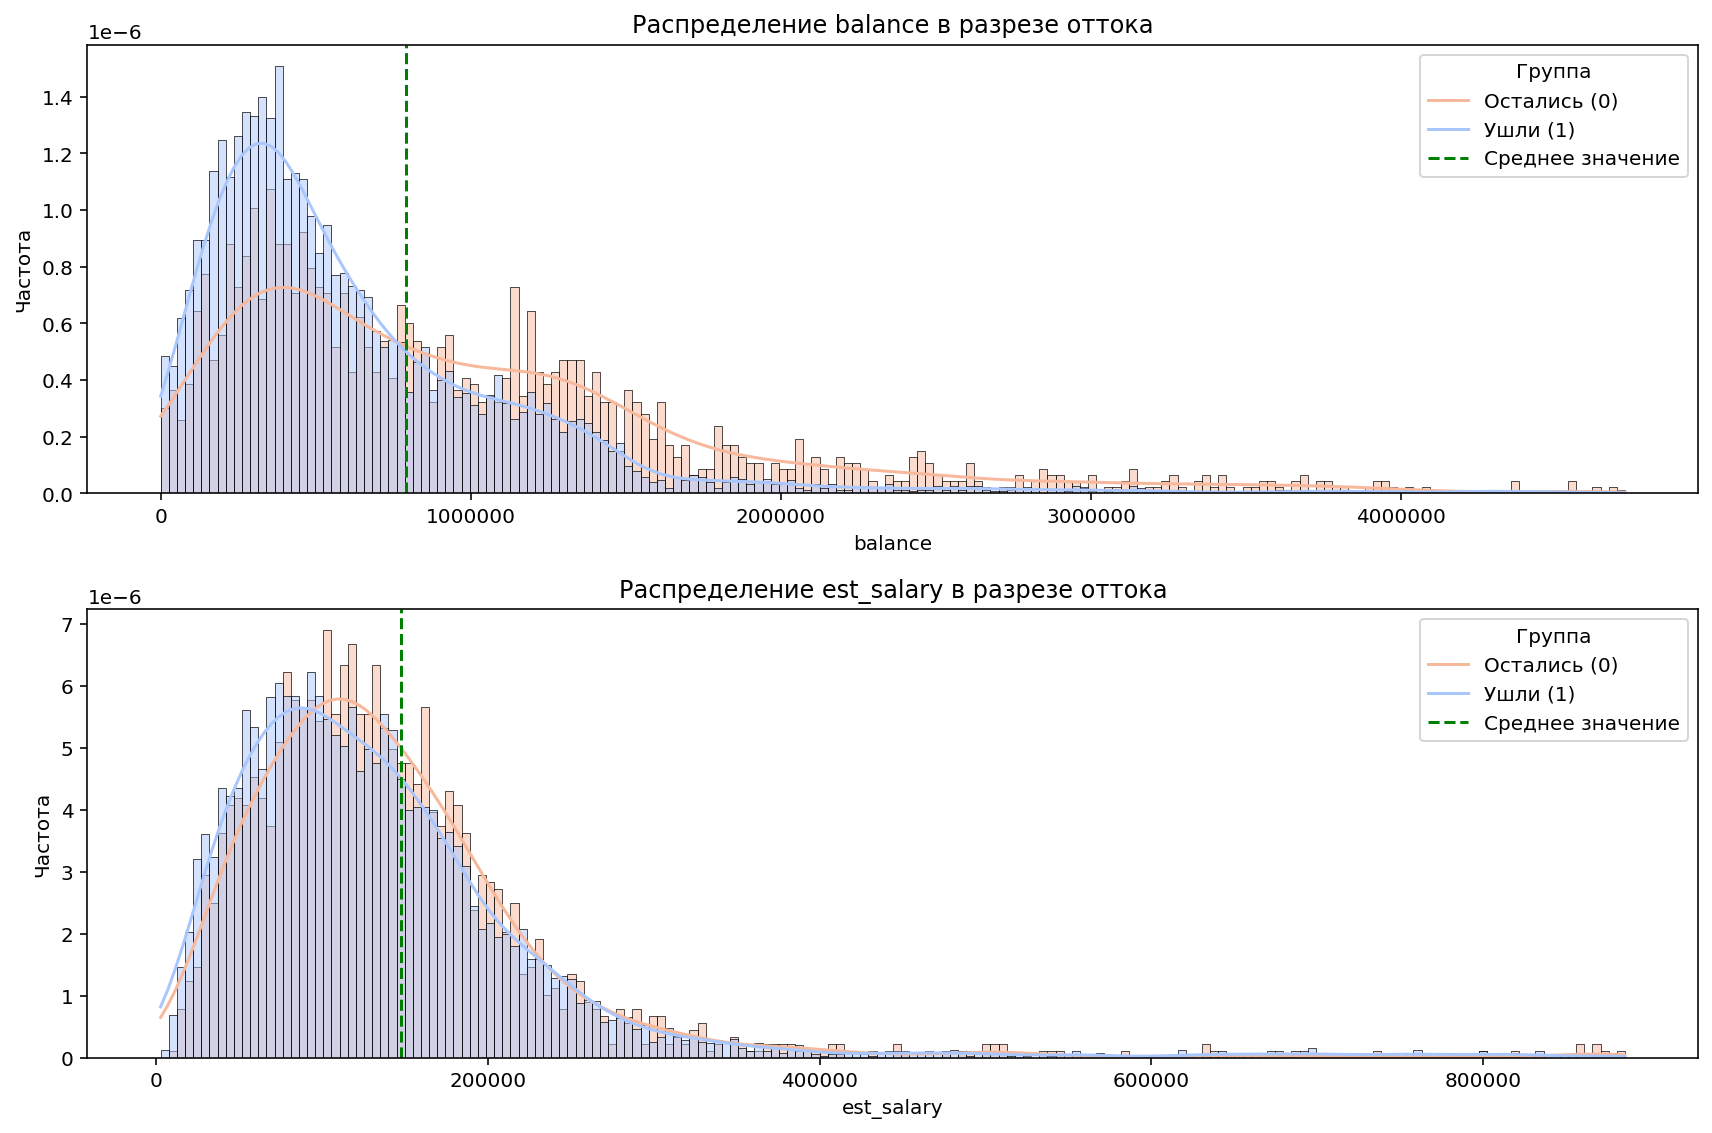

In [25]:
# Вычисляем 99-й процентиль для balance и est_salary
balance_99 = bank_clients_data['balance'].quantile(0.99)
est_salary_99 = bank_clients_data['est_salary'].quantile(0.99)

# Устанавливаем размер графиков
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Гистограмма для balance
sns.histplot(data=bank_clients_data[bank_clients_data['balance'] <= balance_99], 
             x='balance', hue='churn', kde=True, stat="density", common_norm=False, 
             palette='coolwarm', bins=180, ax=axes[0])  # Увеличиваем количество корзин
axes[0].axvline(bank_clients_data['balance'].mean(), color='green', linestyle='--', label='Среднее значение')
axes[0].set_title('Распределение balance в разрезе оттока')
axes[0].set_xlabel('balance')
axes[0].set_ylabel('Частота')
axes[0].legend(title="Группа", labels=["Остались (0)", "Ушли (1)", "Среднее значение"])
axes[0].ticklabel_format(style='plain', axis='x')  

# Гистограмма для est_salary
sns.histplot(data=bank_clients_data[bank_clients_data['est_salary'] <= est_salary_99], 
             x='est_salary', hue='churn', kde=True, stat="density", common_norm=False, 
             palette='coolwarm', bins=180, ax=axes[1])  # Увеличиваем количество корзин
axes[1].axvline(bank_clients_data['est_salary'].mean(), color='green', linestyle='--', label='Среднее значение')
axes[1].set_title('Распределение est_salary в разрезе оттока')
axes[1].set_xlabel('est_salary')
axes[1].set_ylabel('Частота')
axes[1].legend(title="Группа", labels=["Остались (0)", "Ушли (1)", "Среднее значение"])
axes[1].ticklabel_format(style='plain', axis='x')

plt.tight_layout()
plt.show()

Теперь все отлично видно, перейдем к определению интервалов значений, связанных с повышенной долей оттока.

Анализ распределения ключевых числовых признаков в разрезе оттока позволил выявить закономерности и определить группы клиентов, наиболее склонных к уходу.  

**1. Возраст (`age`):**
- основные пики оттока наблюдаются в двух возрастных группах:  
    - клиенты **30–40 лет** могут менять банк из-за смены жизненных приоритетов (например, ипотека, семья);
    - клиенты **50–60 лет** могут покидать банк из-за выхода на пенсию и изменения потребности в финансовых услугах;
    - средний возраст клиентов, склонных к оттоку, немного выше, чем у оставшихся.

**2. Баланс (`balance`):**
- **клиенты с нулевым балансом или минимальными остатками (0–50 000) показывают высокий уровень оттока**. Это может быть связано с неактивным использованием банковских услуг; 
- в диапазоне **100 000 – 500 000** также наблюдается повышенный отток;  
- клиенты с высоким балансом (>1 млн) остаются более лояльными.  

**3. Оценочная зарплата (`est_salary`)**
- **клиенты с низким доходом (в диапазоне `80 000 - 120 000`) больше всего склонны к оттоку**, вероятно, из-за финансовой нестабильности;  
- клиенты с **очень высоким доходом (`>800 000`) также показывают склонность к уходу**, что может быть связано с переходом в премиальный банковский сегмент.  

**4. Скоринговый балл (`score`)**
- клиенты **с оценкой 800–900** имеют наибольшую склонность к оттоку;
- после 900 уровень оттока снижается.

Теперь, на основании проведенного анализа, можно определить **критериии условия для выделения групп пользователей на основе схожих характеристик, которые впоследствии будут использоваться для сегментации**.

**Выделенные группы клиентов с повышенной склонностью к оттоку**  
1. **Возраст**: 30–40 лет и 50–60 лет.  
2. **Баланс**: 0–50 000 и 100 000-500 000.  
3. **Доход**: 80 000-20 000 и >800 000.  
4. **Скоринговый балл**: 800-900.  

Переходим к категориальным и дискретным признакам.

### Анализ распределения признаков в зависимости от оттока. Категориальные и дискретные признаки

На этом этапе выполним следующие действия:
- выберем категориальные и дискретные признаки;
- построим barplot() для каждого;
- определим, какие группы выходят за средний уровень оттока;
- дополним группы клиентов, которые демонстрируют повышенную вероятность ухода из банка, на основе новых критериев.

Начнем с выбора **категориальных и дискретных признаков**. Это будут: `city_original`, `gender_original`, `products`, `equity`, `credit_card`, `last_activity`.

In [26]:
# Определяем категориальные и дискретные признаки
categorical_features = ['city_original', 'gender_original', 'products', 'equity', 'credit_card', 'last_activity']

Далее вычислим **средний уровень оттока по банку** и **построим barplot()** для каждого признака из `categorical_features`.

Поскольку значение `0` в признаке `products` может указывать на клиентов, которые либо уже ушли из банка, либо просто зарегистрировались, но не пользуются его услугами, исключим их из анализа.

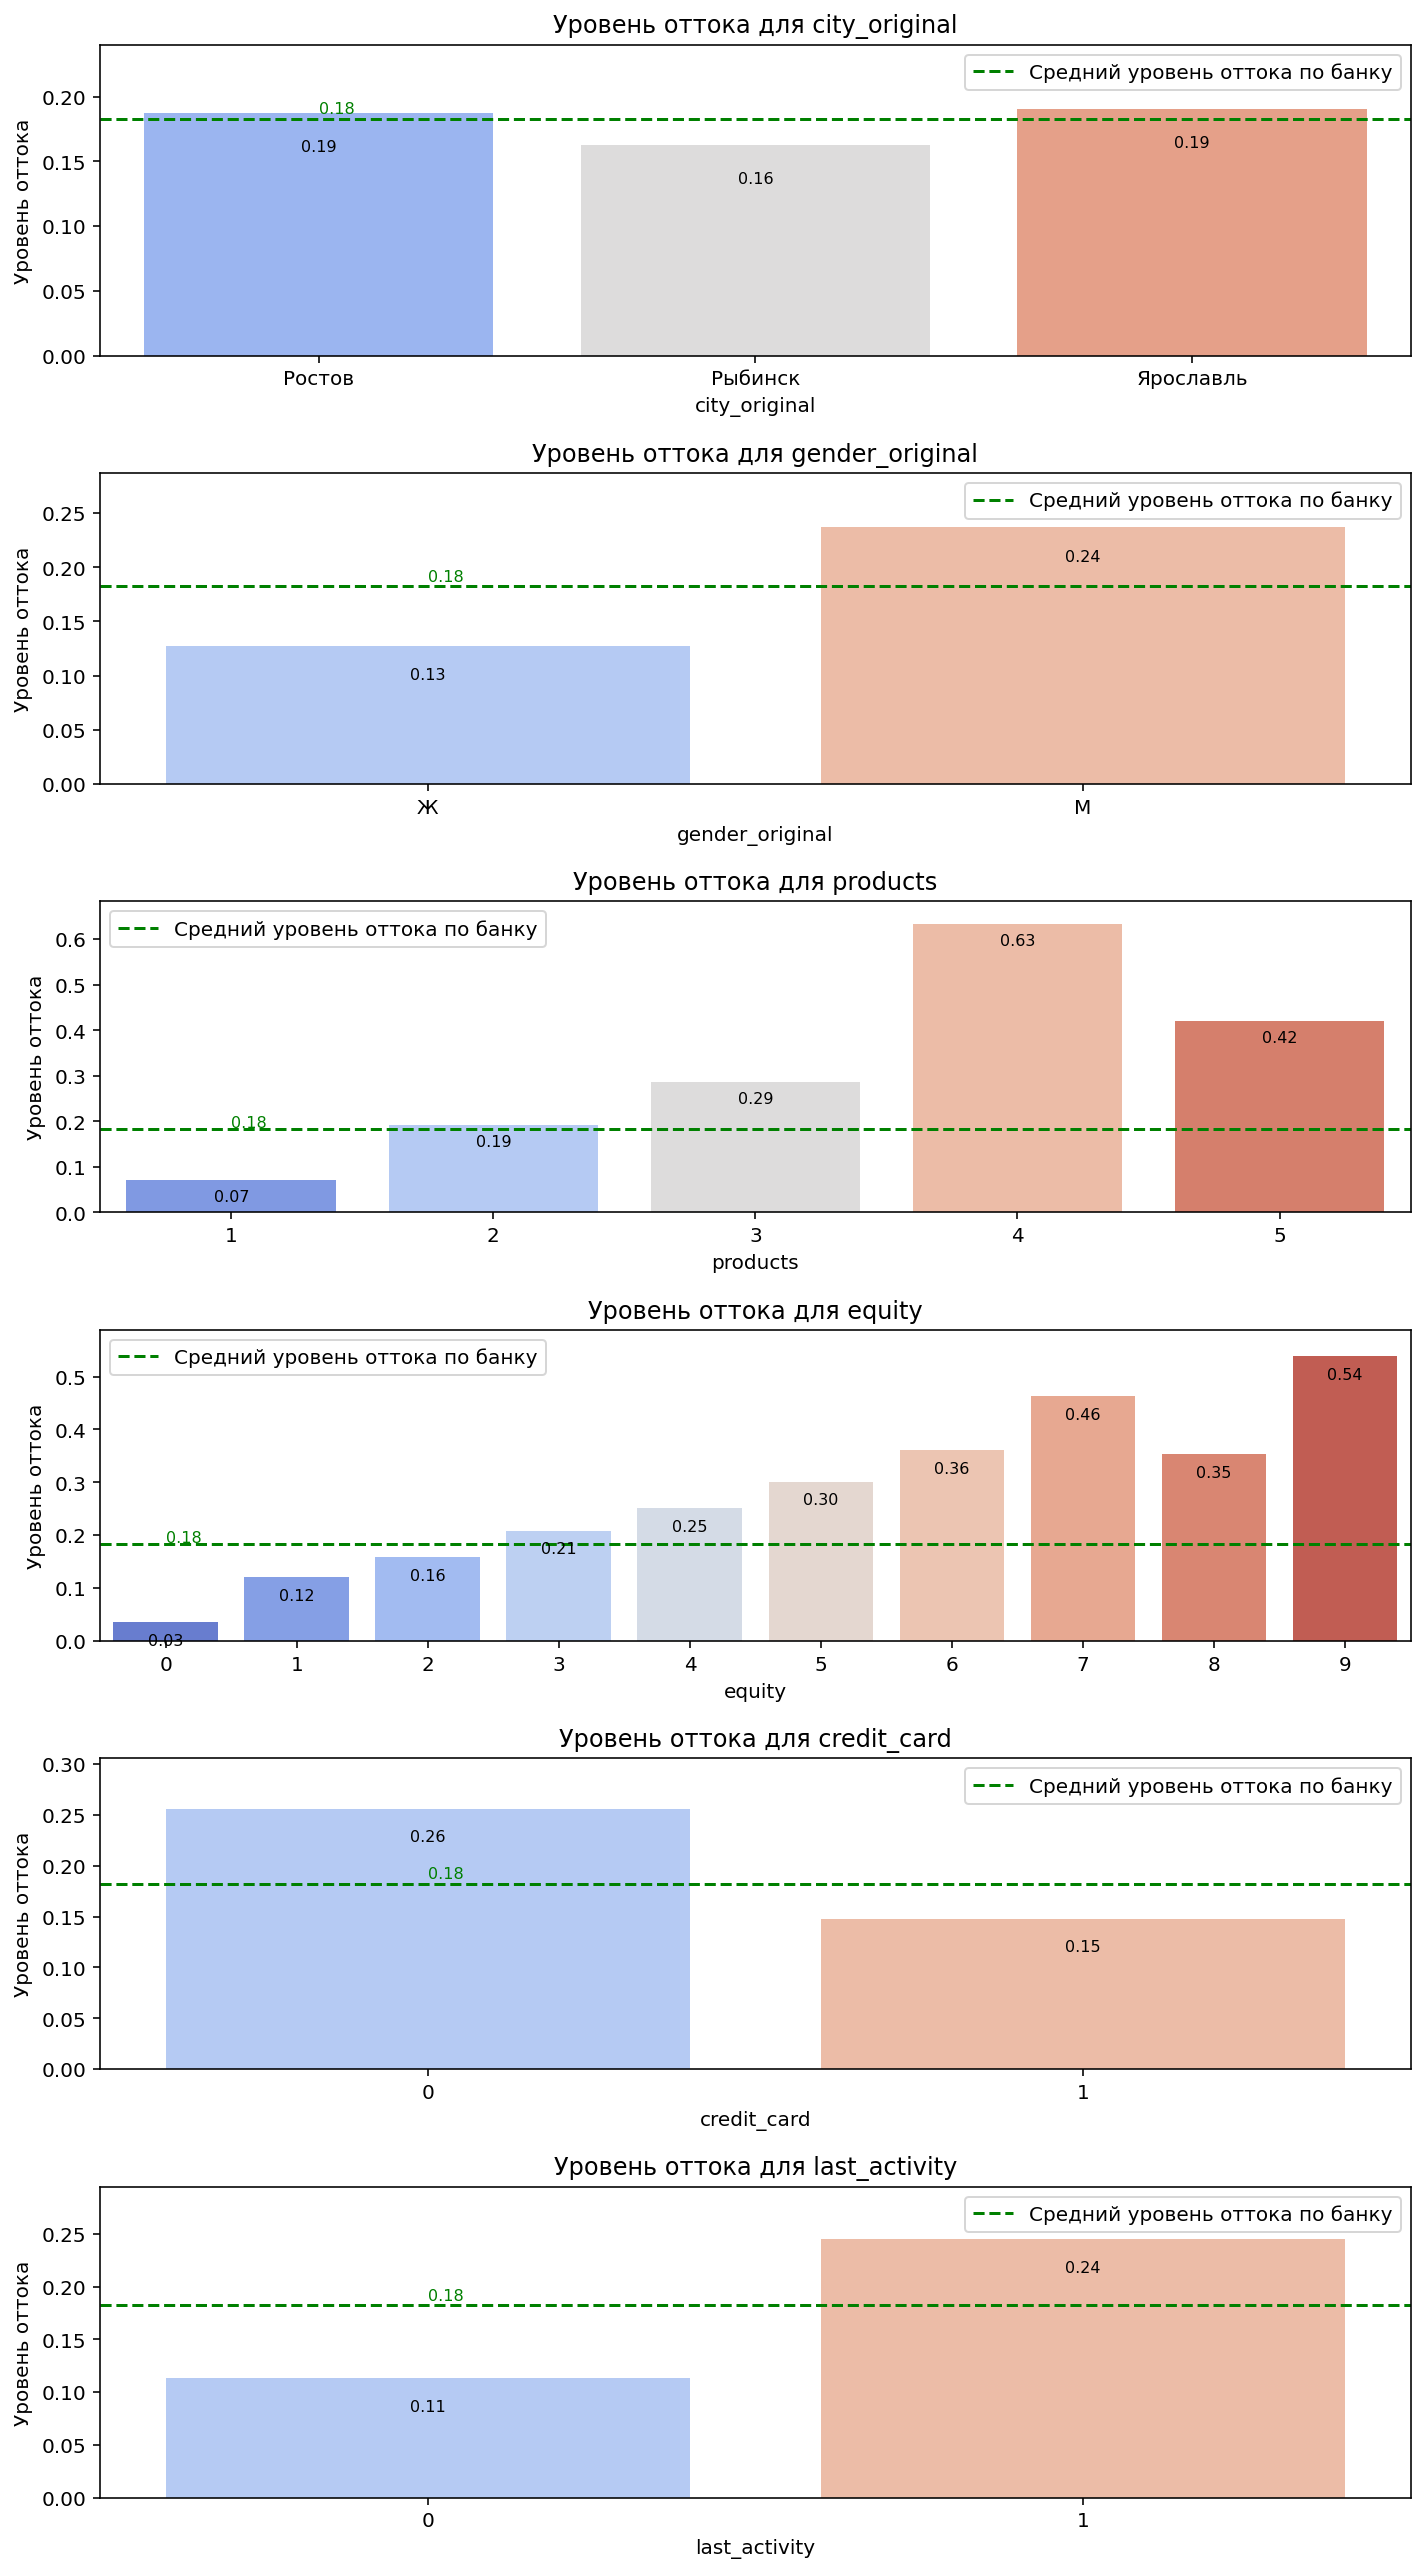

In [27]:
# Вычисляем средний уровень оттока по банку 
mean_churn_rate = bank_clients_data['churn'].mean()

# Исключаем клиентов с products == 0
filtered_data = bank_clients_data[bank_clients_data['products'] > 0]

# Устанавливаем размер фигуры
fig, axes = plt.subplots(len(categorical_features), 1, figsize=(10, 3 * len(categorical_features)))

# Перебираем признаки и строим графики
for i, feature in enumerate(categorical_features):
    # Вычисляем средний уровень оттока для каждого значения признака
    churn_rates = filtered_data.groupby(feature)['churn'].mean().reset_index()
    
    # Barplot для визуализации оттока
    sns.barplot(x=feature, y='churn', data=churn_rates, palette='coolwarm', ax=axes[i])
    
    # Добавляем линию среднего уровня оттока
    axes[i].axhline(mean_churn_rate, color='green', linestyle='--', label='Средний уровень оттока по банку')
    
    # Устанавливаем пределы оси Y, чтобы подписи не выходили за пределы
    axes[i].set_ylim(0, churn_rates['churn'].max() + 0.05)

    # Добавляем подписи значений на столбцы (позиция внутри столбца)
    for index, row in churn_rates.iterrows():
        axes[i].text(index, row['churn'] - 0.02, f"{row['churn']:.2f}", 
                     ha='center', va='top', fontsize=8, color='black')

    # Подписываем среднее значение оттока
    axes[i].text(0, mean_churn_rate + 0.005, f"{mean_churn_rate:.2f}", 
                 color='green', ha='left', fontsize=8)

    # Настройки графика
    axes[i].set_title(f'Уровень оттока для {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Уровень оттока')
    axes[i].legend()

plt.tight_layout()
plt.show()


 Выводы по категориальным и дискретным признакам:

1. **Город (`city_original`):**
   - самый высокий уровень оттока наблюдается в **Ярославле** и **Ростове** (19%), что превышает средний уровень оттока по банку;
   - в **Рыбинске** уровень оттока ниже, но все же остается значительным - всего на 2% ниже среднего уровня оттока по банку (16%).

2. **Пол (`gender_original`):**
   - **мужчины** демонстрируют **повышенный уровень оттока (24%)**, тогда как у женщин этот показатель **ниже среднего (13%)**.

3. **Количество продуктов (`products`):**
   - **высокий уровень оттока у клиентов с 4 (63%) и 5 (42%) продуктами**, что может свидетельствовать о смене банка в поисках лучших условий;
   - **клиенты с 3 продуктами также демонстрируют повышенный риск оттока (29%), превышающий средний уровень оттока по банку**;
   - **оптимальное количество продуктов для удержания клиента – 1 и 2 продукта (7% и 19%)**, хотя стоить обратить внимание на клиентов с 2-мя продуктами, средний уровень оттока по этой категории клиентов на 1 % выше среднего уровня оттока по банку.

4. **Количество активов (`equity`):**
   - **клиенты с 0 активами имеют самый низкий уровень оттока (3%)**, что может означать, что они менее активны в использовании банковских услуг;
   - **риск оттока увеличивается от 3 активов и выше**. Особенно высокий отток у клиентов с **6-9 активами (до 54%)**, что может говорить о более мобильных клиентах, выбирающих альтернативные финансовые решения.

5. **Наличие кредитной карты (`credit_card`):**
   - **клиенты без кредитной карты имеют более высокий уровень оттока (26%)**, тогда как у владельцев карт он **ниже среднего по банку (15%)**. Это указывает на важность кредитных продуктов для удержания клиентов.
   
6. **Активность клиента (`last_activity`):**
- **активные клиенты (1) имеют повышенный уровень оттока (24%)**, что может свидетельствовать о том, что чем активнее клиент, тем выше вероятность, что он может уйти;
- **неактивные клиенты (0) демонстрируют существенно меньший уровень оттока (11%)**, что может означать, что они либо пользуются минимальным количеством услуг, либо не следят активно за предложениями рынка.


Таким образом, на основе анализа распределения признаков в разрезе оттока можно выделить группы клиентов, которые демонстрируют повышенную вероятность ухода из банка:

- **возраст:** 30–40 лет и 50–60 лет;
- **баланс:** 0–50 000 руб. и 100 000-500 000 руб.;
- **доход:** 80 000-20 000 руб. и >800 000 руб.;
- **скоринговый балл:** 800-900;
- **город проживания:** (Ярославль, Ростов);  
- **пол:** мужчины;  
- **количество продуктов:** клиенты с 3-5 продуктами;
- **количество активов:** клиенты с высоким уровнем активов (от 3 и выше), особое внимание на обладателей 6-9 активов; 
- **наличие кредитной карты:** клиенты без кредитной карты;
- **активность:** активные клиенты находятся в зоне повышенного риска.


### Вывод по разделу

В рамках исследовательского анализа данных (EDA) были выполнены следующие действия и выявлены основные закономерности.

1. Проведено **исследование распределения числовых признаков** путем построения гистограмм с целью выявления возможных аномальных выбросов и оценки характера распределения каждого признака. 

Построив гистограммы для каждого числового признака было определено, что требуют дополнительной проверки на наличие аномалий данные в следующих столбцах:
- `balance`: крайне высокие балансы (выше 10 млн) могут быть выбросами или VIP-клиентами;
- `est_salary`: значения выше 1 млн могут быть нетипичными, стоит проверить процентильное распределение;
- `age`: возможные редкие значения выше 80 лет требуют проверки.

Далее были построены гистограммы распределения `balance`, `est_salary` и `age`. По  ним сделаны выводы о наличии выбросов:

- в `balance` (баланс) наблюдаются значительные выбросы. Есть отдельные клиенты с экстремально высокими балансами, вплоть до 120 млн. Основная масса клиентов сосредоточена в низком диапазоне значений, что указывает на сильную асимметрию в распределении. Возможно, эти аномально высокие балансы связаны с VIP-клиентами или ошибками в данных.

- `еst_salary` (оценочная зарплата) также есть значительные выбросы, достигающие 1.4 млн. Большинство значений сосредоточено в диапазоне до 300 тыс.. Клиенты с очень высокой зарплатой могут относиться к особой категории пользователей.

- `аge` (возраст) выбросов практически нет. Возраст распределен равномерно в пределах от 18 до 86 лет. Распределение похоже на нормальное, с большим числом клиентов в среднем возрасте.

Затем для `balance` и `est_salary` был **рассчитан 99-й перцентиль** и определено, какие значения указанных показателей соответствуют 1% клиентов с самыми высокими значениями, превышающими 99% остальных. 

Выводы по данному действию:

- в `balance` (баланс) граница выбросов по 99-му процентилю: 2 114 078 руб. Это означает, что 99% клиентов имеют баланс ниже этой суммы, а лишь 1% имеют баланс выше. Количество таких клиентов: 77, т.е. только 77 клиентов из 10 000 имеют баланс, превышающий 2.11 млн. руб.;
- в `est_salary` (оценочная зарплата) граница выбросов по 99-му процентилю: 316 360 руб. Это означает, что 99% клиентов имеют зарплату ниже 316 тыс., а 1% – выше. Количество таких клиентов: 100, т.е. только 100 клиентов из 10 000 имеют зарплату выше 316 тыс.руб.

Проанализировав выбросы выше 99-го процентиля отдельно был сделан вывод, что клиенты с высоким балансом чаще всего имеют и высокий оценочный доход. Однако наблюдаются исключения, когда значительный баланс сочетается с относительно низким доходом (20–80 тыс.). Эти случаи редки, но могут свидетельствовать о специфической категории клиентов – например, владельцах крупных активов, использующих инвестиционные инструменты или имеющих нетипичные источники дохода.

Дополнительно отмечено, что среди клиентов с высокими балансами практически отсутствуют пользователи с 1 банковским продуктом, что подтверждает гипотезу о том, что значительные средства на счетах чаще фиксируются у более активных пользователей банковских услуг.

Опираясь на все вышеизложенное, было принято решение, удалить лишь аномальных клиентов с балансом выше 25 млн. руб., предварительно создав копию текущего датасета, чтобы потом проверить количество удаленных строк.

2. Затем был осуществлен **анализ распределения признаков в зависимости от оттока**. 

Для непрерывных признаков определили интервалы значений, связанных с повышенной долей оттока. Для анализа взяли следующие столбцы числовых признаков: `age`, `balance`, `est_salary`, `score`. Следом построили нормированные гистограммы распределения и boxplot относительно средних значений для определенения отточных интервалов.

На основании визуализаций выделели **группы клиентов с повышенной склонностью к оттоку**:

- **Возраст**: 30–40 лет и 50–60 лет.
- **Баланс**: 0–50 000 и 100 000-500 000.
- **Доход**: 80 000-20 000 и >800 000.
- **Скоринговый балл**: 800-900.

3. Далее провели **анализ распределения признаков в зависимости от оттока**. 

По категориальным и дискретным признакам получены следующие выводы:

- самый высокий уровень оттока наблюдается в Ярославле и Ростове (19%), что превышает средний уровень оттока по банку, в Рыбинске уровень оттока ниже, но все же остается значительным - всего на 2% ниже среднего уровня оттока по банку (16%).
- мужчины демонстрируют повышенный уровень оттока (24%), тогда как у женщин этот показатель ниже среднего (13%).
- высокий уровень оттока у клиентов с 4 (63%) и 5 (42%) продуктами, что может свидетельствовать о смене банка в поисках лучших условий;
- клиенты с 3 продуктами также демонстрируют повышенный риск оттока (29%), превышающий средний уровень оттока по банку;
- оптимальное количество продуктов для удержания клиента – 1 и 2 продукта (7% и 19%), хотя стоить обратить внимание на клиентов с 2-мя продуктами, средний уровень оттока по этой категории клиентов на 1 % выше среднего уровня оттока по банку;
- клиенты с 0 активами имеют самый низкий уровень оттока (3%), что может означать, что они менее активны в использовании банковских услуг;
- риск оттока увеличивается от 3 активов и выше. Особенно высокий отток у клиентов с 6-9 активами (до 54%), что может говорить о более мобильных клиентах, выбирающих альтернативные финансовые решения;
- клиенты без кредитной карты имеют более высокий уровень оттока (26%), тогда как у владельцев карт он ниже среднего по банку (15%). Это указывает на важность кредитных продуктов для удержания клиентов;
- активные клиенты (1) имеют повышенный уровень оттока (24%), что может свидетельствовать о том, что чем активнее клиент, тем выше вероятность, что он может уйти;
- неактивные клиенты (0) демонстрируют существенно меньший уровень оттока (11%), что может означать, что они либо пользуются минимальным количеством услуг, либо не следят активно за предложениями рынка.

Таким образом, на основе анализа распределения признаков в разрезе оттока были **выделены группы клиентов, которые демонстрируют повышенную вероятность ухода из банка**:

- **возраст**: 30–40 лет и 50–60 лет;
- **баланс**: 0–50 000 руб. и 100 000-500 000 руб.;
- **доход**: 80 000-20 000 руб. и >800 000 руб.;
- **скоринговый балл**: 800-900;
- **город проживания**: (Ярославль, Ростов);
- **пол**: мужчины;
- **количество продуктов**: клиенты с 4-5 продуктами, а также клиенты с 3 продуктами;
- **количество активов**: клиенты с высоким уровнем активов (от 3 и выше), особое внимание на обладателей 6-9 активов;
- **наличие кредитной карты**: клиенты без кредитной карты;
- **активность**: активные клиенты находятся в зоне повышенного риска.

## Анализ портретов клиентов в разрезе оттока (сравнение ушедших и неушедших)
### Поиск отличий по признакам
<a id='user_portrait'></a>
На данном этапе **разделим клиентов на две группы:** *ушедшие* (`churn == 1`) и *оставшиеся* (`churn == 0`).

Далее построим **сводную таблицу**, где по столбцам: значение оттока 1 и 0, по строкам: соответствующие признаки и для каждого признака расчет меры соответствующей центральной тенденции:

- для **непрерывных признаков** ( `age`, `balance`, `est_salary`, `score`): расчет средних значений, медианы и стандартного отклонения для обеих групп. Если в данных признака до этого обнаружены выбросы, смотрим на медиану вместо среднего значения;
- для **дискретных признаков** (`products`, `equity`): расчет медианы как более интерпретируемой меры;
- для **категориальных признаков** (`city_original`, `gender_original`, `credit_card`): расчет моды.

Приступим.

In [28]:
# Определяем признаки
numerical_features = ['age', 'balance', 'est_salary', 'score']
discrete_features = ['products', 'equity']
categorical_features = ['city_original', 'gender_original', 'credit_card', 'last_activity']

# Группируем по оттоку и считаем среднее, медиану, стандартное отклонение для числовых признаков
numerical_summary = bank_clients_data.groupby('churn')[numerical_features].agg(['mean', 'median', 'std']).T

# Округляем значения до целых чисел
numerical_summary = numerical_summary.round(0).astype(int)

# Переименовываем заголовки в таблице (0 - Остались, 1 - Ушли)
numerical_summary.columns = ['Остались', 'Ушли']

# Обрабатываем дискретные признаки – считаем только медиану
discrete_summary = bank_clients_data.groupby('churn')[discrete_features].median().T

# Округляем до целых значений
discrete_summary = discrete_summary.round(0).astype(int)

# Переименовываем заголовки
discrete_summary.columns = ['Остались', 'Ушли']

# Обрабатываем категориальные признаки – считаем моду и распределение
categorical_combined_summary = pd.DataFrame()

for feature in categorical_features:
    # Вычисляем моду (наиболее часто встречающееся значение)
    mode_values = bank_clients_data.groupby('churn')[feature].agg(lambda x: x.mode()[0])  
    mode_values = mode_values.to_frame().T  # Преобразуем в DataFrame
    mode_values.columns = ['Остались', 'Ушли']  # Переименовываем столбцы
    mode_values['Признак'] = feature  # Добавляем название признака
    categorical_combined_summary = pd.concat([categorical_combined_summary, mode_values], axis=0)

# Добавляем распределение в процентах
for feature in categorical_features:
    cat_distribution = bank_clients_data.groupby(['churn', feature]).size().unstack().fillna(0)
    cat_distribution = cat_distribution.div(cat_distribution.sum(axis=1), axis=0) * 100  # Переводим в проценты
    cat_distribution = cat_distribution.round(0).astype(int)  # Округляем проценты
    cat_distribution.index = ['Остались', 'Ушли']  # Переименовываем индекс
    cat_distribution = cat_distribution.T  # Транспонируем для удобства чтения
    cat_distribution['Признак'] = feature  # Добавляем название признака
    categorical_combined_summary = pd.concat([categorical_combined_summary, cat_distribution], axis=0)

# Упорядочиваем столбцы
categorical_combined_summary = categorical_combined_summary.reset_index().rename(columns={'index': 'Категория'})

# Вывод результатов
print("Сравнение ушедших и оставшихся по числовым признакам:")
display(numerical_summary)

print("\nСравнение ушедших и оставшихся по дискретным признакам:")
display(discrete_summary)

print("\nСравнение ушедших и оставшихся по категориальным  признакам:")
categorical_combined_summary

Сравнение ушедших и оставшихся по числовым признакам:


Остались     Ушли
age        mean          43       41
           median        40       39
           std           12       11
balance    mean      696635  1099150
           median    475350   782410
           std       942245  1374227
est_salary mean      147600   148322
           median    118222   125409
           std       142528   122958
score      mean         845      863
           median       848      866
           std           68       50


Сравнение ушедших и оставшихся по дискретным признакам:


,Остались,Ушли
products,2,2
equity,3,4



Сравнение ушедших и оставшихся по категориальным  признакам:


,Категория,Остались,Ушли,Признак
0,city_original,Ярославль,Ярославль,city_original
1,gender_original,Ж,М,gender_original
2,credit_card,1,1,credit_card
3,last_activity,0,1,last_activity
4,Ростов,14,15,city_original
5,Рыбинск,28,24,city_original
6,Ярославль,58,61,city_original
7,Ж,53,35,gender_original
8,М,47,65,gender_original
9,0,29,45,credit_card


**Выводы по сравнению ушедших и оставшихся клиентов**  

- Средний возраст ушедших клиентов (41 год) немного ниже, чем у оставшихся (43 года).  Разброс значений (стандартное отклонение) схожий – 11 и 12 лет соответственно.  

- Средний баланс у ушедших клиентов **значительно выше** – 1 099 150 против 696 635 у оставшихся. Медианный баланс также выше у ушедших – 782 410 против 475 350. Это может указывать на то, что клиенты с более высоким балансом менее лояльны или активнее переводят средства в другие банки.  

- Средний и медианный доход у ушедших **ненамного выше**, чем у оставшихся. При этом стандартное отклонение ниже, что может говорить о более стабильных доходах среди ушедших клиентов.  

- Клиенты, покинувшие банк, в среднем имеют **более высокий скоринговый балл (863 против 845 у оставшихся)**. Это может говорить о том, что более надежные клиенты чаще уходят, возможно, в поисках более выгодных условий в других банках.  

**Дискретные признаки:** 
- По **количеству продуктов (`products`):** медианное значение одинаковое для обеих групп (2 продукта), однако это не отражает полной картины - ранее мы выявили, что клиенты с 1 и 4+ продуктами имеют повышенный риск оттока.  
- По **количество активов (`equity`):** ушедшие клиенты в среднем имеют **больше активов (4 против 3 у оставшихся)**. Это может указывать на то, что клиенты с большим количеством активов предпочитают более гибкие или премиальные условия в других банках.  

**Категориальные признаки:**  
- **Город (`city_original`):**  наибольшая доля клиентов (и ушедших, и оставшихся) – из Ярославля (58-61%).  Однако среди ушедших клиентов немного больше представителей из Ярославля и меньше из Рыбинска.  Различия не критические, но могут указывать на разную финансовую активность в разных регионах.  

- **Пол (`gender_original`):** среди оставшихся больше **женщин (53%)**, тогда как среди ушедших мужчин **значительно больше (65%)**.  Это может говорить о том, что мужчины менее лояльны к банку или чаще ищут альтернативные финансовые решения.  

- **Наличие кредитной карты (`credit_card`):** среди ушедших **45% клиентов не имеют кредитной карты**, тогда как среди оставшихся – только 29%.  Это подтверждает, что клиенты без кредитной карты имеют **более высокий риск оттока**.  


Примечание: в плане работы указаны еще и эти пункты, требующие анализа:

- определение влияния кредитного скоринга и количества используемых продуктов: рассчет распределения значений `score` и `products` для обеих групп, построение графиков для сравнения;
- изучение распределения оттока по городам: рассчет процента ушедших клиентов для каждого города, построение графиков при необходимости;
- идентификация зон риска: выявление городов, а также (при необходимости) других признаков, где процент оттока значительно выше среднего, построение графиков, чтобы выделить зоны риска.

Это все мы сделали на этапе 3.2 (числовые признаки) и 3.3 (дискретные, категоральные признаки). Продублируем еще раз полученные в предыдущих пунктах результаты по признакам, о которых говорилось выше. **Клиенты, наиболее склонные к оттоку, обладают следующими характеристиками:**

- скоринговый балл: 800-900;
- количество продуктов: клиенты без продуктов или с 4-5 продуктами;
- город проживания: (Ярославль, Ростов);
- пол: мужчины;
- количество активов: клиенты с высоким уровнем активов (от 3 и выше), особое внимание на обладателей 6-9 активов;
- наличие кредитной карты: клиенты без кредитной карты.


**Обобщенные инсайты:**  
1. **Возрастные группы `30-40` и `50-60 лет` более склонны к оттоку.**  
2. **Клиенты с `более высоким балансом` (в среднем выше 1 млн) чаще уходят.**  
3. **Клиенты с `высоким скоринговым баллом (860+)` также демонстрируют повышенный отток.**  
4. **Ушедшие клиенты чаще `мужчины` (65% против 47% среди оставшихся).**  
5. **`Наличие кредитной карты` снижает вероятность оттока.**  
6. **Клиенты с `4+` продуктами, несмотря на активность, также могут уходить – вероятно, из-за поиска более выгодных условий.**

### Выявление относительных различий для непрерывных признаков

Вычислим разницу между группами (ушедшими и оставшимися) в процентах для непрерывных признаков. Относительную разницу для дискретных и категоральных признаков (моды и медианы) считать не будем.

In [29]:
# Группируем по оттоку и считаем средние значения числовых признаков
numerical_summary = bank_clients_data.groupby('churn')[numerical_features].mean().T

# Округляем значения до целых чисел
numerical_summary = numerical_summary.round(0).astype(int)

# Переименовываем заголовки (0 - Остались, 1 - Ушли)
numerical_summary.columns = ['Остались', 'Ушли']

# Вычисляем относительную разницу в % для числовых признаков
relative_difference = ((numerical_summary['Ушли'] - numerical_summary['Остались']) / numerical_summary['Остались']) * 100
relative_difference = relative_difference.round(2).astype(str) + '%'

# Добавляем столбец с относительной разницей
numerical_summary['Относительная разница'] = relative_difference

# Обрабатываем дискретные признаки – считаем только медиану
discrete_summary = bank_clients_data.groupby('churn')[discrete_features].median().T

# Округляем до целых значений
discrete_summary = discrete_summary.round(0).astype(int)

# Переименовываем заголовки
discrete_summary.columns = ['Остались', 'Ушли']

# Добавляем столбец с прочерками для относительной разницы (не считаем для дискретных)
discrete_summary['Относительная разница'] = '-'

# Обрабатываем категориальные признаки – считаем моду (наиболее часто встречающееся значение)
categorical_summary = pd.DataFrame()

for feature in categorical_features:
    mode_values = bank_clients_data.groupby('churn')[feature].agg(lambda x: x.mode()[0])
    mode_values = mode_values.to_frame().T
    mode_values.columns = ['Остались', 'Ушли']
    mode_values['Относительная разница'] = '-'
    categorical_summary = pd.concat([categorical_summary, mode_values])

# Объединяем все таблицы в одну
final_summary = pd.concat([numerical_summary, discrete_summary, categorical_summary])

# Присваиваем корректные названия строк без сокращения
row_names = ['Средний ' + col for col in numerical_features] + \
            ['Медианное количество ' + col for col in discrete_features] + \
            ['Мода по ' + col for col in categorical_features]

final_summary.index = row_names

# Выводим таблицу
print("Сравнительная таблица ушедших и оставшихся клиентов с относительной разницей по числовым признакам")
display(final_summary)

Сравнительная таблица ушедших и оставшихся клиентов с относительной разницей по числовым признакам


,Остались,Ушли,Относительная разница
Средний age,43,41,-4.65%
Средний balance,696635,1099150,57.78%
Средний est_salary,147600,148322,0.49%
Средний score,845,863,2.13%
Медианное количество products,2,2,-
Медианное количество equity,3,4,-
Мода по city_original,Ярославль,Ярославль,-
Мода по gender_original,Ж,М,-
Мода по credit_card,1,1,-
Мода по last_activity,0,1,-


 **Таким образом, согласно полученным результатам, можно выделить следующие различия между ушедшими и оставшимися клиентами:**

- средний возраст клиентов, которые ушли, **на 1.57 года меньше (4,65%)**, чем у тех, кто остался.  Это незначительная разница, что говорит о том, что возраст **не является ключевым фактором** оттока. Однако более детальный анализ по возрастным группам показал, что клиенты **30–40 лет и 50–60 лет** более склонны к оттоку;
- средний баланс у ушедших клиентов на **57.78% выше**, чем у оставшихся. Ушедшие клиенты в среднем **имеют более высокие остатки** на счетах;
- средний доход ушедших клиентов **почти не отличается** от дохода оставшихся (разница менее 1%). Т.е.  **доход не является значимым фактором оттока**, так как клиенты с разными уровнями зарплат уходят примерно одинаково. Однако, ранее было выявлено, что **клиенты с доходом >800 000 руб.** имеют повышенный риск оттока, вероятно, из-за предпочтения премиальных банковских сервисов;
- средний скоринговый балл у ушедших клиентов на **2.13% выше**, чем у оставшихся.  Это подтверждает, что **люди с высоким кредитным рейтингом менее привязаны** к одному банку, так как могут легко получить выгодные условия в других финансовых организациях. Ранее на графиках было видно, что **наибольший отток наблюдается среди клиентов со скорингом 800-900**;

Наибольшие различия между группами наблюдаются по **балансу, количеству активов и количеству продуктов**.  

 **Факторы, повышающие вероятность оттока:**  
- **высокий баланс** (в среднем на 57.78% выше);  
- **высокий уровень активов** (на 58.3% больше);  
- **высокий скоринговый балл** (+2.13%) - такие клиенты менее зависимы от одного банка. 

**Факторы, не оказывающие значительного влияния:**  
- **возраст** (разница всего 1.57 года, но в возрастных группах 30-40 и 50-60 отток выше);  
- **оценочная зарплата** (разница всего 0.49%, влияние минимальное).  


### Вывод по разделу

На этапе анализа портретов клиентов в разрезе оттока (сравнение ушедших и оставшихся) были выявлены **ключевые различия** по ряду признаков:

- **средний возраст** ушедших клиентов **немного ниже** (41 год против 43 лет у оставшихся), однако существенных различий в возрастном распределении не выявлено; 
- **средний баланс** у ушедших клиентов **значительно выше** – 1 099 150 против 696 635 у оставшихся, что может свидетельствовать о меньшей лояльности клиентов с крупными суммами;
- **средний доход** у ушедших ненамного выше, при этом **разброс доходов у них меньше**, что может указывать на более стабильные финансовые условия;
- **скоринговый балл** у ушедших выше (863 против 845), что может говорить о том, что **более надежные клиенты** чаще уходят, вероятно, в поисках лучших условий;  
- **количество активов** у ушедших в среднем выше (4 против 3), что может свидетельствовать о том, что клиенты с большим уровнем активов предпочитают **более гибкие или премиальные предложения**.  

**Категориальные различия:**  

- в **Ярославле** наблюдается **небольшое преобладание** среди ушедших клиентов, что может отражать **региональные особенности** финансового поведения;
- **мужчины уходят чаще** (65% среди ушедших против 47% среди оставшихся), что может свидетельствовать о **меньшей лояльности** к банку;
- клиенты **без кредитной карты** уходят значительно чаще (45% среди ушедших против 29% среди оставшихся), что подтверждает, что **наличие кредитного продукта снижает вероятность оттока**.  

 **Основные факторы, повышающие вероятность оттока:**  
-  **высокий баланс** (на 57,78% выше, чем у оставшихся клиентов);  
-  **большое количество активов** (+58,3%);
-  **высокий скоринговый балл** (+2,13%), что делает таких клиентов менее зависимыми от одного банка.  

 **Факторы, не оказывающие значительного влияния:**  
- **возраст** (разница всего 1,57 года, но в группах 30-40 и 50-60 лет отток выше);  
- **оценочная зарплата** (разница всего 0,49%, влияние минимальное).  

Таким образом, **наиболее подвержены оттоку клиенты с высоким балансом, большим количеством активов и высоким скоринговым баллом**, а также те, кто **использует 4-5 продуктов или не имеет кредитной карты**. Эти группы клиентов требуют **особого внимания в разработке стратегий удержания**. 

## Корреляционный анализ признака `churn` с другими признаками (включая и интерпретацию по Чеддоку)
<a id='Correlation_analysis_of_the_churn_feature'></a>

На данном этапе будут выполненны следующие действия: 
- рассчет корреляции для всех числовых признаков относительно `churn` с использованием по умолчанию метода корреляции Пирсона (если данные будут нормализованы с отсутствием выбросов или сильных смещений) или коэффициента Спирмена (если данные содержат выбросы или сильно смещены). Допустима ситуация использования двух методов с дальнейшим сравнением результатов;
- анализ корреляции в соответствии с интерпретацией по Чеддоку;
- визуализация корреляции с помощью тепловой карты (heatmap);
- выявление наиболее значимых факторов, влияющих на отток;
- *дополнительно, по необходимости, будут построены попарные графики (бывает полезным в дополнении к предыдущим пунктам, потому что корреляция отражает только линейную зависимость, а на попарных графиках можно увидеть другие взаимосвязи): признак-признак, признак-целевая переменная*.

**Вычислим корреляцию (по Пирсону и Спирмену).**  

Так как в `balance` и `est_salary` присутствуют аномально высокие значения, применение коэффициента Пирсона может быть не совсем корректным. В таких случаях лучше использовать коэффициент Спирмена, который менее чувствителен к выбросам. Однако, для полноты анализа рассчитаем корреляцию обоими методами – Пирсона и Спирмена – и сравним полученные результаты.

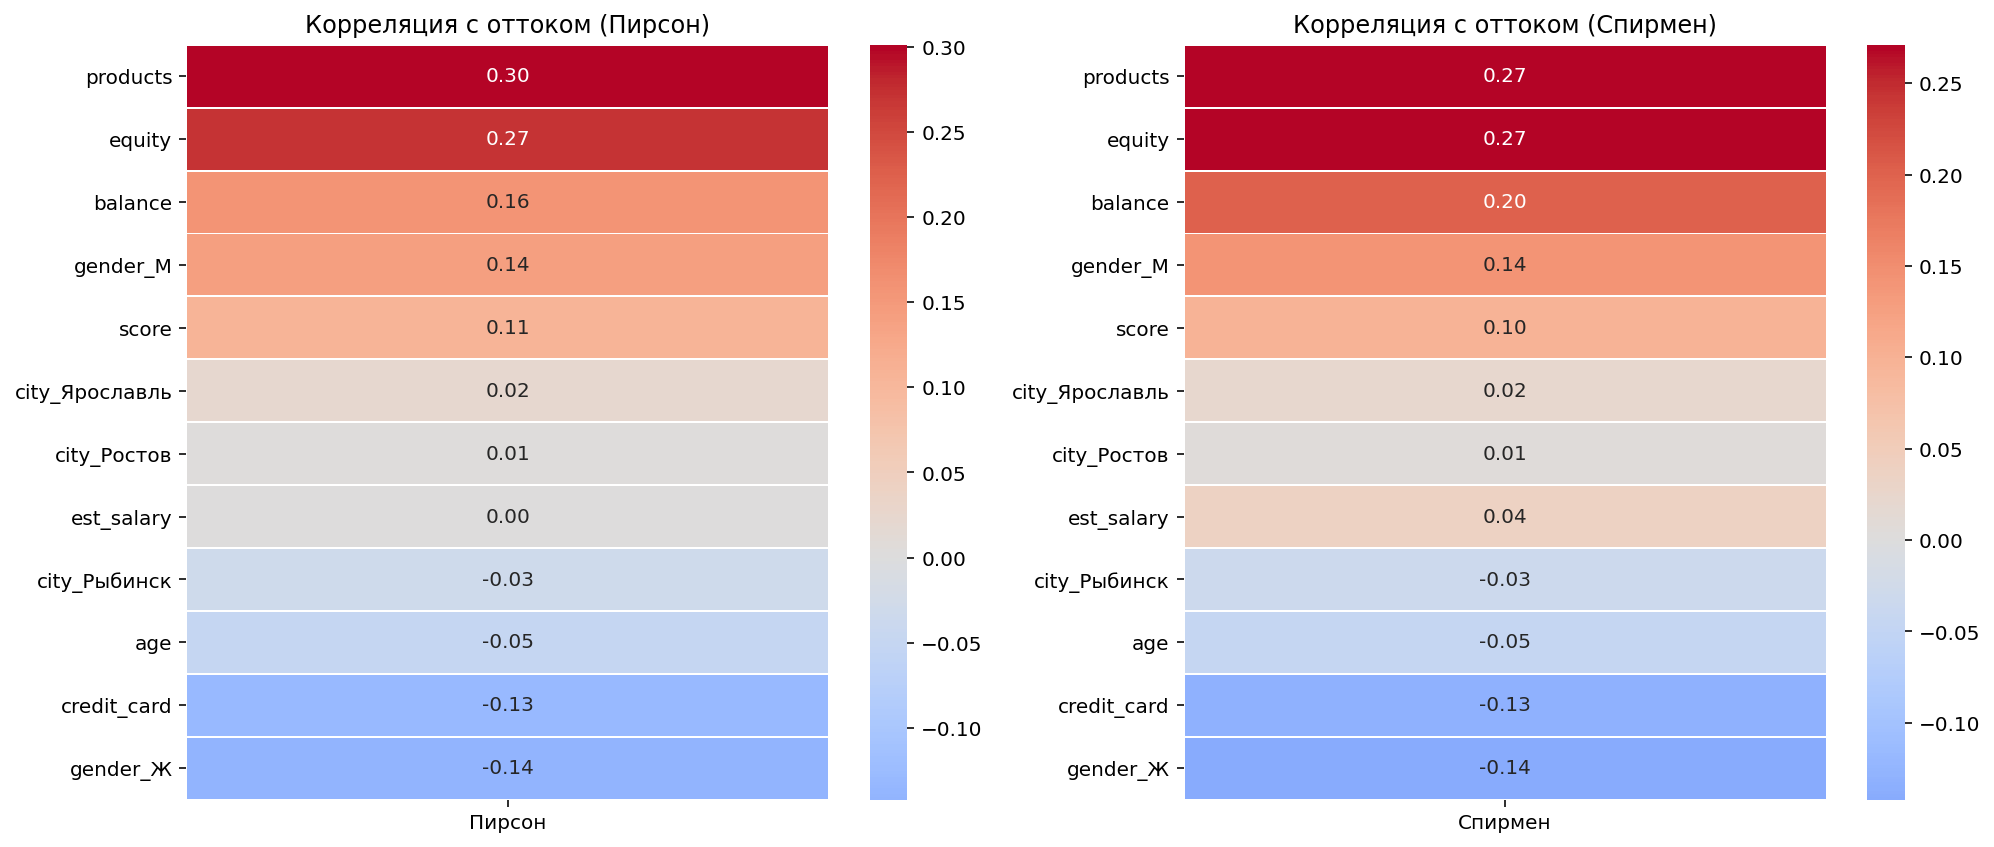

In [30]:
# Определяем все числовые признаки, включая закодированные категориальные
numerical_features = ['age', 'balance', 'est_salary', 'score', 'equity', 'products', 
                      'credit_card', 'city_Ростов', 'city_Рыбинск', 'city_Ярославль', 
                      'gender_Ж', 'gender_М']

# Добавляем целевой признак churn
features_with_target = numerical_features + ['churn']

# Рассчитываем корреляцию Пирсона с оттоком
pearson_corr = bank_clients_data[features_with_target].corr(method='pearson')['churn'].drop('churn')

# Рассчитываем корреляцию Спирмена с оттоком
spearman_corr = bank_clients_data[features_with_target].corr(method='spearman')['churn'].drop('churn')

# Объединяем результаты в DataFrame
correlation_results = pd.DataFrame({'Пирсон': pearson_corr, 'Спирмен': spearman_corr})
correlation_results = correlation_results.sort_values(by='Пирсон', ascending=False)

# Округляем значения до 3 знаков
correlation_results = correlation_results.round(3)

# Создаем холст с двумя графиками рядом
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Визуализация корреляции Пирсона с оттоком (слева)
sns.heatmap(correlation_results[['Пирсон']], annot=True, fmt=".2f", cmap='coolwarm', center=0, linewidths=0.5, ax=axes[0])
axes[0].set_title("Корреляция с оттоком (Пирсон)")

# Визуализация корреляции Спирмена с оттоком (справа)
sns.heatmap(correlation_results[['Спирмен']], annot=True, fmt=".2f", cmap='coolwarm', center=0, linewidths=0.5, ax=axes[1])
axes[1].set_title("Корреляция с оттоком (Спирмен)")

# Улучшаем компоновку графиков
plt.tight_layout()
plt.show()

Теперь интерпретируем корреляцию **по шкале Чеддока**.

In [31]:
def interpret_correlation(value):
    """ Интерпретация коэффициента корреляции по шкале Чеддока """
    if abs(value) < 0.1:
        return "Очень слабая связь"
    elif abs(value) < 0.3:
        return "Слабая связь"
    elif abs(value) < 0.5:
        return "Умеренная связь"
    elif abs(value) < 0.7:
        return "Заметная связь"
    elif abs(value) < 0.9:
        return "Высокая связь"
    else:
        return "Очень высокая связь"

# Добавляем интерпретацию для каждого признака
correlation_results['Интерпретация (Пирсон)'] = correlation_results['Пирсон'].apply(interpret_correlation)
correlation_results['Интерпретация (Спирмен)'] = correlation_results['Спирмен'].apply(interpret_correlation)

# Выводим таблицу с интерпретацией
print("Интерпретация корреляции по шкале Чеддока:")
display(correlation_results)

Интерпретация корреляции по шкале Чеддока:


,Пирсон,Спирмен,Интерпретация (Пирсон),Интерпретация (Спирмен)
products,0.301,0.271,Умеренная связь,Слабая связь
equity,0.270,0.268,Слабая связь,Слабая связь
balance,0.159,0.203,Слабая связь,Слабая связь
gender_М,0.142,0.142,Слабая связь,Слабая связь
score,0.107,0.097,Слабая связь,Очень слабая связь
city_Ярославль,0.024,0.024,Очень слабая связь,Очень слабая связь
city_Ростов,0.005,0.005,Очень слабая связь,Очень слабая связь
est_salary,0.002,0.038,Очень слабая связь,Очень слабая связь
city_Рыбинск,-0.031,-0.031,Очень слабая связь,Очень слабая связь
age,-0.050,-0.046,Очень слабая связь,Очень слабая связь


Коэффициент **Пирсона** показывает, насколько признаки связаны **линейно**, а **Спирмена** – любые **монотонные зависимости**. В нашем случае значения похожи, значит, связь в основном **линейная**. Разница есть у `products` и `score`, что может указывать на нелинейные зависимости. Для анализа лучше смотреть на **Пирсона**, но учитывать Спирмена, если связь может быть сложной.


Дополнительно построим **попарные графики**, чтобы детальнее изучить взаимосвязи между признаками, которые продемонстрировали хотя бы небольшую корреляцию с оттоком.

<Figure size 864x864 with 0 Axes>

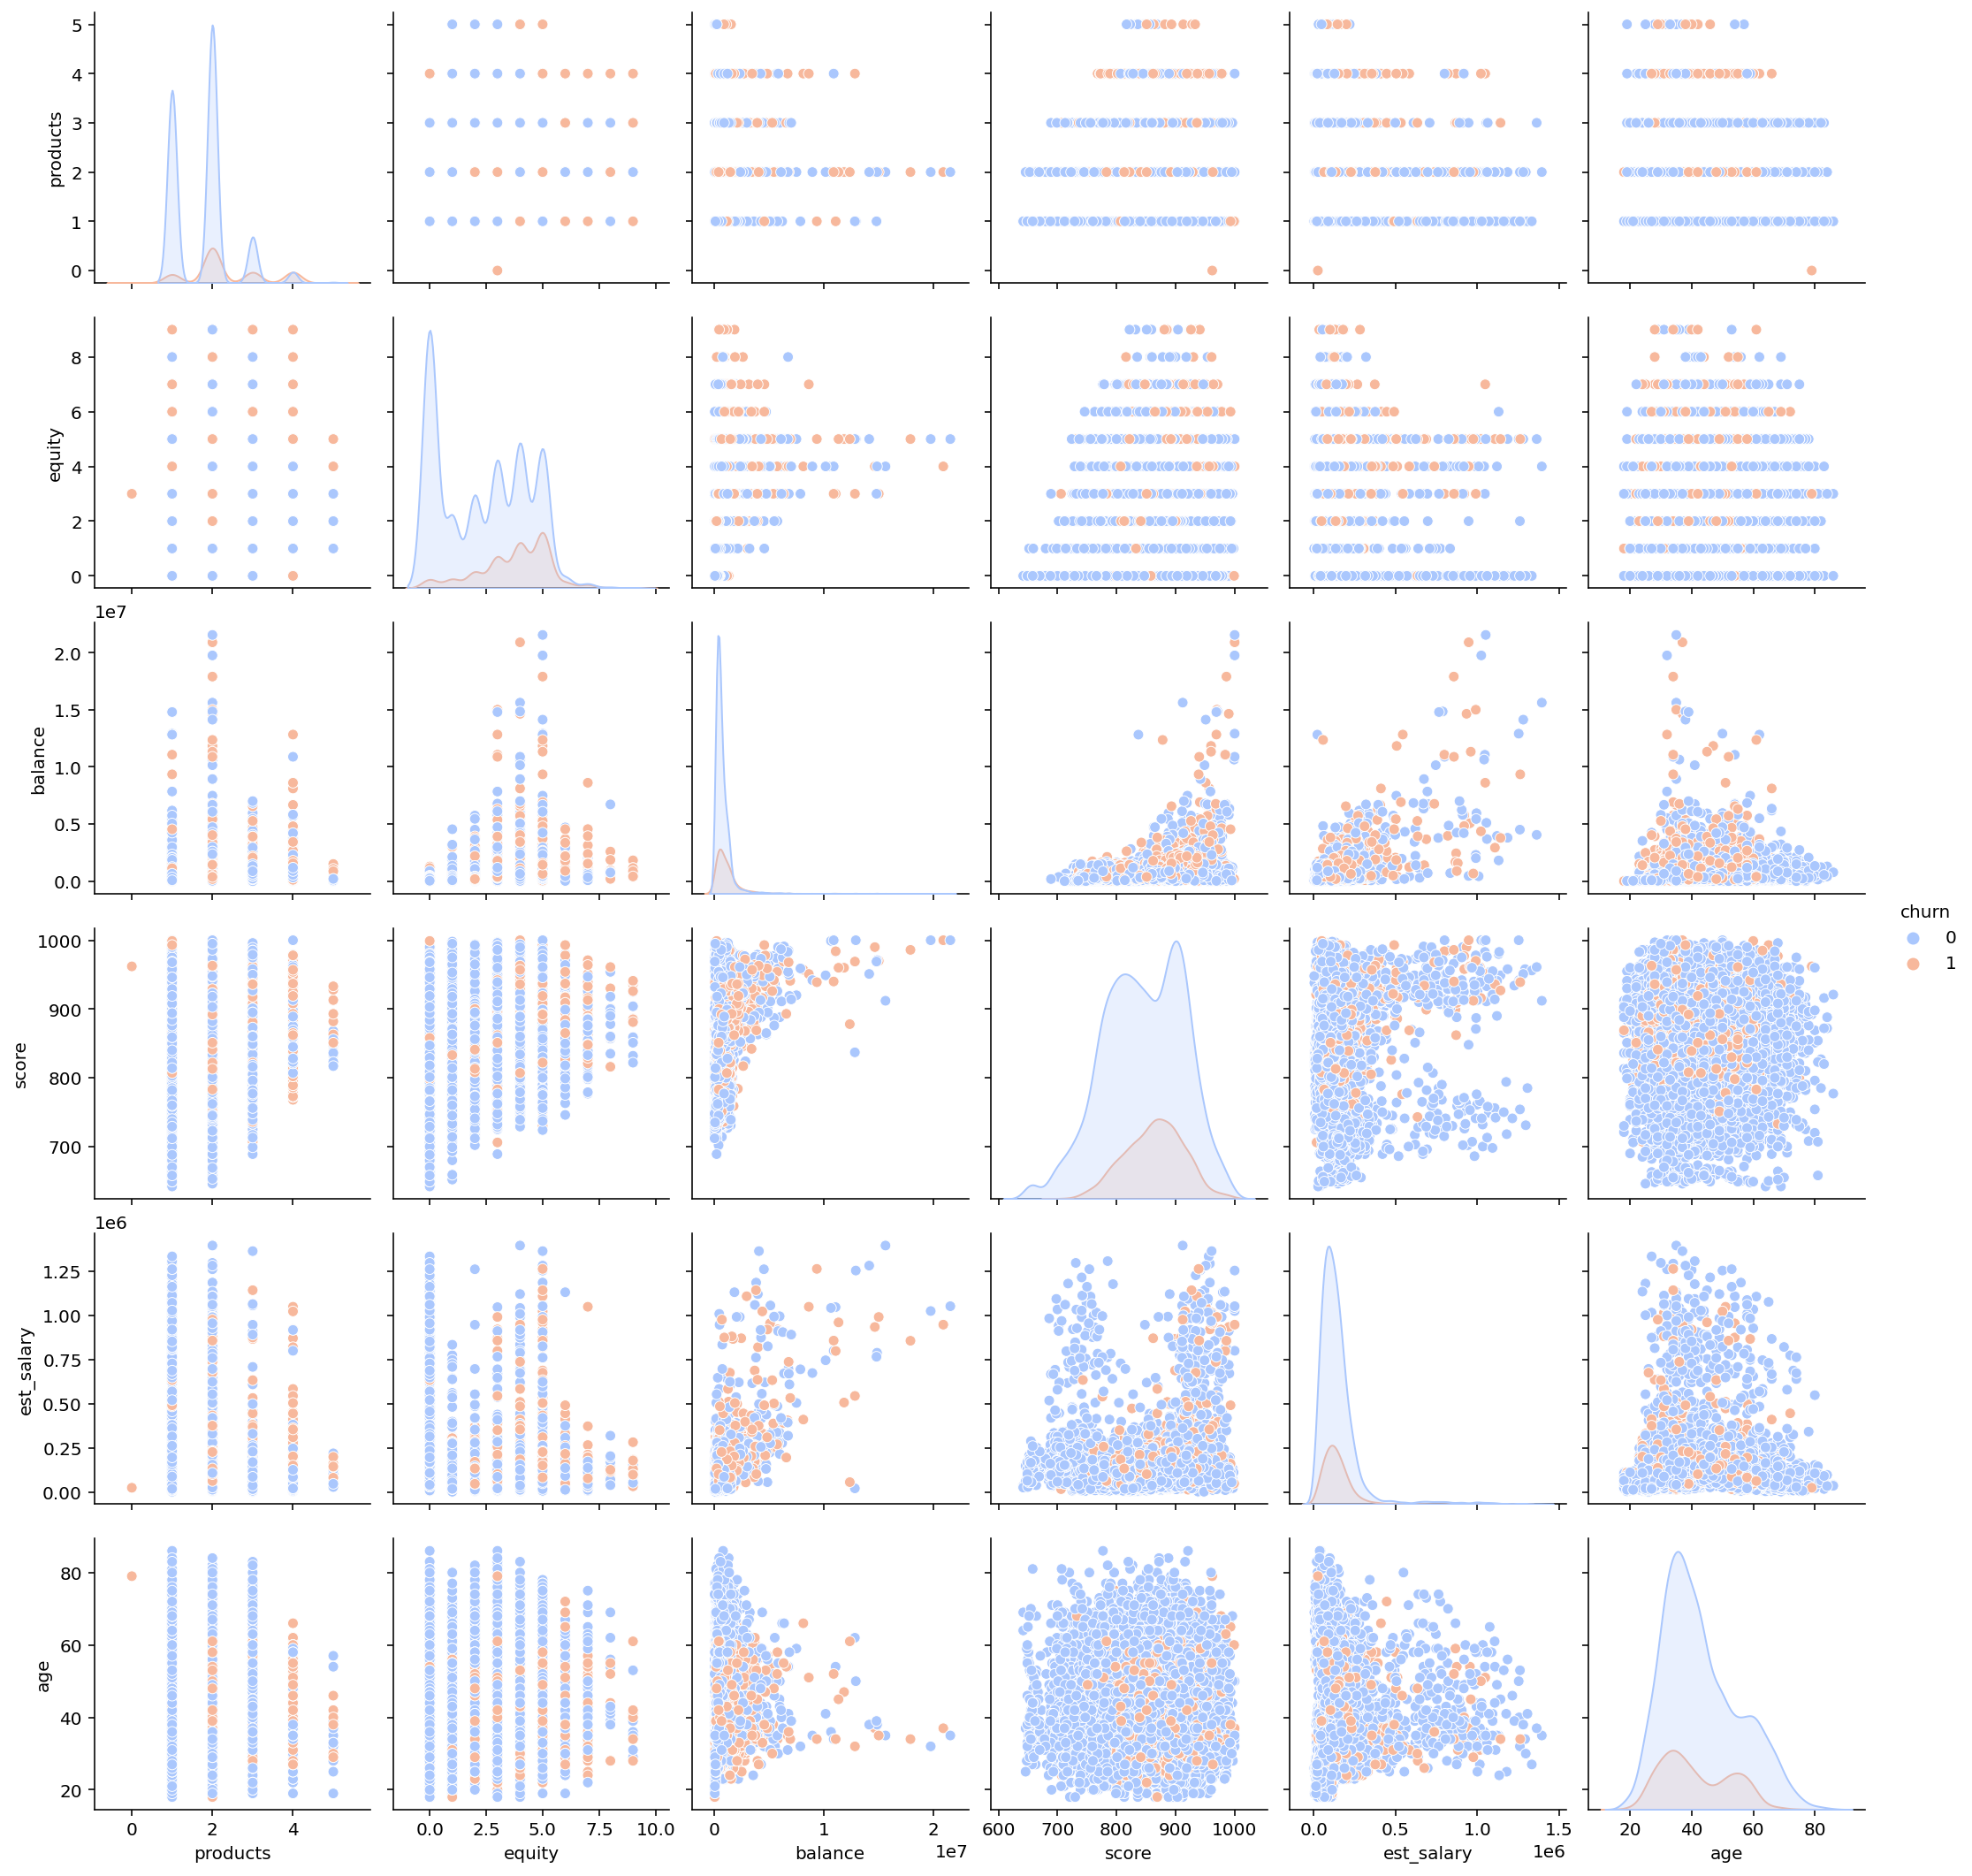

In [32]:
# Выбираем признаки, которые показали хоть какую-то значимую связь с оттоком
selected_features = ['products', 'equity', 'balance', 'score', 'est_salary',
                     'age', 'churn']

# Строим попарные графики
plt.figure(figsize=(12, 12))
sns.pairplot(bank_clients_data[selected_features], hue="churn", palette="coolwarm", diag_kind="kde")

# Отображаем график
plt.show()

На основании полученных результатов, можно сделать вывод, что корреляционный анализ признака `churn` с другими признаками показал, что **наибольшее влияние на отток оказывают следующие факторы** (в порядке убывания значимости):  

1. **Наиболее значимые факторы оттока (по Пирсону и Спирмену):**  
   - **количество продуктов (products)**: имеет **умеренную** (0.301) и **слабую** (0.271) связь с оттоком. Это наиболее сильный фактор;  
   - **количество активов (equity)**: **слабая** связь (0.270 по Пирсону и 0.268 по Спирмену), но тоже один из ключевых факторов;
   - **баланс (balance)**: также демонстрирует **слабую** связь с оттоком (0.159 по Пирсону, 0.203 по Спирмену), что подтверждает значимость финансового состояния клиента.  
---
2. **Дополнительные, но менее значимые факторы:**
   - **пол (gender_М)**: слабая положительная связь (0.142), указывающая на то, что мужчины уходят чаще; 
   - **скоринговый балл (score)**: слабая положительная связь (0.107), но более значительная по Спирмену (0.097), что может указывать на нелинейную зависимость;
   - **город проживания (city_Ярославль, city_Ростов)**: связь практически отсутствует (0.024 и 0.005), значит, влияние региона незначительно;
   - **зарплата (est_salary)**: очень слабая связь (0.002 по Пирсону, 0.038 по Спирмену), указывающая на минимальное влияние дохода на отток.  
----
3. **Факторы, которые снижают вероятность оттока:**  
   - **наличие кредитной карты (credit_card)**: отрицательная слабая связь (-0.131). То есть клиенты с кредитной картой реже уходят;
   - **женский пол (gender_Ж)**: отрицательная слабая связь (-0.142), что означает, что женщины уходят реже.  
---
Обобщим информацию:
- **основные драйверы оттока**: количество продуктов, активы и баланс;  
- **менее значимые, но возможные факторы**: скоринг, пол, наличие кредитной карты; 
- **практически не влияющие факторы**: возраст, зарплата, город проживания.  


## Проверка гипотез, связянных с оттоком
<a id='Hypothesis_testing'></a> 

На данном шаге **будут проверены следующие гипотезы:**

1. **Гипотеза о различии среднего дохода (`est_salary`) между ушедшими и оставшимися клиентами**.
2. **Гипотеза о различии среднего баланса между ушедшими и оставшимися клиентами**. Графический анализ показал: различия есть, но распределение баланса сильно скошено, есть выбросы. Стоит проверить, возможно, медиана даст другие выводы, чем среднее.
3. **Гипотеза о влиянии количества продуктов на вероятность оттока**. Графический анализ показал, что клиенты с 2+ продуктами уходят чаще, но для 4 и 5 продуктов картина не совсем очевидна. Стоит проверить, так как возможны скрытые зависимости.
4. **Гипотеза о влиянии активности на отток**. Анализ активности не проводился детально, сложно сказать однозначно. 
5. **Гипотеза о наличие зависимости кредитного скоринга от оттока**. Графический анализ показал, что наблюдается отток в диапазоне 800-900, но нет четкой границы. Стоит проверить, если группировать по интервалам скоринга.


### Гипотеза о различии среднего дохода (`est_salary`) между ушедшими и оставшимися клиентами

Начнем с определения нулевой и альтернативной гипотезы:

- **`Нулевая гипотеза (H₀)`:** Средний доход (`est_salary`) у ушедших клиентов не отличается от среднего дохода оставшихся клиентов.  
- **`Альтернативная гипотеза (H₁)`:** Средний доход отличается между группами.

**Пороговое значение статистической значимости `alpha`** задается равным **0.05**. Это стандартное значение, которое означает, что вероятность ошибочного отклонения нулевой гипотезы не должна превышать 5%.

1. Если p-значение меньше `alpha` (0.05), **нулевая гипотеза отвергается** в пользу альтернативной.
2. Если p-значение больше `alpha`, **нулевая гипотеза не отвергается**, и можно считать, что статистически значимых различий нет.

Чтобы определить, какой тест использовать для проверки данной гипотезы (`t-тест Стьюдента`, который является приоритетным и более понятным для бизнеса, или альтернативный `тест Манна-Уитни`), необходимо сначала проверить условия применимости `t-теста Стьюдента`:  

1. **Независимость выборок** – это **условие выполняется**, так как сравниваются две группы клиентов: ушедшие (`churn == 1`) и оставшиеся (`churn == 0`). Принадлежность клиента к одной из групп не зависит от другой, что делает выборки независимыми.  

2. **Нормальность распределения** – этот критерий нужно будет определить. Сначала определим какая выборка. В зависимости от ее размера определимся с тестом:
    - если выборка **меньше 5 000 - тест Шапиро-Уилка** (точный, но для маленьких выборок);
    - если выборка **больше 5 000 - тест Андерсона-Дарлинга или Колмогорова-Смирнова**.

3. **Отсутствие явных выбросов** – в ходе анализа было выявлено небольшое количество аномально высоких значений (которые выбросами считать тоже не совсем верно, т.к. это могут быть премиальные клиенты). Но для минимизации их влияния на результаты анализа были удалены пять наиболее выбивающихся из общей картины клиентов. Затем дополнительно проводилась Z-оценка на наличие выбросов (найденные в результате Z-оценки выбросы были удалены, на основе полученных данных проведены повторно и тест Колмогорова-Смирнова, и t-тест Стьюдента - результат остался прежним). *Чтобы не усложнять данный раздел, результаты Z-оценки и t-теста здесь не приводятся*. Следовательно, можно сделать вывод, что **условие для проведения t-теста Стьюдента по отсутсвию явных выбросов можно считать выполненным**, результаты теста искажены не будут.

4. **Равенство дисперсий** – этот параметр нужно определить. Если разница в размере выборок менее чем 25%, то для проверки будем использовать тест Левена (`levene()`), так как он менее чувствителен к ненормальному распределению данных и является предпочтительным в большинстве случаев. Если разница будет более 25%, тест Левена проводить уже будет нецелесообразно - в любом случае будет использоваться `поправка Уэлча` через настройку `equal_var=False`.


Сначала **определим размер выборки**, чтобы выбрать подходящий тест для проверки нормальности распределения данных.

In [33]:
# Определяем размер выборок
size_left = bank_clients_data.loc[bank_clients_data['churn'] == 1, 'est_salary'].shape[0]
size_stayed = bank_clients_data.loc[bank_clients_data['churn'] == 0, 'est_salary'].shape[0]
total_size = size_left + size_stayed  # Общее количество наблюдений

# Вычисляем процентное соотношение
percent_left = (size_left / total_size) * 100
percent_stayed = (size_stayed / total_size) * 100

# Вычисляем разницу в проценте между выборками
percent_difference = abs(percent_left - percent_stayed)

# Выводим результаты
print(f"Размер выборки ушедших клиентов: {size_left} ({percent_left:.2f}%)")
print(f"Размер выборки оставшихся клиентов: {size_stayed} ({percent_stayed:.2f}%)")
print(f"Общий размер выборки: {total_size}")
print(f"Разница в проценте между выборками: {percent_difference:.2f}%")

Размер выборки ушедших клиентов: 1818 (18.24%)
Размер выборки оставшихся клиентов: 8151 (81.76%)
Общий размер выборки: 9969
Разница в проценте между выборками: 63.53%


Видим, что размер выборки больше 5 000 наблюдений, тест Шапиро-Уилка использовать нецелесообразно. Вместо него будем применять **тест Колмогорова-Смирнова** – подходит для проверки нормальности в больших выборках.

---
**Сформулируем гипотезы для теста Колмогорова-Смирнова:**  

- **Нулевая гипотеза(H₀):** распределение выборки (ушли, остались) не отличается от нормального.  
- **Альтернативная гипотеза (H₁):** распределение выборки (ушли, остались) существенно отличается от нормального.  

Результаты теста помогут определить, можно ли считать данные нормально распределёнными и, следовательно, корректно ли применять ttest.

In [34]:
# Разделяем выборки
est_salary_left = bank_clients_data[bank_clients_data['churn'] == 1]['est_salary']
est_salary_stayed = bank_clients_data[bank_clients_data['churn'] == 0]['est_salary']

# Тест Колмогорова-Смирнова для ушедших клиентов
ks_stat_left, p_value_left = stats.kstest(est_salary_left, 'norm', args=(est_salary_left.mean(), est_salary_left.std()))

# Тест Колмогорова-Смирнова для оставшихся клиентов
ks_stat_stayed, p_value_stayed = stats.kstest(est_salary_stayed, 'norm', args=(est_salary_stayed.mean(), est_salary_stayed.std()))

# Вывод результатов
print("Тест Колмогорова-Смирнова для ушедших клиентов:")
print(f"Статистика: {ks_stat_left:.4f}, p-value: {p_value_left:.4f}")

print("\nТест Колмогорова-Смирнова для оставшихся клиентов:")
print(f"Статистика: {ks_stat_stayed:.4f}, p-value: {p_value_stayed:.4f}")

# Интерпретация результатов
alpha = 0.05
if p_value_left < alpha:
    print("\nРаспределение дохода у ушедших клиентов не является нормальным.")
else:
    print("\nРаспределение дохода у ушедших клиентов можно считать нормальным.")

if p_value_stayed < alpha:
    print("Распределение дохода у оставшихся клиентов не является нормальным.")
else:
    print("Распределение дохода у оставшихся клиентов можно считать нормальным**.")


Тест Колмогорова-Смирнова для ушедших клиентов:
Статистика: 0.1674, p-value: 0.0000

Тест Колмогорова-Смирнова для оставшихся клиентов:
Статистика: 0.1864, p-value: 0.0000

Распределение дохода у ушедших клиентов не является нормальным.
Распределение дохода у оставшихся клиентов не является нормальным.


Результаты теста Колмогорова-Смирнова показывают, что p-value в обоих тестах (0.0000) значительно меньше уровня значимости 0.05, следовательно, мы отвергаем нулевую гипотезу и принимаем альтернативную о том, что **распределение дохода (`est_salary`) не является нормальным для обеих групп клиентов (ушедших и оставшихся)**. 

Однако, ненормальность распределения компенсируется Центральной предельной теоремой (ЦПТ), которая означает, что если выборка достаточно большая (обычно больше 30 наблюдений в каждой группе), то распределение среднего значения приближается к нормальному, даже если исходные данные не нормальны. У нас 1818 ушедших клиентов и 8151 оставшихся клиентов — это большая выборка. Поэтому **ЦПТ компенсирует ненормальность, и t-тест Стьюдента (с поправкой Уэлча при неравенстве дисперсий и/или разнице в размере выборок более чем на 25% ) можно применять**.

---
Следующим этапом является проверка **равенства дисперсий** перед проведением t-теста Стьюдента. Однако, поскольку размер выборок существенно отличается (разница составляет почти 64%, что превышает пороговое значение в 25%), **тест Левене на равенство дисперсий проводить не требуется**. В данной ситуации корректнее сразу использовать **t-тест с поправкой Уэлча**, который учитывает различие в дисперсиях.

---


Поскольку **все условия для применения `t-теста Стьюдента` выполнены**, для проверки гипотезы о различии среднего дохода между ушедшими и оставшимися клиентами будет использован **t-тест Стьюдента с поправкой Уэлча (`equal_var=False`)**.

Проведем **t-тест Стьюдента с поправкой Уэлча**.

In [35]:
t_stat, p_value = stats.ttest_ind(est_salary_left, est_salary_stayed, equal_var=False)
test_type = "Результат t-тест Стьюдента с поправкой Уэлча (equal_var=False):"

print(f"\n{test_type}")
print(f"Статистика t-теста: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

# Интерпретация результата
alpha = 0.05
if p_value < alpha:
    print("Отклоняем нулевую гипотезу: Средний доход различается между ушедшими и оставшимися клиентами.")
else:
    print("Не получилось отвергнуть нулевую гипотезу: Нет статистически значимых различий в среднем доходе между группами.")


Результат t-тест Стьюдента с поправкой Уэлча (equal_var=False):
Статистика t-теста: 0.2198
p-value: 0.8260
Не получилось отвергнуть нулевую гипотезу: Нет статистически значимых различий в среднем доходе между группами.


Поскольку полученное значение **p-value (0.2198)** значительно превышает установленный уровень статистической значимости **alpha (0.05)**, нулевая гипотеза не отвергается: статистически значимых различий в среднем доходе между ушедшими и оставшимися клиентами не выявлено.


Прежде чем окончательно принять решение о сохранении нулевой гипотезы, рекомендуется дополнительно рассчитать **доверительные интервалы (CI)** для среднего пользовательского дохода. Доверительные интервалы помогают оценить разброс данных и их достоверность. Если интервалы двух групп пересекаются, различие средних значений, скорее всего, не является статистически значимым. В противном случае отсутствие перекрытия свидетельствует о значимой разнице между группами.

In [36]:
# Проверяем средний доход для ушедших и оставшихся клиентов
print('Средний доход оставшихся клиентов :', round(est_salary_left.mean(), 2))
print('Средний доход ушедших клиентов:', round(est_salary_stayed.mean(), 2))
print('-' * 80)

def compute_confidence_interval(data, confidence=0.95):
    """
    Рассчитывает доверительный интервал (CI) для средних значений выборки.
    """
    mean = np.mean(data)  # Среднее значение
    sem = stats.sem(data)  # Стандартная ошибка среднего (SEM)
    ci_range = stats.t.ppf((1 + confidence) / 2, len(data) - 1) * sem  # Границы CI
    return mean - ci_range, mean + ci_range  # Нижняя и верхняя граница CI

# Вычисляем доверительные интервалы для дохода ушедших и оставшихся клиентов
ci_churned = compute_confidence_interval(est_salary_left)
ci_stayed = compute_confidence_interval(est_salary_stayed)

# Вывод результатов
print(f"Доверительный интервал для ушедших клиентов: {ci_churned[0]:.2f} - {ci_churned[1]:.2f}")
print(f"Доверительный интервал для оставшихся клиентов: {ci_stayed[0]:.2f} - {ci_stayed[1]:.2f}")

# Проверяем, перекрываются ли доверительные интервалы
if ci_churned[0] <= ci_stayed[1] and ci_stayed[0] <= ci_churned[1]:
    print("Доверительные интервалы перекрываются - Различие средних значений незначимо.")
else:
    print("Доверительные интервалы НЕ перекрываются - Различие средних значений статистически значимо.")

Средний доход оставшихся клиентов : 148322.39
Средний доход ушедших клиентов: 147599.74
--------------------------------------------------------------------------------
Доверительный интервал для ушедших клиентов: 142666.54 - 153978.24
Доверительный интервал для оставшихся клиентов: 144505.13 - 150694.35
Доверительные интервалы перекрываются - Различие средних значений незначимо.


Дополнительный расчет доверительных интервалов подтвердил выводы:

- Для ушедших клиентов доверительный интервал составляет: **142 666.54 - 153 978.24**
- Для оставшихся клиентов: **144 505.13 - 150 694.35**

Поскольку **интервалы перекрываются**, это указывает на отсутствие статистически значимых различий между средним доходом ушедших и оставшихся клиентов. Таким образом, **нулевая гипотеза о равенстве среднего дохода между двумя группами сохраняется**.

### Гипотеза о различии среднего баланса (`balance`) между ушедшими и оставшимися клиентами

Начнем с определения нулевой и альтернативной гипотезы:

- **`Нулевая гипотеза (H₀)`**: Средний баланс (`balance`) клиентов, которые ушли (`churn == 1`), не отличается от среднего баланса оставшихся клиентов (`churn == 0)`.

- **`Альтернативная гипотеза (H₁)`**: Средний баланс клиентов, которые ушли, отличается от среднего баланса оставшихся.

**Пороговое значение статистической значимости `alpha`** задается равным **0.05**. Это стандартное значение, которое означает, что вероятность ошибочного отклонения нулевой гипотезы не должна превышать 5%.

1. Если p-значение меньше `alpha` (0.05), **нулевая гипотеза отвергается** в пользу альтернативной.
2. Если p-значение больше `alpha`, **нулевая гипотеза не отвергается**, и можно считать, что статистически значимых различий нет.

Чтобы определить, какой тест использовать для проверки данной гипотезы (`t-тест Стьюдента`, который является приоритетным и более понятным для бизнеса, или альтернативный `тест Манна-Уитни`), необходимо сначала проверить условия применимости `t-теста Стьюдента`:  

1. **Независимость выборок** – это условие выполняется, так как сравниваются две группы клиентов: ушедшие (`churn == 1`) и оставшиеся (`churn == 0`). Принадлежность клиента к одной из групп не зависит от другой, что делает выборки независимыми.  

2. **Нормальность распределения** – этот критерий нужно будет определить. Сначала определим какая выборка. В зависимости от ее размера определимся с тестом:
    - если выборка **меньше 5 000 - тест Шапиро-Уилка** (точный, но для маленьких выборок);
    - если выборка **больше 5 000 - тест Андерсона-Дарлинга или Колмогорова-Смирнова**.

3. **Отсутствие явных выбросов** – в ходе анализа было выявлено небольшое количество аномально высоких значений (которые выбросами считать тоже не совсем верно, т.к. это могут быть премиальные клиенты). Но для минимизации их влияния на результаты анализа были удалены пять наиболее выбивающихся из общей картины клиентов. Затем дополнительно проводилась Z-оценка на наличие выбросов (найденные в результате Z-оценки выбросы были удалены, на основе полученных данных проведены повторно и тест Колмогорова-Смирнова, и t-тест Стьюдента - результат остался прежним). *Чтобы не усложнять данный раздел, результаты Z-оценки и t-теста здесь не приводятся*. Следовательно, можно сделать вывод, что **условие для проведения t-теста Стьюдента по отсутсвию явных выбросов можно считать выполненным**, результаты теста искажены не будут.

4. **Равенство дисперсий** – этот параметр нужно определить. Если разница в размере выборок менее чем 25%, то для проверки будем использовать тест Левена (`levene()`), так как он менее чувствителен к ненормальному распределению данных и является предпочтительным в большинстве случаев. Если разница будет более 25%, тест Левена проводить уже будет нецелесообразно - в любом случае будет использоваться `поправка Уэлча` через настройку `equal_var=False`.



Сначала **определим размер выборки**, чтобы выбрать подходящий тест для проверки нормальности распределения данных.  

В признаке `balance` есть достаточно много пропущенных значений, это нужно учитывать. `NaN` могут повлиять на размер выборок. Поэтому отфильтруем данные: исключим строки, где `balance = NaN`.

In [37]:
# Определяем размер выборок, исключая пропуски в balance
size_left_balance = bank_clients_data.loc[(bank_clients_data['churn'] == 1) & (bank_clients_data['balance'].notna()), 'balance'].shape[0]
size_stayed_balance = bank_clients_data.loc[(bank_clients_data['churn'] == 0) & (bank_clients_data['balance'].notna()), 'balance'].shape[0]
total_size_balance = size_left_balance + size_stayed_balance  # Общее количество наблюдений с непустыми балансами

# Вычисляем процентное соотношение
percent_left_balance = (size_left_balance / total_size_balance) * 100
percent_stayed_balance = (size_stayed_balance / total_size_balance) * 100

# Вычисляем разницу в проценте между выборками
percent_difference = abs(percent_left_balance - percent_stayed_balance)

# Выводим результаты
print(f"Размер выборки ушедших клиентов (balance): {size_left_balance} ({percent_left_balance:.2f}%)")
print(f"Размер выборки оставшихся клиентов (balance): {size_stayed_balance} ({percent_stayed_balance:.2f}%)")
print(f"Общий размер выборки (balance): {total_size_balance}")
print(f"Разница в проценте между выборками: {percent_difference:.2f}%")

Размер выборки ушедших клиентов (balance): 1805 (23.47%)
Размер выборки оставшихся клиентов (balance): 5885 (76.53%)
Общий размер выборки (balance): 7690
Разница в проценте между выборками: 53.06%


Видим, что размер выборки больше 5 000 наблюдений, тест Шапиро-Уилка использовать нецелесообразно. Вместо него будем применять **тест Колмогорова-Смирнова** – подходит для проверки нормальности в больших выборках.

---
**Сформулируем гипотезы для теста Колмогорова-Смирнова:**  

- **Нулевая гипотеза(H₀):** распределение выборки (ушли, остались) не отличается от нормального.  
- **Альтернативная гипотеза (H₁):** распределение выборки (ушли, остались) существенно отличается от нормального.  

Результаты теста помогут определить, можно ли считать данные нормально распределёнными и, следовательно, корректно ли применять ttest.

In [38]:
# Разделяем выборки по оттоку, исключая пропуски
balance_left = bank_clients_data.loc[(bank_clients_data['churn'] == 1) & (bank_clients_data['balance'].notna()), 'balance']
balance_stayed = bank_clients_data.loc[(bank_clients_data['churn'] == 0) & (bank_clients_data['balance'].notna()), 'balance']

# Тест Колмогорова-Смирнова для ушедших клиентов
ks_stat_left, p_value_left = stats.kstest(balance_left, 'norm', args=(balance_left.mean(), balance_left.std()))
print(f"Тест Колмогорова-Смирнова для ушедших клиентов:")
print(f"Статистика: {ks_stat_left:.4f}, p-value: {p_value_left:.4f}")

# Тест Колмогорова-Смирнова для оставшихся клиентов
ks_stat_stayed, p_value_stayed = stats.kstest(balance_stayed, 'norm', args=(balance_stayed.mean(), balance_stayed.std()))
print(f"\nТест Колмогорова-Смирнова для оставшихся клиентов:")
print(f"Статистика: {ks_stat_stayed:.4f}, p-value: {p_value_stayed:.4f}")

# Интерпретация результата
if p_value_left < 0.05:
    print("\nРаспределение баланса у ушедших клиентов не является нормальным.")
else:
    print("\nРаспределение баланса у ушедших клиентов можно считать нормальным.")

if p_value_stayed < 0.05:
    print("Распределение баланса у оставшихся клиентов не является нормальным.")
else:
    print("Распределение баланса у оставшихся клиентов можно считать нормальным.")


Тест Колмогорова-Смирнова для ушедших клиентов:
Статистика: 0.2119, p-value: 0.0000

Тест Колмогорова-Смирнова для оставшихся клиентов:
Статистика: 0.2299, p-value: 0.0000

Распределение баланса у ушедших клиентов не является нормальным.
Распределение баланса у оставшихся клиентов не является нормальным.


Результаты теста Колмогорова-Смирнова показывают, что p-value в обоих тестах (0.0000) значительно меньше уровня значимости 0.05, следовательно, мы отвергаем нулевую гипотезу и принимаем альтернативную о том, что **распределение баланса (`balance`) не является нормальным для обеих групп клиентов (ушедших и оставшихся)**. 

Однако, ненормальность распределения компенсируется Центральной предельной теоремой (ЦПТ), которая означает, что если выборка достаточно большая (обычно >30 наблюдений в каждой группе), то распределение среднего значения приближается к нормальному, даже если исходные данные не нормальны. У нас 1805 ушедших клиентов и 5885 оставшихся клиентов — это большая выборка. Поэтому **ЦПТ компенсирует ненормальность, и t-тест Стьюдента (с поправкой Уэлча при неравенстве дисперсий и/или разнице в размере выборок более чем на 25% ) можно применять**.

Следующим этапом является проверка **равенства дисперсий** перед проведением t-теста Стьюдента. Однако, поскольку размер выборок существенно отличается (разница составляет 53%, что превышает пороговое значение в 25%), **тест Левене на равенство дисперсий проводить не требуется**. В данной ситуации корректнее сразу использовать **t-тест с поправкой Уэлча**, который учитывает различие в дисперсиях.

----

Поскольку **все условия для применения `t-теста Стьюдента` выполнены**, для проверки гипотезы о различии среднего баланса между ушедшими и оставшимися клиентами будет использован **t-тест Стьюдента с поправкой Уэлча (`equal_var=False`)**.

Проведем **t-тест Стьюдента с поправкой Уэлча**.

In [39]:
t_stat, p_value = stats.ttest_ind(balance_left, balance_stayed, equal_var=False)
test_type = "Результат t-тест Стьюдента с поправкой Уэлча (equal_var=False):"

print(f"\n{test_type}")
print(f"Статистика t-теста: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

# Интерпретация результата
alpha = 0.05
if p_value < alpha:
    print("Отклоняем нулевую гипотезу: Средний баланс различается между ушедшими и оставшимися клиентами.")
else:
    print("Не получилось отвергнуть нулевую гипотезу: Нет статистически значимых различий в среднем балансе между группами.")


Результат t-тест Стьюдента с поправкой Уэлча (equal_var=False):
Статистика t-теста: 11.6336
p-value: 0.0000
Отклоняем нулевую гипотезу: Средний баланс различается между ушедшими и оставшимися клиентами.


Так как полученное p-value (0.0000) значительно меньше установленного уровня статистической значимости alpha (0.05), **нулевая гипотеза отвергается**. Это свидетельствует о **наличии статистически значимых различий в среднем балансе** между ушедшими и оставшимися клиентами.

Прежде чем окончательно принять решение об отклонении нулевой гипотезы, для дополнительной проверки рассчитаем **доверительные интервалы (CI)** для среднего пользовательского баланса. Доверительные интервалы помогают оценить разброс данных и их достоверность. Если интервалы двух групп пересекаются, различие средних значений, скорее всего, не является статистически значимым. В противном случае отсутствие перекрытия свидетельствует о значимой разнице между группами.

In [40]:
# Проверяем средний баланс для ушедших и оставшихся клиентов
print('Средний баланс оставшихся клиентов :', round(balance_left.mean(), 2))
print('Средний баланс ушедших клиентов:', round(balance_stayed.mean(), 2))
print('-' * 80)

def compute_confidence_interval(data, confidence=0.95):
    """
    Рассчитывает доверительный интервал (CI) для средних значений выборки.
    """
    mean = np.mean(data)  # Среднее значение
    sem = stats.sem(data)  # Стандартная ошибка среднего (SEM)
    ci_range = stats.t.ppf((1 + confidence) / 2, len(data) - 1) * sem  # Границы CI
    return mean - ci_range, mean + ci_range  # Нижняя и верхняя граница CI

# Вычисляем доверительные интервалы для дохода ушедших и оставшихся клиентов
ci_churned = compute_confidence_interval(balance_left)
ci_stayed = compute_confidence_interval(balance_stayed)

# Вывод результатов
print(f"Доверительный интервал для ушедших клиентов: {ci_churned[0]:.2f} - {ci_churned[1]:.2f}")
print(f"Доверительный интервал для оставшихся клиентов: {ci_stayed[0]:.2f} - {ci_stayed[1]:.2f}")

# Проверяем, перекрываются ли доверительные интервалы
if ci_churned[0] <= ci_stayed[1] and ci_stayed[0] <= ci_churned[1]:
    print("Доверительные интервалы перекрываются - Различие средних значений незначимо.")
else:
    print("Доверительные интервалы НЕ перекрываются - Различие средних значений статистически значимо.")

Средний баланс оставшихся клиентов : 1099149.76
Средний баланс ушедших клиентов: 696634.82
--------------------------------------------------------------------------------
Доверительный интервал для ушедших клиентов: 1035710.32 - 1162589.20
Доверительный интервал для оставшихся клиентов: 672556.39 - 720713.25
Доверительные интервалы НЕ перекрываются - Различие средних значений статистически значимо.


Средний баланс ушедших клиентов существенно ниже, чем у оставшихся. **Отсутствие пересечения доверительных интервалов** подтверждает статистически значимые различия между группами. Следовательно, **нулевую гипотезу о равенстве средних балансов можно уверенно отклонить**.

### Гипотеза о влиянии количества продуктов (`products`) на вероятность оттока
Начнем с определения нулевой и альтернативной гипотезы:

**`Нулевая гипотеза (H₀)`**: Количество продуктов **не влияет** на вероятность оттока (распределение оттока одинаково среди всех групп).
**`Альтернативная гипотеза (H₁)`**: Количество продуктов **влияет** на вероятность оттока (распределение оттока различается в зависимости от количества продуктов).

***Метод:***

Так как `products` — дискретный признак, принимающий ограниченное количество значений (до 5, а это очень важный момент, иначе при, например, 100+ разных категорий, можно было бы получить искажение результата теста), будем использовать используем **хи-квадрат тест**, который проверяет зависимость между категориальными переменными. Т.е. в данному случае будет произведена группировака клиентов по количеству имеющих продуктов и проведена проверка наличия статистической зависимости между числом продуктов и оттоком.

**Пороговое значение статистической значимости `alpha`** задается равным **0.05**. Это стандартное значение, которое означает, что вероятность ошибочного отклонения нулевой гипотезы не должна превышать 5%.

1. Если p-значение меньше `alpha` (0.05), **нулевая гипотеза отвергается** в пользу альтернативной.
2. Если p-значение больше `alpha`, **нулевая гипотеза не отвергается**, и можно считать, что статистически значимых различий нет.

Проверим гипотезу о влиянии количества продуктов на вероятность оттока , применяя хи-квадрат тест.

In [41]:
# Создаем таблицу сопряженности (частоты оттока в каждой категории количества продуктов)
contingency_table = pd.crosstab(bank_clients_data['products'], bank_clients_data['churn'])

# Применяем хи-квадрат тест
chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table)

# Вывод результатов
print(f"Хи-квадрат статистика: {chi2_stat:.4f}")
print(f"p-value: {p_value:.10f}")

# Интерпретация результатов
alpha = 0.05
if p_value < alpha:
    print("Отклоняем нулевую гипотезу: количество продуктов влияет на вероятность оттока.")
else:
    print("Не получилось отвергнуть нулевую гипотезу: Нет статистически значимой зависимости между количеством продуктов и оттоком.")

Хи-квадрат статистика: 1012.9671
p-value: 0.0000000000
Отклоняем нулевую гипотезу: количество продуктов влияет на вероятность оттока.


Тест хи-квадрат показал, что существует **статистически значимая зависимость** между количеством продуктов и вероятностью оттока (p-value = 0.0000000000). Это означает, что распределение клиентов по количеству продуктов **различается** между ушедшими и оставшимися пользователями. 

Таким образом, можно **уверенно отклонить нулевую гипотезу** и сделать вывод, что **количество продуктов влияет на вероятность оттока**.

### Гипотеза о влиянии активности (`last_activity`) на отток

Начнем с определения нулевой и альтернативной гипотезы:

**`Нулевая гипотеза (H₀)`**: Средний уровень активности не отличается между ушедшими и оставшимися клиентами.

**`Альтернативная гипотеза (H₁)`**: Средний уровень активности отличается.

***Метод:***

Для проверки гипотезы о различии вероятности оттока между двумя группами клиентов (активными и неактивными), представленными бинарными признаками, применим **z-тест для пропорций**. Этот тест используется для сравнения долей категориальных переменных в двух независимых выборках.

**Пороговое значение статистической значимости `alpha`** задается равным **0.05**. Это стандартное значение, которое означает, что вероятность ошибочного отклонения нулевой гипотезы не должна превышать 5%.

1. Если p-значение меньше `alpha` (0.05), **нулевая гипотеза отвергается** в пользу альтернативной.
2. Если p-значение больше `alpha`, **нулевая гипотеза не отвергается**, и можно считать, что статистически значимых различий нет.

In [42]:
# Разделяем выборки по активности клиентов
active_clients = bank_clients_data[bank_clients_data['last_activity'] == 1]['churn']
inactive_clients = bank_clients_data[bank_clients_data['last_activity'] == 0]['churn']

# Количество ушедших клиентов в каждой группе
churn_active = active_clients.sum()
churn_inactive = inactive_clients.sum()

# Общее количество клиентов в каждой группе
total_active = len(active_clients)
total_inactive = len(inactive_clients)

# Доли ушедших клиентов в каждой группе
p1 = churn_active / total_active
p2 = churn_inactive / total_inactive

# Общая доля ушедших клиентов
p_combined = (churn_active + churn_inactive) / (total_active + total_inactive)

# Вычисляем стандартную ошибку
se = np.sqrt(p_combined * (1 - p_combined) * (1/total_active + 1/total_inactive))

# Вычисляем z-статистику
z_score = (p1 - p2) / se

# Вычисляем p-value
p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))

# Вывод результатов
print(f"Z-статистика: {z_score:.4f}")
print(f"p-value: {p_value:.10f}")

# Интерпретация результата
alpha = 0.05
if p_value < alpha:
    print("Отклоняем нулевую гипотезу: уровень активности влияет на отток.")
else:
    print("Не получилось отвергнуть нулевую гипотезу: статистически значимых различий в активности между группами нет.")

Z-статистика: 16.9127
p-value: 0.0000000000
Отклоняем нулевую гипотезу: уровень активности влияет на отток.


Результаты z-теста показали, что **уровень активности клиентов оказывает значимое влияние на отток**. Высокая z-статистика (16.91) и крайне низкое значение p-value (почти 0) свидетельствуют о **статистически значимых различиях между активными и неактивными клиентами**. Таким образом, **можно уверенно отклонить нулевую гипотезу: уровень активности клиентов действительно влияет на вероятность их оттока**.

### Гипотеза о влиянии кредитного скоринга (`score`) на отток

Начнем с определения нулевой и альтернативной гипотезы:

**`Нулевая гипотеза (H₀)`**: Средний кредитный скоринг не отличается между ушедшими (`churn == 1`) и оставшимися (`churn == 0`) клиентами.

**`Альтернативная гипотеза (H₁)`**: Средний кредитный скоринг различается между группами.

**Пороговое значение статистической значимости `alpha`** задается равным **0.05**. Это стандартное значение, которое означает, что вероятность ошибочного отклонения нулевой гипотезы не должна превышать 5%.

1. Если p-значение меньше `alpha` (0.05), **нулевая гипотеза отвергается** в пользу альтернативной.
2. Если p-значение больше `alpha`, **нулевая гипотеза не отвергается**, и можно считать, что статистически значимых различий нет.

Чтобы определить, какой тест использовать для проверки данной гипотезы (`t-тест Стьюдента`, который является приоритетным и более понятным для бизнеса, или альтернативный `тест Манна-Уитни`), необходимо сначала проверить условия применимости `t-теста Стьюдента`:  

1. **Независимость выборок** – это условие выполняется, так как сравниваются две группы клиентов: ушедшие (`churn == 1`) и оставшиеся (`churn == 0`). Принадлежность клиента к одной из групп не зависит от другой, что делает выборки независимыми.  

2. **Нормальность распределения** – этот критерий нужно будет определить. Сначала определим какая выборка. В зависимости от ее размера определимся с тестом:
    - если выборка **меньше 5 000 - тест Шапиро-Уилка** (точный, но для маленьких выборок);
    - если выборка **больше 5 000 - тест Андерсона-Дарлинга или Колмогорова-Смирнова**.

3. **Отсутствие явных выбросов** – в результате анализа в данных **не было выявлено аномально высоких/низких показателей**. Выбросов в данных нет.

4. **Равенство дисперсий** – этот параметр нужно определить. Если разница в размере выборок менее чем 25%, то для проверки будем использовать тест Левена (`levene()`), так как он менее чувствителен к ненормальному распределению данных и является предпочтительным в большинстве случаев. Если разница будет более 25%, тест Левена проводить уже будет нецелесообразно - в любом случае будет использоваться `поправка Уэлча` через настройку `equal_var=False`.


Сначала **определим размер выборки**, чтобы выбрать подходящий тест для проверки нормальности распределения данных.

In [43]:
# Определяем размер выборок для кредитного скоринга (score)
size_left_score = bank_clients_data.loc[bank_clients_data['churn'] == 1, 'score'].count()
size_stayed_score = bank_clients_data.loc[bank_clients_data['churn'] == 0, 'score'].count()
total_size_score = size_left_score + size_stayed_score  # Общее количество наблюдений

# Вычисляем процентное соотношение
percent_left_score = (size_left_score / total_size_score) * 100
percent_stayed_score = (size_stayed_score / total_size_score) * 100

# Вычисляем разницу в размере выборок в процентах
size_difference_score = abs(size_left_score - size_stayed_score)
percent_difference_score = (size_difference_score / total_size_score) * 100

# Вывод результатов
print(f"Размер выборки ушедших клиентов (score): {size_left_score} ({percent_left_score:.2f}%)")
print(f"Размер выборки оставшихся клиентов (score): {size_stayed_score} ({percent_stayed_score:.2f}%)")
print(f"Общий размер выборки (score): {total_size_score}")
print(f"Разница в размере выборок (score): {size_difference_score} наблюдений ({percent_difference_score:.2f}%)")

Размер выборки ушедших клиентов (score): 1818 (18.24%)
Размер выборки оставшихся клиентов (score): 8151 (81.76%)
Общий размер выборки (score): 9969
Разница в размере выборок (score): 6333 наблюдений (63.53%)


Видим, что размер выборки больше 5 000 наблюдений, тест Шапиро-Уилка использовать нецелесообразно. Вместо него будем применять **тест Колмогорова-Смирнова** – подходит для проверки нормальности в больших выборках.

---
**Сформулируем гипотезы для теста Колмогорова-Смирнова:**  

- **Нулевая гипотеза(H₀):** распределение выборки (ушли, остались) не отличается от нормального.  
- **Альтернативная гипотеза (H₁):** распределение выборки (ушли, остались) существенно отличается от нормального.  

Результаты теста помогут определить, можно ли считать данные нормально распределёнными и, следовательно, корректно ли применять ttest.

In [44]:
# Разделяем выборки по оттоку
score_left = bank_clients_data.loc[bank_clients_data['churn'] == 1, 'score']
score_stayed = bank_clients_data.loc[bank_clients_data['churn'] == 0, 'score']

# Тест Колмогорова-Смирнова для ушедших клиентов
ks_stat_left, p_value_left = stats.kstest(score_left, 'norm', args=(score_left.mean(), score_left.std()))
print(f"Тест Колмогорова-Смирнова для ушедших клиентов:")
print(f"Статистика: {ks_stat_left:.4f}, p-value: {p_value_left:.4f}")

# Тест Колмогорова-Смирнова для оставшихся клиентов
ks_stat_stayed, p_value_stayed = stats.kstest(score_stayed, 'norm', args=(score_stayed.mean(), score_stayed.std()))
print(f"\nТест Колмогорова-Смирнова для оставшихся клиентов:")
print(f"Статистика: {ks_stat_stayed:.4f}, p-value: {p_value_stayed:.4f}")

# Интерпретация результата
if p_value_left < 0.05:
    print("\nРаспределение score у ушедших клиентов не является нормальным.")
else:
    print("\nРаспределение score у ушедших клиентов можно считать нормальным.")

if p_value_stayed < 0.05:
    print("Распределение score у оставшихся клиентов не является нормальным.")
else:
    print("Распределение score у оставшихся клиентов можно считать нормальным.")

Тест Колмогорова-Смирнова для ушедших клиентов:
Статистика: 0.0335, p-value: 0.0327

Тест Колмогорова-Смирнова для оставшихся клиентов:
Статистика: 0.0592, p-value: 0.0000

Распределение score у ушедших клиентов не является нормальным.
Распределение score у оставшихся клиентов не является нормальным.


Результаты теста Колмогорова-Смирнова показывают, что p-value в обоих тестах (0.0000) значительно меньше уровня значимости 0.05, следовательно, мы отвергаем нулевую гипотезу и принимаем альтернативную о том, что **распределение кредитного скоринга (`score`) не является нормальным для обеих групп клиентов (ушедших и оставшихся)**. 

Однако, ненормальность распределения компенсируется Центральной предельной теоремой (ЦПТ), которая означает, что если выборка достаточно большая (обычно >30 наблюдений в каждой группе), то распределение среднего значения приближается к нормальному, даже если исходные данные не нормальны. У нас 1818 ушедших клиентов и 8151 оставшихся клиентов — это большая выборка. Поэтому **ЦПТ компенсирует ненормальность, и t-тест Стьюдента (с поправкой Уэлча при неравенстве дисперсий и/или разнице в размере выборок более чем на 25% ) можно применять**.

---

Следующим этапом является проверка **равенства дисперсий** перед проведением t-теста Стьюдента. Однако, поскольку размер выборок существенно отличается (разница составляет почти 64%, что превышает пороговое значение в 25%), **тест Левене на равенство дисперсий проводить не требуется**. В данной ситуации корректнее сразу использовать **t-тест с поправкой Уэлча**, который учитывает различие в дисперсиях.


----

Поскольку **все условия для применения `t-теста Стьюдента` выполнены**, для проверки гипотезы о различии среднего кредитного скоринга между ушедшими и оставшимися клиентами будет использован **t-тест Стьюдента с поправкой Уэлча (`equal_var=False`)**.

Проведем **t-тест Стьюдента с поправкой Уэлча**.

In [45]:
t_stat, p_value = stats.ttest_ind(score_left, score_stayed, equal_var=False)
test_type = "Результат t-тест Стьюдента с поправкой Уэлча (equal_var=False):"

print(f"\n{test_type}")
print(f"Статистика t-теста: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

# Интерпретация результата
alpha = 0.05
if p_value < alpha:
    print("Отклоняем нулевую гипотезу: Средний кредитный скоринг различается между ушедшими и оставшимися клиентами.")
else:
    print("Не получилось отвергнуть нулевую гипотезу: Нет статистически значимых различий в среднем кредитном скоринге между группами.")


Результат t-тест Стьюдента с поправкой Уэлча (equal_var=False):
Статистика t-теста: 13.0159
p-value: 0.0000
Отклоняем нулевую гипотезу: Средний кредитный скоринг различается между ушедшими и оставшимися клиентами.


Средний кредитный скоринг **статистически значимо отличается между ушедшими и оставшимися клиентами**. **Нулевую гипотезу о равенстве средних значений отвергаем**. Это означает, что кредитный скоринг может быть важным фактором, влияющим на отток клиентов.

Прежде чем окончательно принять решение об отклонении нулевой гипотезы, для дополнительной проверки рассчитаем **доверительные интервалы (CI)** для среднего кредитного скоринга. Доверительные интервалы помогают оценить разброс данных и их достоверность. Если интервалы двух групп пересекаются, различие средних значений, скорее всего, не является статистически значимым. В противном случае отсутствие перекрытия свидетельствует о значимой разнице между группами.

In [46]:
# Проверяем средний баланс для ушедших и оставшихся клиентов
print('Средний кредитный скоринг оставшихся клиентов :', round(score_left.mean(), 2))
print('Средний кредитный скоринг ушедших клиентов:', round(score_stayed.mean(), 2))
print('-' * 80)

def compute_confidence_interval(data, confidence=0.95):
    """
    Рассчитывает доверительный интервал (CI) для средних значений выборки.
    """
    mean = np.mean(data)  # Среднее значение
    sem = stats.sem(data)  # Стандартная ошибка среднего (SEM)
    ci_range = stats.t.ppf((1 + confidence) / 2, len(data) - 1) * sem  # Границы CI
    return mean - ci_range, mean + ci_range  # Нижняя и верхняя граница CI

# Вычисляем доверительные интервалы для дохода ушедших и оставшихся клиентов
ci_churned = compute_confidence_interval(score_left)
ci_stayed = compute_confidence_interval(score_stayed)

# Вывод результатов
print(f"Доверительный интервал для ушедших клиентов: {ci_churned[0]:.2f} - {ci_churned[1]:.2f}")
print(f"Доверительный интервал для оставшихся клиентов: {ci_stayed[0]:.2f} - {ci_stayed[1]:.2f}")

# Проверяем, перекрываются ли доверительные интервалы
if ci_churned[0] <= ci_stayed[1] and ci_stayed[0] <= ci_churned[1]:
    print("Доверительные интервалы перекрываются - Различие средних значений незначимо.")
else:
    print("Доверительные интервалы НЕ перекрываются - Различие средних значений статистически значимо.")

Средний кредитный скоринг оставшихся клиентов : 863.4
Средний кредитный скоринг ушедших клиентов: 845.36
--------------------------------------------------------------------------------
Доверительный интервал для ушедших клиентов: 861.12 - 865.68
Доверительный интервал для оставшихся клиентов: 843.88 - 846.83
Доверительные интервалы НЕ перекрываются - Различие средних значений статистически значимо.


Средний кредитный скоринг у оставшихся клиентов выше, чем у ушедших. Доверительные интервалы не пересекаются, что подтверждает статистически значимые различия между группами. Таким образом, **нулевая гипотеза отвергается**: кредитный скоринг действительно различается между ушедшими и оставшимися клиентами, что указывает на его влияние на вероятность оттока.

### Вывод по разделу

На данном этапе была проведена проверка пяти гипотез, касающихся факторов, влияющих на отток клиентов:

1. **Гипотеза о различии среднего дохода (`est_salary`) между ушедшими и оставшимися клиентами**. Нулевая гипотеза **не отвергается** – статистически значимых различий в среднем доходе между ушедшими и оставшимися клиентами не выявлено.

2. **Гипотеза о различии среднего баланса (`balance`) между ушедшими и оставшимися клиентами**.  Нулевая гипотеза **отвергается** – средний баланс между ушедшими и оставшимися клиентами статистически значимо различается.

3. **Гипотеза о влиянии количества продуктов (`products`) на вероятность оттока**. Нулевая гипотеза **отвергается** – количество продуктов влияет на вероятность оттока.

4. **Гипотеза о влиянии активности (`last_activity`) на отток**. Нулевая гипотеза **отвергается** – уровень активности клиентов оказывает влияние на вероятность их оттока.

5. **Гипотеза о влиянии кредитного скоринга (`score`) на отток**. Нулевая гипотеза **отвергается** – средний кредитный скоринг ушедших и оставшихся клиентов статистически значимо различается.


По результатам тестирования **четыре из пяти гипотез были отвергнуты**. На вероятность оттока клиентов **влияют**:  
- баланс,  
- количество продуктов,  
- активность,  
- кредитный скоринг.  

При этом **уровень дохода** не показал значимого влияния на отток.

## Подведение промежуточных итогов: формирование выводов на основе результатов EDA, корреляционного анализа и проверки гипотез. Определение ключевых признаков, влияющих на отток
<a id='Conducting_interim_results'></a>

Ниже указаны промежуточные итоги анализа данных по оттоку клиентов, включая основные выводы из EDA, корреляционного анализа и проверки гипотез. А так же определены ключевые признаки/факторы, влияющие на отток.


**1. Ключевые наблюдения по числовым признакам:**:

- большинство клиентов находятся в возрасте 25–50 лет, распределение нормальное с небольшим сдвигом;
- возраст 80+ лет встречается редко, но аномалий не выявлено;
- основная масса клиентов имеет 3–5 активов, есть и единичные значения 6+;
- распределение в балансе (`balance`) сильно скошено вправо: значительное количество клиентов имеет нулевой или низкий баланс;
- аномально высокие показатели баланса (выше 10 млн руб.) могут быть либо VIP-клиентами, либо выбросами. Принято решение удалить клиентов с балансом выше 25 млн руб. как потенциальные аномалии;
- большинство клиентов используют 1–3 продукта. Категории 4 и 5 встречаются реже, но не являются аномальными;
- по оценочной зарплате (`est_salary`) имеется выраженная правосторонняя асимметрия: основная масса в диапазоне до 300 тыс. Выбросы выше 800 тыс. потребовали дополнительного анализа;
- по оттоку (`churn`): данные несбалансированные, большая часть клиентов осталась в банке.
---

**2. Основные наблюдения по анализу распределения признаков**

- **Выделены непрерывные признаки:**
    - клиенты 30–40 лет и 50–60 лет чаще всего уходят;
    - клиенты с нулевым балансом или низкими остатками (0–50 000) показывают высокий уровень оттока;
    - в диапазоне 100 000 – 500 000 руб. также повышенный отток;
    - высокий баланс (>1 млн) связан с меньшим риском оттока;
    - клиенты с низким доходом (80 000 – 120 000 руб.) склонны к уходу;
    - клиенты с доходом >800 000 руб. также часто уходят, вероятно, из-за перехода в премиальные банки;
    - клиенты с баллом 800–900 более склонны к оттоку.

- **Выделены категориальные и дискретные признаки**
    - в Ярославле и Ростове уровень оттока выше (19%), в Рыбинске ниже (16%);
    - мужчины уходят чаще (65% среди ушедших клиентов), тогда как среди оставшихся больше женщин (53%);
    - клиенты с 4-5 продуктами уходят чаще (63% и 42% соответственно);
    - клиенты с 0 продуктами (100% оттока) уже отказались от банковских услуг;
    - оптимальный диапазон для удержания – 1-2 продукта;
    - клиенты с 6-9 активами имеют повышенный уровень оттока (до 54%);
    - клиенты без кредитной карты уходят чаще (26%), владельцы карт лояльнее (15%);
    - активные клиенты имеют повышенный уровень оттока.
---

**3. Ключевые наблюдения по анализу портретов клиентов в разрезе оттока (сравнение ушедших и неушедших)**

- средний возраст ушедших клиентов (41 год) немного ниже, чем у оставшихся (43 года). Разброс значений (стандартное отклонение) схожий – 11 и 12 лет соответственно;
- средний баланс у ушедших клиентов значительно выше – 1 099 150 против 696 635 у оставшихся. Медианный баланс также выше у ушедших – 782 410 против 475 350. Это может указывать на то, что клиенты с более высоким балансом менее лояльны или активнее переводят средства в другие банки;
- средний и медианный доход у ушедших ненамного выше, чем у оставшихся. При этом стандартное отклонение ниже, что может говорить о более стабильных доходах среди ушедших клиентов;
- клиенты, покинувшие банк, в среднем имеют более высокий скоринговый балл (863 против 845 у оставшихся). Это может говорить о том, что более надежные клиенты чаще уходят, возможно, в поисках более выгодных условий в других банках;
- по количеству продуктов (products): медианное значение одинаковое для обеих групп (2 продукта), однако это не отражает полной картины - ранее было выявлено, что клиенты с 1 и 4+ продуктами имеют повышенный риск оттока;
- по количество активов (equity): ушедшие клиенты в среднем имеют больше активов (4 против 3 у оставшихся). Это может указывать на то, что клиенты с большим количеством активов предпочитают более гибкие или премиальные условия в других банках;
- наибольшая доля клиентов (и ушедших, и оставшихся) – из Ярославля (58-61%). Однако среди ушедших клиентов немного больше представителей из Ярославля и меньше из Рыбинска. Различия не критические, но могут указывать на разную финансовую активность в разных регионах;
- среди оставшихся больше женщин (53%), тогда как среди ушедших мужчин значительно больше (65%). Это может говорить о том, что мужчины менее лояльны к банку или чаще ищут альтернативные финансовые решения;
- среди ушедших 45% клиентов не имеют кредитной карты, тогда как среди оставшихся – только 29%. Это подтверждает, что клиенты без кредитной карты имеют более высокий риск оттока.

Таким образом, согласно полученным результатам, можно выделить следующие различия между ушедшими и оставшимися клиентами:

- средний возраст клиентов, которые ушли, на 1.57 года меньше, чем у тех, кто остался. Это незначительная разница, что говорит о том, что возраст не является ключевым фактором оттока. Однако более детальный анализ по возрастным группам показал, что клиенты 30–40 лет и 50–60 лет более склонны к оттоку;
- средний баланс у ушедших клиентов на 57.78% выше, чем у оставшихся. Ушедшие клиенты в среднем имеют более высокие остатки на счетах;
- средний доход ушедших клиентов почти не отличается от дохода оставшихся (разница менее 1%). Т.е. доход не является значимым фактором оттока, так как клиенты с разными уровнями зарплат уходят примерно одинаково. Однако, ранее было выявлено, что клиенты с доходом >800 000 руб. имеют повышенный риск оттока, вероятно, из-за предпочтения премиальных банковских сервисов;
- средний скоринговый балл у ушедших клиентов на 2.13% выше, чем у оставшихся. Это подтверждает, что люди с высоким кредитным рейтингом менее привязаны к одному банку, так как могут легко получить выгодные условия в других финансовых организациях. Ранее на графиках было видно, что наибольший отток наблюдается среди клиентов со скорингом 800-900;
- среднее количество активов (например, недвижимости, автомобилей) у ушедших клиентов на 58.3% выше, чем у оставшихся. Это также коррелирует с более высоким балансом: такие клиенты, вероятно, управляют своими деньгами через инвестиции и другие финансовые инструменты;
- среднее количество используемых банковских продуктов у ушедших клиентов на 35.12% выше, чем у оставшихся. Клиенты с 4-5 продуктами более склонны к оттоку, что подтверждается графиками. Это может означать, что такие клиенты активно пользуются банковскими услугами, но переключаются на более выгодные предложения конкурентов. С другой стороны, клиенты с 1 продуктом также подвержены оттоку, так как они не вовлечены в экосистему банка и могут легко уйти.

Наибольшие различия между группами наблюдаются по балансу, количеству активов и количеству продуктов.

Факторы, повышающие вероятность оттока:
- высокий баланс (в среднем на 57.78% выше);
- высокий уровень активов (на 58.3% больше);
- использование 4-5 продуктов (+35.12%);
- высокий скоринговый балл (+2.13%) - такие клиенты менее зависимы от одного банка.

Факторы, не оказывающие значительного влияния:
- возраст (разница всего 1.57 года, но в возрастных группах 30-40 и 50-60 отток выше);
- оценочная зарплата (разница всего 0.49%, влияние минимальное).

---

**4. Основные наблюдения по корреляционному анализу**

- **Наибольшее влияние на отток оказывают:**
  - **Количество продуктов (products)** – умеренная положительная связь с оттоком (0.301 по Пирсону).
  - **Количество активов (equity)** – слабая связь (0.270).
  - **Баланс (balance)** – слабая связь (0.159).
  - **Пол (gender_М)** – мужчины уходят чаще (0.142).

- **Факторы, которые снижают вероятность оттока:**
  - **Наличие кредитной карты (credit_card)** – отрицательная слабая связь (-0.131).
  - **Женский пол (gender_Ж)** – отрицательная слабая связь (-0.142).

- **Факторы, которые почти не влияют на отток:**
  - **Возраст (age)**, **город (city_original)**, **оценочная зарплата (est_salary)**.

---

**5. Главные выводы по проверке гипотез**

На данном этапе была проведена проверка пяти гипотез, касающихся факторов, влияющих на отток клиентов:

1. **Гипотеза о различии среднего дохода (`est_salary`) между ушедшими и оставшимися клиентами**  
   Результаты t-теста Стьюдента с поправкой Уэлча показали, что **p-value = 0.2198**, что значительно превышает уровень статистической значимости (0.05).  
   Доверительные интервалы для обеих групп пересекаются, что также подтверждает отсутствие значимых различий.   
   **Вывод:** Нулевая гипотеза **не отвергается** – статистически значимых различий в среднем доходе между ушедшими и оставшимися клиентами не выявлено.

2. **Гипотеза о различии среднего баланса (`balance`) между ушедшими и оставшимися клиентами**  
   Проверка с использованием t-теста Стьюдента показала **p-value = 0.0000**, что значительно меньше 0.05.  
   Доверительные интервалы не пересекаются, что подтверждает значимые различия между группами.  
   **Вывод:** Нулевая гипотеза **отвергается** – средний баланс между ушедшими и оставшимися клиентами статистически значимо различается.

3. **Гипотеза о влиянии количества продуктов (`products`) на вероятность оттока**  
   Результаты хи-квадрат теста показали **p-value = 0.0000**, что свидетельствует о наличии зависимости между количеством продуктов и вероятностью оттока.  
   **Вывод:** Нулевая гипотеза **отвергается** – количество продуктов влияет на вероятность оттока.

4. **Гипотеза о влиянии активности (`last_activity`) на отток**  
   Z-тест для пропорций выявил статистически значимые различия (**p-value = 0.0000**), что свидетельствует о влиянии активности на вероятность оттока.  
   **Вывод:** Нулевая гипотеза **отвергается** – уровень активности клиентов оказывает влияние на вероятность их оттока.

5. **Гипотеза о влиянии кредитного скоринга (`score`) на отток**  
   Результаты t-теста Стьюдента с поправкой Уэлча показали **p-value = 0.0000**, а также отсутствие пересечения доверительных интервалов.  
   **Вывод:** Нулевая гипотеза **отвергается** – средний кредитный скоринг ушедших и оставшихся клиентов статистически значимо различается.


По результатам тестирования **четыре из пяти гипотез были отвергнуты**. На вероятность оттока клиентов **влияют**:  
- баланс,  
- количество продуктов,  
- активность,  
- кредитный скоринг.  

При этом **уровень дохода** не показал значимого влияния на отток.


---

**6. Определение ключевых признаков, влияющих на отток**

На основании EDA, корреляционного анализа и проверки гипотез можно выделить **ключевые признаки**, определяющие склонность клиентов к уходу:

1. **Факторы с наибольшим влиянием:**

- **Количество продуктов:**  
   - Клиенты с 4-5 продуктами имеют высокий риск оттока.  
   - Клиенты без продуктов (0) практически гарантированно уходят.  
   - Оптимальный диапазон: 1-2 продукта.

- **Активность (last_activity):**  
   - Клиенты, которые неактивны в последнее время, уходят чаще.

- **Баланс:**  
   - Ушедшие клиенты имеют в среднем **на 57.78% более высокий баланс**.  
   - Низкий баланс (0-50 000 руб.) тоже связан с оттоком.

- **Кредитный скоринг:**  
   - Клиенты с **баллом 800-900** чаще уходят.

2. **Дополнительные факторы, влияющие на отток:**
- **Пол:**  
   - Мужчины уходят чаще.

- **Количество активов:**  
   - Ушедшие клиенты имеют **на 58.3% больше активов**, что может указывать на их финансовую гибкость.

- **Наличие кредитной карты:**  
   - Клиенты без кредитной карты чаще уходят.

- **Город:**  
   - В Ярославле и Ростове уровень оттока выше.

- **Возраст:**  
   - Группы 30-40 и 50-60 лет наиболее склонны к оттоку.

---

**Обобщим:**
- **Основные драйверы оттока:** количество продуктов, активность, баланс, кредитный скоринг.  
- **Дополнительные факторы:** пол, наличие кредитной карты, возраст, город проживания.  
- **Факторы, не оказывающие значительного влияния:** уровень дохода.  

## Выполнение сегментации клиентов с учетом указанных критериев
<a id='Performing_customer_segmentation'></a> 

***Критерии:***

- сегменты не должны быть узкими (от 500 клиентов на сегмент);
- должно быть не менее трех сегментов;
- уровень оттока в сегментах должен быть выше среднего уровня оттока по банку.


***План работы:***
1. Рассчитать средний уровень оттока по банку.
2. Определить наиболее значимые признаки на основе EDA.
3. Провести первичную сегментацию клиентов по каждому выбранному признаку (делается для того, чтобы потом сгруппировать клиентов по составным сегментам).
5. Сгруппировать клиентов по составным сегментам.
4. Оценить уровень оттока в каждом сегменте.
5. Убедиться, что сегменты не слишком узкие, каждый включает ≥500 клиентов.

**Формирование сегментов будет проводится** с использованием более простых правил группировки и статистических методов, которые не требуют обучения модели, а имеенно **на основе пороговых значений: разделение пользователей на группы, основываясь на ранее определённых интервалах значений ключевых признаков** (молодые, средний возраст, старшие; низкий/средний/высокий баланс; низкий, средний, высокий скоринговый балл и т.д.). 

Рассчитываем средний уровень оттока по банку.

In [47]:
# Вычисление среднего уровня оттока по банку
average_churn = bank_clients_data['churn'].mean()
print(f"Средний уровень оттока по банку: {average_churn:.2%}")

Средний уровень оттока по банку: 18.24%


**Средний уровень оттока по банку**, как уже было определено ранее, **равен 18.24%**. Теперь необходимо выбрать **признаки для сегментации на основе EDA**. Это будут:

- количество продуктов;
- активность;
- наличие активов:
- баланс;
- кредитный скоринг;
- пол;
- наличие кредитной карты;
- возраст;
- город.

Однако **возраст**, **баланс** и **скоринг** нужно предварительно, перед сегментацией, **разбить на диапазоны** с учётом анализа интервалов/значений повышенного оттока. Займемся сначала этим, а потом в переменную `selected_features` поместим признаки которые будут участвовать в сегментации. 

Анализ данных показал, что повышенный уровень оттока наблюдается у следующих категорий клиентов:  

- клиенты **30–40** лет и **50–60** лет чаще всего уходят;
- клиенты с нулевым балансом или низкими остатками (**0–50 000**) показывают высокий уровень оттока;
- в диапазоне **100 000 – 500 000 руб.** также повышенный отток;
- высокий баланс (**>1 млн**) связан с высоким риском оттока;
- клиенты со скоринговым баллом **800–900** более склонны к оттоку.
- в **Ярославле** и **Ростове** уровень оттока выше (19%)
- **мужчины** уходят чаще (65% среди ушедших клиентов);
- клиенты с **4-5 продуктами** уходят чаще (63% и 42% соответственно);
- клиенты с **2 продуктами** имеют средний уровень оттока на 1 % выше среднего уровня оттока по банку;
- клиенты с **6-9 активами** имеют повышенный уровень оттока (до 54%);
- клиенты **без кредитной** карты уходят чаще (26%);
- **активные клиенты** имеют повышенный уровень оттока.

На основании вышеизложеного **сформируем группы клиентов**, которые будут использованны в дальнейшем для сегментации.

In [48]:
# Группируем возраст на категории
bank_clients_data['age_group'] = pd.cut(
    bank_clients_data['age'],
    bins=[18, 30, 40, 50, 60, np.inf],  
    labels=['Другие_1', '30-40', '50-60', 'Другие_2', 'Другие_3']  
)

bank_clients_data['score_group'] = pd.cut(
    bank_clients_data['score'],
    bins=[0, 799, 900, np.inf],  # Только нужные диапазоны
    labels=['Другие_1', '800-900', 'Другие_2']  # Остальные обозначаем как "Другие"
)

bank_clients_data['balance_group'] = pd.cut(
    bank_clients_data['balance'],
    bins=[-1, 50000, 100000, 500000, 1000000, np.inf],  # Только нужные интервалы
    labels=['0-50K', '100K-500K', '500K-1M', '1M+', 'Другие_1']  # Остальные как "Другие"
)


# Словарь для хранения групп
groups = {
    "Возраст: 30-40 лет": bank_clients_data[bank_clients_data['age_group'] == '30-40']['churn'],
    "Возраст: 50-60 лет": bank_clients_data[bank_clients_data['age_group'] == '50-60']['churn'],
    "Баланс 0-50K": bank_clients_data[bank_clients_data['balance_group'] == '0-50K']['churn'],
    "Баланс 100K-500K": bank_clients_data[bank_clients_data['balance_group'] == '100K-500K']['churn'],
    "Баланс 1M+": bank_clients_data[bank_clients_data['balance_group'] == '1M+']['churn'],
    "Скоринг 800-900": bank_clients_data[bank_clients_data['score_group'] == '800-900']['churn'],
    "Мужчины": bank_clients_data[bank_clients_data['gender_original'] == 'М']['churn'],
    "Город: Ярославль": bank_clients_data[bank_clients_data['city_original'] == 'Ярославль']['churn'],
    "Город: Ростов": bank_clients_data[bank_clients_data['city_original'] == 'Ростов']['churn'],
    "Клиенты с 6-9 активами": bank_clients_data[bank_clients_data['equity'].isin([6, 7, 8, 9])]['churn'],
    "Клиенты с 4-5 продуктами": bank_clients_data[bank_clients_data['products'].isin([4, 5])]['churn'],
    "Клиенты с 2 продуктами": bank_clients_data[bank_clients_data['products'].isin([2])]['churn'],
    "Без кредитной карты": bank_clients_data[bank_clients_data['credit_card'] == 0]['churn'],
    "Активные клиенты": bank_clients_data[bank_clients_data['last_activity'] == 1]['churn']
}

# Создаем датафрейм с расчетом метрик
segment_df = pd.DataFrame({
    "Название группы клиентов": groups.keys(),
    "Всего клиентов в группе": [len(group) for group in groups.values()],
    "Клиенты в оттоке": [group.sum() for group in groups.values()],
    "Уровень оттока в группе, %": [group.mean() * 100 for group in groups.values()]
})

# Сортируем по уровню оттока
segment_df = segment_df.sort_values(by="Уровень оттока в группе, %", ascending=False)

# Вывод результатов
segment_df

,Название группы клиентов,Всего клиентов в группе,Клиенты в оттоке,"Уровень оттока в группе, %"
10,Клиенты с 4-5 продуктами,493,308,62.474645
9,Клиенты с 6-9 активами,271,108,39.852399
12,Без кредитной карты,3188,816,25.595985
13,Активные клиенты,5211,1276,24.486663
6,Мужчины,4986,1182,23.706378
5,Скоринг 800-900,5163,1186,22.971141
4,Баланс 1M+,2127,468,22.002821
11,Клиенты с 2 продуктами,5116,977,19.096951
7,Город: Ярославль,5870,1116,19.011925
2,Баланс 0-50K,164,31,18.902439


У нас получилось 14 групп клиентов, сформированных на основе результатов EDA. 

Теперь, используя эти данные, сформируем составные сегменты, объединяя признаки, которые уже продемонстрировали высокий уровень оттока:

1. **Премиальные клиенты старшего возраста (50-60 лет, баланс 1M+)**. Премиальные клиенты взрослого, предпенсионного возраста еогут ожидать эксклюзивного сервиса, и их уход может быть связан с отсутствием персонализированных предложений.  
2. **Мужчины с умерено высоким балансом (100К-500K)**. Мужчины с солидными остатками на счетах могут искать более выгодные условия в других банках или использовать инвестиционные инструменты вместо хранения денег на счёте.  
3. **Клиенты 30-40 лет из крупных городов (Ярославль / Ростов)**. Отток в этих городах может быть связан с региональными конкурентами, особыми предложениями от других банков или низким уровнем вовлечённости клиентов.
4. **Активные клиенты с высоким кредитным скорингом (801-900)**. Эти клиенты активно пользуются услугами и могут получать одобрение по кредитам в любом банке, это побуждает их искать более выгодные финансовые предложения.  
5. **Клиенты с 4-5 банковскими продуктами и высоким балансом (500K-1M)**. Эти клиенты уже активно используют банковские услуги, но, возможно, ищут более выгодные условия обслуживания для больших сумм или более премиальный сервис.
6. **Мужчины с 2 банковскими продуктами**. Мужчины с двумя банковскими продуктами, вероятно, используют основные финансовые инструменты, но не вовлечены глубже. Возможно, они не видят ценности в дополнительных услугах.
7. **Клиенты без кредитных карт с низким балансом (0-50K)**. Такие клиенты менее вовлечены в банковские продукты, возможно, используют банк только для получения зарплаты и не рассматривают его как основное финансовое учреждение.
8. **Активные клиенты с 6-9 активами**. Эти клиенты пользуются многими банковскими инструментами, но могут искать более выгодные условия, менять банк из-за неудобства сервиса или плохого клиентского опыта.
9. **Клиенты с 2 продуктами и без кредитной карты**. Они используют минимальный набор банковских услуг (например, дебетовая карта + вклад), не имеют кредитной карты, что может говорить о низком уровне вовлеченности в банк -  могут уйти, так как не видят ценности в дополнительных продуктах.

**Сгруппируем клиентов по составным сегментам, выделенным выше.**

In [49]:
# Определяем составные сегменты с учетом фильтрации по значениям
combined_segments_conditions = {
    'Премиальные клиенты старшего возраста (50-60 лет, баланс 1M+)': 
        (bank_clients_data['balance_group'] == '1M+') & (bank_clients_data['age_group'] == '50-60'),

    'Мужчины с умеренно высоким балансом (100К-500K)': 
        (bank_clients_data['gender_original'] == 'М') & (bank_clients_data['balance_group'] == '100K-500K'),

    'Клиенты 30-40 лет из крупных городов (Ярославль / Ростов)': 
        (bank_clients_data['city_original'].isin(['Ярославль', 'Ростов'])) & (bank_clients_data['age_group'] == '30-40'),

    'Активные клиенты с высоким кредитным скорингом (800-900)': 
        (bank_clients_data['last_activity'] == 1) & (bank_clients_data['score_group'] == '800-900'),

    'Клиенты с 4-5 банковскими продуктами и высоким балансом (500K-1M)': 
        (bank_clients_data['products'].isin([4, 5])) & (bank_clients_data['balance_group'] == '500K-1M'),

    'Мужчины с 2 банковскими продуктами': 
        (bank_clients_data['products'] == 2) & (bank_clients_data['gender_original'] == 'М'),

    'Клиенты без кредитных карт с низким балансом (0-50K)': 
        (bank_clients_data['credit_card'] == 0) & (bank_clients_data['balance_group'] == '0-50K'),

    'Активные клиенты с 6-9 активами': 
        (bank_clients_data['last_activity'] == 1) & (bank_clients_data['equity'].isin([6, 7, 8, 9])),

    'Клиенты с 2 продуктами и без кредитной карты': 
        (bank_clients_data['products'].isin([1, 2])) & (bank_clients_data['credit_card'] == 0)
}

# Список для хранения результатов по сегментам
filtered_segment_results = []

# Проход по каждому составному сегменту с учетом условий
for segment_name, condition in combined_segments_conditions.items():
    segment_data = bank_clients_data[condition].copy()

    # Агрегация по сегменту
    segment_summary = pd.DataFrame({
        'Всего клиентов': [segment_data.shape[0]],
        'Клиенты в оттоке': [segment_data['churn'].sum()],
    })

    segment_summary['Уровень оттока, %'] = (segment_summary['Клиенты в оттоке'] / segment_summary['Всего клиентов']) * 100
    segment_summary['Название сегмента'] = segment_name

    # Фильтруем сегменты с высоким оттоком и достаточным количеством клиентов
    if (segment_summary['Уровень оттока, %'].values[0] > average_churn * 100) and (segment_summary['Всего клиентов'].values[0] >= 500):
        filtered_segment_results.append(segment_summary)

# Объединяем все составные сегменты в одну таблицу
final_filtered_segments = pd.concat(filtered_segment_results, ignore_index=True)

# Округляем уровень оттока до двух знаков после запятой
final_filtered_segments['Уровень оттока, %'] = final_filtered_segments['Уровень оттока, %'].round(2)

# Переставляем порядок столбцов
final_filtered_segments = final_filtered_segments[['Название сегмента', 'Уровень оттока, %', 'Всего клиентов', 'Клиенты в оттоке']]

# Выводим полученную таблицу по сегментам
final_filtered_segments

,Название сегмента,"Уровень оттока, %",Всего клиентов,Клиенты в оттоке
0,Клиенты 30-40 лет из крупных городов (Ярославл...,19.13,2729,522
1,Активные клиенты с высоким кредитным скорингом...,32.84,2649,870
2,Мужчины с 2 банковскими продуктами,26.02,2440,635
3,Клиенты с 2 продуктами и без кредитной карты,23.23,2368,550


Мы получили **4 сегмента**, где:  
- **уровень оттока выше среднего по банку;**  
- **Количество клиентов в каждом сегменте превышает 500.**  

В эти сегменты вошли:  
- **Клиенты 30-40 лет из крупных городов (Ярославль / Ростов)** – 2729 клиентов, уровень оттока 19.13%; 
- **Активные клиенты с высоким кредитным скорингом (800-900)** – 2649 клиента, уровень оттока 32.84%;  
- **Мужчины с 2 банковскими продуктами** – 2440 клиентов, уровень оттока 26.02%;
- **Клиенты с 2 продуктами и без кредитной карты** – 2368 клиентов, уровень оттока 23.23%.

Эти сегменты являются **наиболее приоритетными** для анализа, так как их отток **превышает средний уровень по банку**, а численность позволяет разрабатывать **нацеленные стратегии удержания**.

Произведем приоритизацию сегментов.

## Приоритизация сегментов
<a id='Prioritizing_Segments'></a> 


У отдела маркетинга нет автоматизированных систем, сотрудники взаимодействуют с каждым клиентом "вручную" (все рассылки и связанные с ними действия выполняются руками). Поэтому, на этом этапе будет установлена приоритетность сегментов для обработки отделом маркетинга. Сегменты будут ранжированы в порядке убывания доли ушедших клиентов – чем выше уровень оттока в сегменте, тем выше его приоритет.

Сначала, для более полной картины по результатам приоритизации,  определим **средние значения признаков в каждом сегменте**.

In [50]:
# Определяем ключевые признаки, средние значения которых нужно вычислить
segment_analysis = {
    'Клиенты с 2 продуктами и без кредитной карты': 'products',
    'Клиенты 30-40 лет из крупных городов (Ярославль / Ростов)': 'age',
    'Активные клиенты с высоким кредитным скорингом (800-900)': 'score',
    'Мужчины с 2 банковскими продуктами': 'products',
}

# Создаем список для хранения строковых описаний сегментов
segment_descriptions = []

# Проход по каждому сегменту и расчет среднего значения ключевого признака
for segment_name, key_feature in segment_analysis.items():
    condition = combined_segments_conditions[segment_name]
    segment_data = bank_clients_data[condition].copy()

    # Если сегмент пуст, пропускаем его
    if segment_data.empty:
        continue

    # Рассчитываем среднее значение ключевого признака
    avg_value = round(segment_data[key_feature].mean(), 0)
    
    # Формируем строку описания
    description = f"{segment_name} – средний {key_feature} по сегменту: {avg_value}"
    segment_descriptions.append(description)

# 🔹 Выводим результаты строками
segment_summary_text = "\n".join(segment_descriptions)
print(segment_summary_text)

Клиенты с 2 продуктами и без кредитной карты – средний products по сегменту: 2.0
Клиенты 30-40 лет из крупных городов (Ярославль / Ростов) – средний age по сегменту: 35.0
Активные клиенты с высоким кредитным скорингом (800-900) – средний score по сегменту: 851.0
Мужчины с 2 банковскими продуктами – средний products по сегменту: 2.0


Видим, что:

- в сегменте "**Клиенты с 2 продуктами и без кредитной карты**" средний `products` по сегменту (логично) равен: `2`; 
- в сегменте "**Клиенты 30-40 лет из крупных городов (Ярославль / Ростов)**" средний `age` по сегменту: `35 лет`;
- в сегменте "**Активные клиенты с высоким кредитным скорингом (800-900)**" средний `score` по сегменту: `851 балл`;
- в сегменте "**Мужчины с 2 банковскими продуктами**" средний `products` по сегменту (логично) равен `2`.
 
Теперь, **отсортируем сегменты по приоритету - чем выше уровень оттока в сегменте, тем выше его приоритет (сортировать будем по количеству клиентов в оттоке).**

In [51]:
# Сортируем сегменты по убыванию уровня оттока
final_filtered_segments = final_filtered_segments.sort_values(by='Клиенты в оттоке', ascending=False)

# Вывод отсортированной таблицы
final_filtered_segments

,Название сегмента,"Уровень оттока, %",Всего клиентов,Клиенты в оттоке
1,Активные клиенты с высоким кредитным скорингом...,32.84,2649,870
2,Мужчины с 2 банковскими продуктами,26.02,2440,635
3,Клиенты с 2 продуктами и без кредитной карты,23.23,2368,550
0,Клиенты 30-40 лет из крупных городов (Ярославл...,19.13,2729,522


Среди всех сегментов **наибольший приоритет** для обработки имеют **активные клиенты с высоким кредитным скорингом (801-900)**. Их уровень оттока составляет **32.84%**, а средний **кредитный скоринг – 851 балл**, что свидетельствует о высокой платежеспособности и надежности клиентов. Однако они могут уходить в поисках более выгодных условий, таких как **лучшие процентные ставки по кредитам или инвестиционные возможности**, что требует особого внимания к удержанию этой группы.  

**Мужчины с 2 банковскими продуктами** также находятся в зоне повышенного риска, поскольку их отток достигает **26.02%**, а среднее количество используемых ими продуктов – **2**. Возможно, им **не хватает персонализированных предложений** или они не видят достаточной ценности в дополнительных продуктах банка.  

Еще одной приоритетной группой являются **клиенты с 2 банковскими продуктами, не имеющие кредитной карты**. Их уровень оттока составляет **23.23%**, а среднее количество продуктов в их портфеле – **2**. Отсутствие кредитной карты может свидетельствовать о **низкой вовлеченности в банковские продукты** или предпочтении альтернативных финансовых решений, таких как финтех-приложения или цифровые банки.  

**Клиенты 30-40 лет из крупных городов (Ярославль / Ростов)** завершают список ключевых сегментов. Их уровень оттока составляет **19.13%**, а средний возраст **35 лет**. Несмотря на более низкий уровень оттока по сравнению с другими группами, их **большая численность делает сегмент важным для удержания**. Возможно, клиенты сталкиваются с **конкуренцией со стороны других банков, региональными особенностями или недостаточной вовлеченностью в финансовые продукты**.

## Формирование рекомендаций по работе с приоритетными сегментами для отдела маркетинга
<a id='conclusions'></a>

**Персонализированные рекомендации для отдела маркетинга по работе с приоритетными сегментами**  

1. **Активные клиенты с высоким кредитным скорингом (800-900)**  
- **Средний кредитный скоринг:** 852 балла  
- **Уровень оттока:** 33.02%  
- **Проблема:** Клиенты с высоким кредитным рейтингом активно пользуются банковскими продуктами, но уходят. Возможно, им не хватает выгодных инвестиционных или премиальных программ.  
- **Рекомендации:**  
    - персональные предложения по инвестиционным и накопительным программам (облигации, депозиты с повышенными ставками);  
    - программы привилегий для клиентов с высоким скорингом (кэшбэк, премиальные карты, персональный менеджер);  
    - запуск автоматизированного мониторинга конкурентов и адаптация условий по ключевым продуктам;  
    - разработка специальных условий по ипотечным и потребительским кредитам для этой группы.  

---

2. **Мужчины с 2 банковскими продуктами**  
- **Среднее количество продуктов:** 2  
- **Уровень оттока:** 26.02%  
- **Проблема:** Клиенты используют ограниченное количество банковских продуктов, не вовлечены в экосистему банка, что делает их склонными к смене финансовых учреждений.  

- **Рекомендации:**  
    - программы кросс-продаж (страхование, брокерские счета, кешбэк-карты, подписки на аналитику и бонусы);
    - запуск сегментированных персональных предложений, например, для автолюбителей (кредит на авто, топливные карты); 
    - опросы среди клиентов с 2 продуктами для выявления барьеров использования других услуг;  
    - включение клиентов в пилотные программы новых сервисов с тестовыми предложениями.  

---
3. **Клиенты с 2 продуктами и без кредитной карты**
- **Среднее количество продуктов:** 2  
- **Уровень оттока:** 23.23%  
- **Проблема:** Эти клиенты используют минимальный набор банковских услуг, часто ограничиваясь дебетовой картой и вкладом. Отсутствие кредитной карты может свидетельствовать о **низкой вовлеченности** или недоверии к кредитным продуктам. Они могут уходить в **цифровые банки** или **финтех-сервисы**, предлагающие более удобные и выгодные решения.  

- **Рекомендации:**  
    - разработка гибких кредитных продуктов с выгодными условиями (кэшбэк, бонусы за покупки, беспроцентный период);  
    - персонализированные предложения с упрощенным оформлением кредитной карты для повышения удобства и снижения барьеров входа;  
    - продвижение мультипродуктовых пакетов, объединяющих кредитную карту, дебетовую карту и другие финансовые инструменты (например, накопительный счет или инвестиционные продукты);  
    - внедрение образовательных программ о преимуществах кредитных карт (повышение кредитного рейтинга, дополнительные бонусы, защита покупок);  
    - геймификация: скидки, бонусные баллы или кешбэк за подключение и активное использование кредитных карт.  

4. **Клиенты в крупных городах (Ярославль / Ростов) с возрастом 30-40 лет**  
- **Средний возраст:** 35 лет  
- **Уровень оттока:** 19.13%  
- **Проблема:** В крупных городах выше конкуренция, пользователи чаще сравнивают условия в разных банках. Клиенты в этом возрасте уже сформировали привычки, но готовы переходить на более выгодные предложения.  

- **Рекомендации:**  
    - открытие гибких тарифных планов, заточенных под нужды городских жителей (например, с бесплатными переводами, кешбэком на транспорт, коммунальные платежи);
    - внедрение эксклюзивных предложений для определенных районов и городов, например, специальные условия по ипотеке в локальных ЖК;
    - использование гео-таргетированной рекламы, ориентированной на горожан, с акцентом на удобство мобильного банкинга;  
    - партнёрские программы с местными ресторанами, бизнес-центрами и крупными работодателями.  

---
Таким образом, можно сделать вывод, что каждому сегменту необходим **персонализированный подход** с учётом их потребностей и особенностей. Основные направления работы для снижения оттока:  

- **Для активных клиентов с высоким кредитным скорингом** – эксклюзивные предложения, премиальные кредиты, инвестиционные программы.  
- **Для мужчин с 2 банковскими продуктами** – кросс-продажи, персональные предложения, расширение набора используемых услуг.  
- **Для клиентов с 1-2 банковскими продуктами и без кредитной карты** – развитие программ лояльности, упрощённое оформление кредитных карт, продвижение мультипродуктовых пакетов.  
- **Для клиентов в крупных городах (Ярославль / Ростов) с возрастом 30-40 лет** – локальные предложения, партнёрские программы, удобство мобильного сервиса.  


**Реализация этих рекомендаций поможет снизить отток в каждом из сегментов и повысить лояльность клиентов.**

## Общий вывод

<a id='General_conclusion'></a>

**Заказчик исследования** - отдел маркетинга банка «Метанпром».

**Цель исследования** - выявить факторы, влияющие на отток клиентов регионального банка «Метанпром», и на основании полученных данных определить ключевые сегменты клиентов, склонных к уходу. На основе анализа предложить рекомендации для отдела маркетинга, направленные на снижение оттока и удержание текущих клиентов.

В начале исследования нами были проведены **первичный анализ** и **предобработка данных**.

Первичный обзор данных показал, что в датафрейме `bank_clients_data (данные о клиентах банка «Метанпром»)`:

- содержится 10 000 строк и 12 столбцов;
- наименование столбцов не соответствуют стилю `snake_case`: `EST_SALARY` и `USERID` нужно привести к нижнему регистру и `USERID` разделить нижним подчеркиванием (`user_id`);
- не все указанные типы данных соответствуют данным, содержащимся в столбцах:
    - в столбцах `score` (баллы кредитного скоринга) и `age` (возраст) стоит тип данных `float64`, нужно преобразовать в `int`. Однако, если в этих столбцах присутствуют пропуски, преобразование в целочисленный тип может вызвать затруднения. В таком случае сначала нужно будет либо обработать пропущенные значения, либо преобразовать данные в целочисленный тип `Int64`, который поддерживает `NaN` (в отличие от обычного `int`). Причина в том, что `int` не поддерживает `NaN` и попытка преобразования вызовет ошибку;
- в 2-ух столбцах из 12-ти содержаться пропуски:
    - `age` - **26** пропусков (**0,26%** данных);
    - `balance` - **2295** пропусков (**22,95%** данных)
- максимальный балл кредитного скоринга - 1000, минимальная - 642; <a id='statistics_on_numeric_columns'></a>
- минимальный возраст пользователя - 18 лет, максимальный - 86 лет, медианный - 40 лет, средний - 43 года;
- максимальное количество баллов собственности - 9, минимальное - 0;
- максимальный баланс на счету пользователя - 119 113 600 руб., минимальный - 0 рублей, медианный - 524 272.2 руб., средний -  827 794,3 руб. Максимальный баланс сильно отличается от среднего и медианного, нужно будет в дальнейшем проверить этот столбец на наличие аномалий;
- максимальное количество продуктов, которыми пользуется клиент - 5, минимальное - 0, медианное - 2, среднее - 2;
- у клиентов не более одной кредитной карты;
- максимальный оценочный доход клиента (в месяц) - 1 395 064 руб., минимальный - 2 546,3 руб. (самозанятый, на неполную ставку?), медианный - 119 658,1 руб., средний - 147 866.9 руб. Здесь  бросается в глаза максимальная сумма ежемесячного дохода и минимальная. Рекомендуется в дальнейшем проверить данные на наличие аномалий;
- по количеству банков в городах лидирует головной офис в Ярославле - 5 888 отделений, в Рыбинском филиале - 2 695 отделений, в Ростовском - 1 417 отделений;
- мужчин среди клиентов банка - 5005, женщин - 4995. Пропорция практически 50/50. Разница в 0,1%.
- **явных дубликатов нет**;
- по **неявным дубликатам**:
    - количество дубликатов по `USERID`: 73;
    - количество дубликатов по `USERID` с совпадением по `gender` и `age`: 2;
- **целевая переменная** - столбец `churn` (признак оттока).

На этапе **предобработки данных** были выполнены следующие шаги:  

Проведен **анализ причин появления пропусков**. В рамках этого исследования было изучено их распределение, для чего построена горизонтальная столбчатая диаграмма.

Визуализация показала, что **средний процент пропусков в датафрейме составляет 1,93%**. Столбцы, в которых доля пропущенных значений превышает этот уровень, были выделены как **проблемные для анализа** (в частности, `balance`).  

- В столбце **`age`** доля пропусков составляет **0,26%**, что значительно ниже среднего уровня.  
- В столбце **`balance`** наблюдается **22,95% пропусков**, что более чем на **20% превышает средний показатель** по датафрейму, делая этот признак наиболее подверженным отсутствующим значениям.  

Кроме того, на этом этапе был проведен анализ возможных закономерностей в пропусках (**паттернов**) – определено, связаны ли они с определёнными группами клиентов или распределены случайным образом. Для этого была сформирована сводная информация по **категориальным признакам**, позволяющая выявить возможные зависимости. Исходя из полученных данных сделали вывод, что пропуски в **balance** и **age** распределены среди клиентов неравномерно, что может свидетельствовать о наличии определённых закономерностей:  

- **пропуски в `balance`** чаще встречаются у клиентов из **Ярославля**, среди **мужчин**, а также у владельцев **кредитных карт**. Кроме того, их доля выше среди **активных клиентов**. Максимальный процент пропущенных значений наблюдается у **держателей кредитных карт (27,51%)**, а также среди **мужчин (25,61%)**;  
- **пропуски в `age`** встречаются реже, но в **Рыбинске (0,45%)** их доля выше, чем в **Ярославле (0,22%)**. Также они чаще наблюдаются у **активных клиентов (0,38%)** и владельцев **кредитных карт (0,29%)**.  

В то время как пропуски в **balance** демонстрируют явные закономерности, **распределение пропусков в age носит более случайный характер**, без чётко выраженных зависимостей. 

Затем был проведен **анализ корреляции пропусков с другими признаками** для выявления возможных зависимостей и определения факторов, влияющих на их возникновение.  

На первом этапе было выполнено **кодирование пропусков**, чтобы их можно было использовать в корреляционном анализе. Для этого был создан **бинарный признак наличия пропуска** (`0` — пропуска нет, `1` — пропуск есть), который позволил сопоставить пропущенные значения с другими характеристиками.  

Затем определили тип данных для кодирования:**

- **бинарные признаки** (`credit_card`, `balance_missing`, `age_missing`) сохранены в исходном формате (`0` и `1`);
- **упорядоченные признаки** (`equity`, `products`) оставлены в числовом формате, так как их порядок имеет смысл;
- **неупорядоченные категориальные признаки** (`city`, `gender`) закодированы с помощью **one-hot кодирования**.  


Результаты кодирования:

- созданы индикаторы для городов (`city_Рыбинск`, `city_Ярославль`, `city_Ростов`) и пола (`gender_М`, `gender_Ж`);
- исходные переменные (`city_original`, `gender_original`) сохранены;
- проверка первых строк подтвердила корректность кодирования. 

После кодирования пропусков произвели **расчет корреляции между бинарными признаками пропусков и остальными столбцами**. Полученные результаты представили в виде таблицы и с помощью тепловой карты (heatmap). На основе полученных данных были отмечены следующие наблюдения:

1. **Пропуски в `balance` (`balance_missing`) наиболее сильно коррелируют с:**

- `equity` (**-0.71**) - чем больше баллов собственности, тем реже встречаются пропуски в `balance`;
- `products` (**-0.49**) - клиенты с большим количеством продуктов реже имеют пропущенный баланс;
- `est_salary` (**0.31**) - у клиентов с высокой зарплатой чаще встречаются пропуски в `balance`;
- `churn` (**-0.25**) - у клиентов с пропущенным `balance` ниже вероятность оттока.

2. **Пропуски в `age` (`age_missing`) не демонстрируют высокой корреляции с другими признаками:**
- наибольшая связь с `balance_missing` (**0.047**), но она слабая;
- незначительная отрицательная корреляция с `products` и `equity`.


**Общие результаты данного этапа:** 
1. Пропуски в `balance` **имеют закономерности** и связаны с другими признаками, их распределение не случайно.  
2. Пропуски в `age`, напротив, **не демонстрируют зависимости** от других характеристик и распределены случайным образом.

Далее была проведена работа по определению взаимосвязи пропусков в балансе с ключевыми показателями (количеством продуктов, собственности и дохода клиента).

**Закономерности пропусков в балансе (`balance`):** 

---
1. Связь с уровнем собственности (`equity`): 
   - **наибольшая доля пропусков (84.1%) приходится на клиентов с `equity` = 0**, что может свидетельствовать о том, что баланс не фиксируется для клиентов, использующих только кредитные продукты или дебетовые карты без накоплений;
   - с **увеличением equity доля пропусков значительно снижается**, и начиная с **`equity` = 2**, пропуски практически отсутствуют. Это может говорить о том, что у таких клиентов баланс фиксируется из-за наличия активных счетов и управляемых средств;  
   - для **`equity` > 6 пропуски снова не увеличиваются**, что опровергает гипотезу о переходе таких клиентов на другие финансовые инструменты. Напротив, у них баланс фиксируется, возможно, из-за использования банковских счетов вместо альтернативных инструментов.  
---
2. Связь с количеством используемых продуктов (`products`): 
   - **клиенты с 1 продуктом имеют наибольший процент пропусков (58.37%)**, что может говорить о том, что они либо используют только кредитные продукты, либо их баланс не учитывается в системе;  
   - у **клиентов с 2-3 продуктами** пропуски встречаются **реже (6.15% и 2.79%)**, что может свидетельствовать о более стабильном профиле использования банковских услуг;  
   - у **клиентов с 4 и 5 продуктами пропусков в `balance` нет**, что подтверждает гипотезу о том, что они являются более активными пользователями банковских продуктов.  
---
3. Связь с доходом (`est_salary`): 
   - **клиенты с пропущенным `balance` имеют медианный доход выше**, чем те, у кого `balance` заполнен; 
   - это может означать, что **клиенты с высокими доходами реже используют стандартные счета** и предпочитают альтернативные финансовые инструменты (например, инвестиционные или накопительные продукты); 
   - на графиках видно, что медианный доход клиентов без пропусков составляет около **150 тыс.**, а у клиентов с пропусками **около 200 тыс.;**  
   - таким образом, **чем выше доход клиента, тем выше вероятность отсутствия данных о балансе**. 

После анализа пропусков были подведены краткие итоги и определены их типы для `balance` и `age`.

**1. Пропуски в `balance`**:  

- пропуски в `balance` коррелируют с `equity`, `products` и `est_salary`;
- чем выше `equity`, тем меньше пропусков - баланс фиксируется у клиентов с большим количеством активов;
 - чем выше `est_salary`, тем больше пропусков - клиенты с высокими доходами реже имеют заполненный `balance`;
- клиенты с большим числом продуктов (`products`) имеют меньше пропусков в `balance` - возможно, потому что у них есть активные счета.  

 **Вывод**: Пропуски в `balance` относятся к **MAR** (Missing At Random), так как они **зависят от других наблюдаемых данных** (доход, собственность, количество продуктов).  

 **2. Пропуски в `age`**:   

- `age_missing` не показывает существенных зависимостей с другими признаками; 
- пропуски равномерно распределены среди клиентов разных категорий (`city`, `gender`, `credit_card`, `products`).  

 **Вывод**: Пропуски в `age` относятся к **MCAR** (Missing Completely At Random), так как они **не зависят от других наблюдаемых данных** и распределены случайно. 
 

 **Заключение:**  
- Пропуски в **`balance` - MAR** (они связаны с уровнем дохода, количеством продуктов,  количеством баллов собственности). 
- Пропуски в **`age` - MCAR** (они случайны, их можно удалить, либо заменить медианным значением без риска искажения данных).

После определения типа пропусков была проведена их обработка.  

Так как пропуски в **`age`** относятся к **MCAR** (случайные) и составляют всего **0,26%** от общего количества данных, их удаление **не приведёт к искажению выборки**, поэтому было принято решение **удалить их**.  

Пропуски в **`balance`** (22,95%) относятся к **MAR**, так как их наличие связано с уровнем дохода, количеством продуктов и активами (`equity`).  
- Заполнение медианными или другими числовыми значениями **может исказить распределение балансов**.  
- Использование заглушек также **нецелесообразно**, поскольку `balance` — числовой признак, и введение искусственных значений может повлиять на дальнейший анализ.  

Для **сохранения структуры данных** пропущенные значения в `balance` **оставлены без изменений**. В дальнейшем анализе при необходимости будет использоваться **бинарный индикатор `balance_missing`**, а также **изучаться распределение балансов в разных группах клиентов**. 


В рамках исследовательского анализа данных (EDA) были выполнены следующие действия и выявлены основные закономерности.

1. Проведено **исследование распределения числовых признаков** путем построения гистограмм с целью выявления возможных аномальных выбросов и оценки характера распределения каждого признака. 

Построив гистограммы для каждого числового признака было определено, что требуют дополнительной проверки на наличие аномалий данные в следующих столбцах:
- `balance`: крайне высокие балансы (выше 10 млн) могут быть выбросами или VIP-клиентами;
- `est_salary`: значения выше 1 млн могут быть нетипичными, стоит проверить процентильное распределение;
- `age`: возможные редкие значения выше 80 лет требуют проверки.

Далее были построены гистограммы распределения `balance`, `est_salary` и `age`. По  ним сделаны выводы о наличии выбросов:

- в `balance` (баланс) наблюдаются значительные выбросы. Есть отдельные клиенты с экстремально высокими балансами, вплоть до 120 млн. Основная масса клиентов сосредоточена в низком диапазоне значений, что указывает на сильную асимметрию в распределении. Возможно, эти аномально высокие балансы связаны с VIP-клиентами или ошибками в данных.

- `еst_salary` (оценочная зарплата) также есть значительные выбросы, достигающие 1.4 млн. Большинство значений сосредоточено в диапазоне до 300 тыс.. Клиенты с очень высокой зарплатой могут относиться к особой категории пользователей.

- `аge` (возраст) выбросов практически нет. Возраст распределен равномерно в пределах от 18 до 86 лет. Распределение похоже на нормальное, с большим числом клиентов в среднем возрасте.

Затем для `balance` и `est_salary` был **рассчитан 99-й перцентиль** и определено, какие значения указанных показателей соответствуют 1% клиентов с самыми высокими значениями, превышающими 99% остальных. 

Выводы по данному действию:

- в `balance` (баланс) граница выбросов по 99-му процентилю: 2 114 078 руб. Это означает, что 99% клиентов имеют баланс ниже этой суммы, а лишь 1% имеют баланс выше. Количество таких клиентов: 77, т.е. только 77 клиентов из 10 000 имеют баланс, превышающий 2.11 млн. руб.;
- в `est_salary` (оценочная зарплата) граница выбросов по 99-му процентилю: 316 360 руб. Это означает, что 99% клиентов имеют зарплату ниже 316 тыс., а 1% – выше. Количество таких клиентов: 100, т.е. только 100 клиентов из 10 000 имеют зарплату выше 316 тыс.руб.

Проанализировав выбросы выше 99-го процентиля отдельно был сделан вывод, что клиенты с высоким балансом чаще всего имеют и высокий оценочный доход. Однако наблюдаются исключения, когда значительный баланс сочетается с относительно низким доходом (20–80 тыс.). Эти случаи редки, но могут свидетельствовать о специфической категории клиентов – например, владельцах крупных активов, использующих инвестиционные инструменты или имеющих нетипичные источники дохода.

Дополнительно отмечено, что среди клиентов с высокими балансами практически отсутствуют пользователи с 1 банковским продуктом, что подтверждает гипотезу о том, что значительные средства на счетах чаще фиксируются у более активных пользователей банковских услуг.

Опираясь на все вышеизложенное, было принято решение, удалить лишь аномальных клиентов с балансом выше 25 млн. руб., предварительно создав копию текущего датасета, чтобы потом проверить количество удаленных строк.

2. Затем был осуществлен **анализ распределения признаков в зависимости от оттока**. 

Для непрерывных признаков определили интервалы значений, связанных с повышенной долей оттока. Для анализа взяли следующие столбцы числовых признаков: `age`, `balance`, `est_salary`, `score`. Следом построили нормированные гистограммы распределения и boxplot относительно средних значений для определенения отточных интервалов.

На основании визуализаций выделели **группы клиентов с повышенной склонностью к оттоку**:

- **Возраст**: 30–40 лет и 50–60 лет.
- **Баланс**: 0–50 000 и 100 000-500 000.
- **Доход**: 80 000-20 000 и >800 000.
- **Скоринговый балл**: 800-900.

3. Далее провели **анализ распределения признаков в зависимости от оттока**. 

По категориальным и дискретным признакам получены следующие выводы:

- самый высокий уровень оттока наблюдается в Ярославле и Ростове (19%), что превышает средний уровень оттока по банку, в Рыбинске уровень оттока ниже, но все же остается значительным - всего на 2% ниже среднего уровня оттока по банку (16%).
- мужчины демонстрируют повышенный уровень оттока (24%), тогда как у женщин этот показатель ниже среднего (13%).
- максимальный уровень оттока у клиентов с 0 продуктов (100%), что логично, так как они, вероятно, уже отказались от услуг банка;
- высокий уровень оттока у клиентов с 4 (63%) и 5 (42%) продуктами, что может свидетельствовать о смене банка в поисках лучших условий;
- клиенты с 3 продуктами также демонстрируют повышенный риск оттока (29%), превышающий средний уровень оттока по банку;
- оптимальное количество продуктов для удержания клиента – 1 и 2 продукта (7% и 19%), хотя стоить обратить внимание на клиентов с 2-мя продуктами, средний уровень оттока по этой категории клиентов на 1 % выше среднего уровня оттока по банку;
- клиенты с 0 активами имеют самый низкий уровень оттока (3%), что может означать, что они менее активны в использовании банковских услуг;
- риск оттока увеличивается от 3 активов и выше. Особенно высокий отток у клиентов с 6-9 активами (до 54%), что может говорить о более мобильных клиентах, выбирающих альтернативные финансовые решения;
- клиенты без кредитной карты имеют более высокий уровень оттока (26%), тогда как у владельцев карт он ниже среднего по банку (15%). Это указывает на важность кредитных продуктов для удержания клиентов;
- активные клиенты (1) имеют повышенный уровень оттока (24%), что может свидетельствовать о том, что чем активнее клиент, тем выше вероятность, что он может уйти;
- неактивные клиенты (0) демонстрируют существенно меньший уровень оттока (11%), что может означать, что они либо пользуются минимальным количеством услуг, либо не следят активно за предложениями рынка.

Таким образом, на основе анализа распределения признаков в разрезе оттока были **выделены группы клиентов, которые демонстрируют повышенную вероятность ухода из банка**:

- **возраст**: 30–40 лет и 50–60 лет;
- **баланс**: 0–50 000 руб. и 100 000-500 000 руб.;
- **доход**: 80 000-20 000 руб. и >800 000 руб.;
- **скоринговый балл**: 800-900;
- **город проживания**: (Ярославль, Ростов);
- **пол**: мужчины;
- **количество продуктов**: клиенты с 4-5 продуктами;
- **количество активов**: клиенты с высоким уровнем активов (от 3 и выше), особое внимание на обладателей 6-9 активов;
- **наличие кредитной карты**: клиенты без кредитной карты;
- **активность**: активные клиенты находятся в зоне повышенного риска.

На этапе анализа портретов клиентов в разрезе оттока (сравнение ушедших и оставшихся) были выявлены **ключевые различия** по ряду признаков:  

- **средний возраст** ушедших клиентов **немного ниже** (41 год против 43 лет у оставшихся), однако существенных различий в возрастном распределении не выявлено; 
- **средний баланс** у ушедших клиентов **значительно выше** – 1 099 150 против 696 635 у оставшихся, что может свидетельствовать о меньшей лояльности клиентов с крупными суммами;
- **средний доход** у ушедших ненамного выше, при этом **разброс доходов у них меньше**, что может указывать на более стабильные финансовые условия;
- **скоринговый балл** у ушедших выше (863 против 845), что может говорить о том, что **более надежные клиенты** чаще уходят, вероятно, в поисках лучших условий;  
- **количество активов** у ушедших в среднем выше (4 против 3), что может свидетельствовать о том, что клиенты с большим уровнем активов предпочитают **более гибкие или премиальные предложения**.  

**Категориальные различия:**  

- в **Ярославле** наблюдается **небольшое преобладание** среди ушедших клиентов, что может отражать **региональные особенности** финансового поведения;
- **мужчины уходят чаще** (65% среди ушедших против 47% среди оставшихся), что может свидетельствовать о **меньшей лояльности** к банку;
- клиенты **без кредитной карты** уходят значительно чаще (45% среди ушедших против 29% среди оставшихся), что подтверждает, что **наличие кредитного продукта снижает вероятность оттока**.  

 **Основные факторы, повышающие вероятность оттока:**  
-  **высокий баланс** (на 57,78% выше, чем у оставшихся клиентов);  
-  **большое количество активов** (+58,3%);
-  **использование 4-5 банковских продуктов** (+35,12%); 
-  **высокий скоринговый балл** (+2,13%), что делает таких клиентов менее зависимыми от одного банка.  

 **Факторы, не оказывающие значительного влияния:**  
- **возраст** (разница всего 1,57 года, но в группах 30-40 и 50-60 лет отток выше);  
- **оценочная зарплата** (разница всего 0,49%, влияние минимальное).  

Таким образом, **наиболее подвержены оттоку клиенты с высоким балансом, большим количеством активов и высоким скоринговым баллом**, а также те, кто **использует 4-5 продуктов или не имеет кредитной карты**. Эти группы клиентов требуют **особого внимания в разработке стратегий удержания**. 


Корреляционный анализ признака `churn` с другими признаками показал, что **наибольшее влияние на отток оказывают следующие факторы** (в порядке убывания значимости):  

1. **Наиболее значимые факторы оттока (по Пирсону и Спирмену):**  
   - **количество продуктов (products)**: имеет **умеренную** (0.301) и **слабую** (0.271) связь с оттоком. Это наиболее сильный фактор;  
   - **количество активов (equity)**: **слабая** связь (0.270 по Пирсону и 0.268 по Спирмену), но тоже один из ключевых факторов;
   - **баланс (balance)**: также демонстрирует **слабую** связь с оттоком (0.159 по Пирсону, 0.203 по Спирмену), что подтверждает значимость финансового состояния клиента.  
---
2. **Дополнительные, но менее значимые факторы:**
   - **пол (gender_М)**: слабая положительная связь (0.142), указывающая на то, что мужчины уходят чаще; 
   - **скоринговый балл (score)**: слабая положительная связь (0.107), но более значительная по Спирмену (0.097), что может указывать на нелинейную зависимость;
   - **город проживания (city_Ярославль, city_Ростов)**: связь практически отсутствует (0.024 и 0.005), значит, влияние региона незначительно;
   - **зарплата (est_salary)**: очень слабая связь (0.002 по Пирсону, 0.038 по Спирмену), указывающая на минимальное влияние дохода на отток.  
----
3. **Факторы, которые снижают вероятность оттока:**  
   - **наличие кредитной карты (credit_card)**: отрицательная слабая связь (-0.131). То есть клиенты с кредитной картой реже уходят;
   - **женский пол (gender_Ж)**: отрицательная слабая связь (-0.142), что означает, что женщины уходят реже.  
---
Обобщим информацию:
- **основные драйверы оттока**: количество продуктов, активы и баланс;  
- **менее значимые, но возможные факторы**: скоринг, пол, наличие кредитной карты; 
- **практически не влияющие факторы**: возраст, зарплата, город проживания.  


На этапе проверки гипотез была проведена проверка пяти гипотез, касающихся факторов, влияющих на отток клиентов:

1. **Гипотеза о различии среднего дохода (`est_salary`) между ушедшими и оставшимися клиентами**. Нулевая гипотеза **не отвергается** – статистически значимых различий в среднем доходе между ушедшими и оставшимися клиентами не выявлено.

2. **Гипотеза о различии среднего баланса (`balance`) между ушедшими и оставшимися клиентами**.  Нулевая гипотеза **отвергается** – средний баланс между ушедшими и оставшимися клиентами статистически значимо различается.

3. **Гипотеза о влиянии количества продуктов (`products`) на вероятность оттока**. Нулевая гипотеза **отвергается** – количество продуктов влияет на вероятность оттока.

4. **Гипотеза о влиянии активности (`last_activity`) на отток**. Нулевая гипотеза **отвергается** – уровень активности клиентов оказывает влияние на вероятность их оттока.

5. **Гипотеза о влиянии кредитного скоринга (`score`) на отток**. Нулевая гипотеза **отвергается** – средний кредитный скоринг ушедших и оставшихся клиентов статистически значимо различается.


По результатам тестирования **четыре из пяти гипотез были отвергнуты**. На вероятность оттока клиентов **влияют**:  
- баланс,  
- количество продуктов,  
- активность,  
- кредитный скоринг.  

При этом **уровень дохода** не показал значимого влияния на отток.

При проведении сигментации с использованием пороговых значений было выделено **5 сегментов** где:

- уровень оттока выше среднего по банку;
- количество клиентов в каждом сегменте превышает 500;

В эти сегменты вошли:

- **Клиенты 30-40 лет из крупных городов (Ярославль / Ростов)** – 2729 клиентов, уровень оттока 19.13%; 
- **Активные клиенты с высоким кредитным скорингом (800-900)** – 2649 клиента, уровень оттока 32.84%;  
- **Мужчины с 2 банковскими продуктами** – 2440 клиентов, уровень оттока 26.02%;
- **Клиенты с 2 продуктами и без кредитной карты** – 2368 клиентов, уровень оттока 23.23%.

На этапе приоритизации сегментов, последние были **ранжированы** по убыванию доли ушедших клиентов: **чем выше количество клиентов в оттоке, тем выше приоритет для обработки**.  

Среди всех сегментов **наибольший приоритет** для обработки имеют **активные клиенты с высоким кредитным скорингом (801-900)**. Их уровень оттока составляет **32.84%**, а средний **кредитный скоринг – 851 балл**, что свидетельствует о высокой платежеспособности и надежности клиентов. Однако они могут уходить в поисках более выгодных условий, таких как **лучшие процентные ставки по кредитам или инвестиционные возможности**, что требует особого внимания к удержанию этой группы.  

**Мужчины с 2 банковскими продуктами** также находятся в зоне повышенного риска, поскольку их отток достигает **26.02%**, а среднее количество используемых ими продуктов – **2**. Возможно, им **не хватает персонализированных предложений** или они не видят достаточной ценности в дополнительных продуктах банка.  

Еще одной приоритетной группой являются **клиенты с 2 банковскими продуктами, не имеющие кредитной карты**. Их уровень оттока составляет **23.23%**, а среднее количество продуктов в их портфеле – **2**. Отсутствие кредитной карты может свидетельствовать о **низкой вовлеченности в банковские продукты** или предпочтении альтернативных финансовых решений, таких как финтех-приложения или цифровые банки.  

**Клиенты 30-40 лет из крупных городов (Ярославль / Ростов)** завершают список ключевых сегментов. Их уровень оттока составляет **19.13%**, а средний возраст **35 лет**. Несмотря на более низкий уровень оттока по сравнению с другими группами, их **большая численность делает сегмент важным для удержания**. Возможно, клиенты сталкиваются с **конкуренцией со стороны других банков, региональными особенностями или недостаточной вовлеченностью в финансовые продукты**..


Результатом проведенного анализа стало **разработку рекомендаций** для отдела маркетинга по работе с **приоритетными сегментами клиентов**.

**Персонализированные рекомендации для отдела маркетинга по работе с приоритетными сегментами**  

1. **Активные клиенты с высоким кредитным скорингом (801-900)**  
- **Средний кредитный скоринг:** 852 балла  
- **Уровень оттока:** 33.02%  
- **Проблема:** Клиенты с высоким кредитным рейтингом активно пользуются банковскими продуктами, но уходят. Возможно, им не хватает выгодных инвестиционных или премиальных программ.  
- **Рекомендации:**  
    - персональные предложения по инвестиционным и накопительным программам (облигации, депозиты с повышенными ставками);  
    - программы привилегий для клиентов с высоким скорингом (кэшбэк, премиальные карты, персональный менеджер);  
    - запуск автоматизированного мониторинга конкурентов и адаптация условий по ключевым продуктам;  
    - разработка специальных условий по ипотечным и потребительским кредитам для этой группы.  

---

2. **Мужчины с 2 банковскими продуктами**  
- **Среднее количество продуктов:** 2  
- **Уровень оттока:** 26.02%  
- **Проблема:** Клиенты используют ограниченное количество банковских продуктов, не вовлечены в экосистему банка, что делает их склонными к смене финансовых учреждений.  

- **Рекомендации:**  
    - программы кросс-продаж (страхование, брокерские счета, кешбэк-карты, подписки на аналитику и бонусы);
    - запуск сегментированных персональных предложений, например, для автолюбителей (кредит на авто, топливные карты); 
    - опросы среди клиентов с 2 продуктами для выявления барьеров использования других услуг;  
    - включение клиентов в пилотные программы новых сервисов с тестовыми предложениями.  

---
3. **Клиенты с 2 продуктами и без кредитной карты**
- **Среднее количество продуктов:** 2  
- **Уровень оттока:** 23.23%  
- **Проблема:** Эти клиенты используют минимальный набор банковских услуг, часто ограничиваясь дебетовой картой и вкладом. Отсутствие кредитной карты может свидетельствовать о **низкой вовлеченности** или недоверии к кредитным продуктам. Они могут уходить в **цифровые банки** или **финтех-сервисы**, предлагающие более удобные и выгодные решения.  

- **Рекомендации:**  
    - разработка **гибких кредитных продуктов** с выгодными условиями (кэшбэк, бонусы за покупки, беспроцентный период);  
    - персонализированные предложения с **упрощенным оформлением кредитной карты** для повышения удобства и снижения барьеров входа;  
    - продвижение **мультипродуктовых пакетов**, объединяющих кредитную карту, дебетовую карту и другие финансовые инструменты (например, накопительный счет или инвестиционные продукты);  
    - внедрение образовательных программ о преимуществах кредитных карт (повышение кредитного рейтинга, дополнительные бонусы, защита покупок);  
    - **геймификация**: скидки, бонусные баллы или кешбэк за подключение и активное использование кредитных карт.  

4. **Клиенты в крупных городах (Ярославль / Ростов) с возрастом 30-40 лет**  
- **Средний возраст:** 35 лет  
- **Уровень оттока:** 19.13%  
- **Проблема:** В крупных городах выше конкуренция, пользователи чаще сравнивают условия в разных банках. Клиенты в этом возрасте уже сформировали привычки, но готовы переходить на более выгодные предложения.  

- **Рекомендации:**  
    - открытие гибких тарифных планов, заточенных под нужды городских жителей (например, с бесплатными переводами, кешбэком на транспорт, коммунальные платежи);
    - внедрение эксклюзивных предложений для определенных районов и городов, например, специальные условия по ипотеке в локальных ЖК;
    - использование гео-таргетированной рекламы, ориентированной на горожан, с акцентом на удобство мобильного банкинга;  
    - партнёрские программы с местными ресторанами, бизнес-центрами и крупными работодателями.  

---
Таким образом, можно сделать вывод, что каждому сегменту необходим **персонализированный подход** с учётом их потребностей и особенностей. Основные направления работы для снижения оттока:  

- **Для активных клиентов с высоким кредитным скорингом** – эксклюзивные предложения, премиальные кредиты, инвестиционные программы.  
- **Для мужчин с 2 банковскими продуктами** – кросс-продажи, персональные предложения, расширение набора используемых услуг.  
- **Для клиентов с 1-2 банковскими продуктами и без кредитной карты** – развитие программ лояльности, упрощённое оформление кредитных карт, продвижение мультипродуктовых пакетов.  
- **Для клиентов в крупных городах (Ярославль / Ростов) с возрастом 30-40 лет** – локальные предложения, партнёрские программы, удобство мобильного сервиса.  

  

**Реализация этих рекомендаций поможет снизить отток в каждом из сегментов и повысить лояльность клиентов.**